# Initial Settings

In [132]:
class SourceInfoResult(dict):
    '''Dictionary result with a compact notebook representation.'''
    def __repr__(self):
        return f"SourceInfoResult(master_id={self['master_id']}, keys={list(self.keys())})"

    def _repr_pretty_(self, printer, cycle):
        printer.text(repr(self))


def plot_SourceInfoFromCatalog(
    cat, image=None, pixel_range=40, source_id=None, *,
    info_catalog=None, population_catalog=None, diagnostic_band='m600', show=True,
):
    '''Display source metadata, images, photometry, and population diagnostics.'''
    if len(cat) == 0:
        raise ValueError('The input catalog is empty.')
    required = {'master_id', 'master_x', 'master_y'}
    missing = required.difference(cat.colnames)
    if missing:
        raise KeyError(f'Catalog is missing required columns: {sorted(missing)}')
    if pixel_range is None or not np.isfinite(pixel_range) or pixel_range <= 0:
        raise ValueError('pixel_range must be a positive number.')
    info_catalog = cat if info_catalog is None else info_catalog
    population_catalog = cat if population_catalog is None else population_catalog
    info_ids = np.asarray(info_catalog['master_id'], dtype=np.int64)
    cat_ids = np.asarray(cat['master_id'], dtype=np.int64)
    if source_id is None:
        selected_id = int(cat_ids[np.random.default_rng().integers(len(cat))])
    else:
        selected_id = int(source_id)
    matches = np.flatnonzero(info_ids == selected_id)
    cat_matches = np.flatnonzero(cat_ids == selected_id)
    if len(matches) != 1:
        raise KeyError(f'master_id={selected_id} must occur exactly once in info_catalog; found {len(matches)}.')
    if len(cat_matches) != 1:
        raise KeyError(f'master_id={selected_id} must occur exactly once in cat; found {len(cat_matches)}.')
    row = info_catalog[int(matches[0])]
    image_row = cat[int(cat_matches[0])]

    def value(name, default=np.nan):
        if name not in row.colnames:
            return default
        raw = row[name]
        if np.ma.is_masked(raw):
            return default
        return raw.item() if hasattr(raw, 'item') else raw

    def number(name):
        try:
            return float(value(name))
        except (TypeError, ValueError):
            return np.nan

    def display_value(name):
        raw = value(name, np.ma.masked)
        if np.ma.is_masked(raw):
            return '--'
        if isinstance(raw, (bytes, np.bytes_, str)):
            text = raw.decode(errors='replace').strip() if isinstance(raw, (bytes, np.bytes_)) else str(raw).strip()
            return '--' if text in {'', 'NN', 'nan'} else text
        try:
            numeric = float(raw)
        except (TypeError, ValueError):
            return str(raw)
        if not np.isfinite(numeric) or numeric in {-9.0, -99.0, -999.0}:
            return '--'
        return str(int(raw)) if isinstance(raw, (int, np.integer)) else f'{numeric:.6g}'

    selected_x = float(image_row['master_x'])
    selected_y = float(image_row['master_y'])
    if not np.isfinite(selected_x) or not np.isfinite(selected_y):
        raise ValueError('The selected source has a non-finite pixel position in cat.')
    summary = Table()
    summary['master_id'] = [selected_id]
    summary['master_class'] = [str(value('master_class', ''))]
    summary['master_ra'] = [number('master_ra')]
    summary['master_dec'] = [number('master_dec')]
    summary['master_x'] = [selected_x]
    summary['master_y'] = [selected_y]
    summary['n_7dt_bands'] = [int(value('n_7dt_bands', 0))]
    summary['has_finalcat'] = [bool(value('has_finalcat', False))]
    summary['has_sdss'] = [bool(value('has_sdss', False))]
    print(f'\nSource information: master_id={selected_id}')
    print('Image/catalog position')
    summary.pprint(max_lines=-1, max_width=-1)
    print('\nDetection-image cutout')
    image_fig, image_ax, selected_id = plot_SourceImgFromCatalog(
        cat, image=image, pixel_range=pixel_range, source_id=selected_id, show=show
    )

    x = int(round(selected_x - 1))
    y = int(round(selected_y - 1))
    samples = []
    for band in ACTIVE_BANDS:
        flat = band_images[band].reshape(-1)
        step = max(1, len(flat) // 5000)
        sample = np.asarray(flat[::step][:5000], dtype=float)
        samples.append(sample[np.isfinite(sample)])
    pooled = np.concatenate(samples)
    if pooled.size == 0:
        raise ValueError('The 7DT images contain no finite pixels for ZScale.')
    vmin, vmax = ZScaleInterval(n_samples=len(pooled)).get_limits(pooled)
    band_norm = ImageNormalize(vmin=vmin, vmax=vmax)
    xs = np.ma.filled(cat['master_x'], np.nan).astype(float)
    ys = np.ma.filled(cat['master_y'], np.nan).astype(float)
    classes = np.asarray(cat['master_class']).astype(str) if 'master_class' in cat.colnames else np.full(len(cat), 'source')
    class_colors = {'matched': 'purple', '7dt_only': 'tab:red', 'finalcat_only': 'tab:blue'}
    band_fig, band_axes = plt.subplots(4, 5, figsize=(15, 11), sharex=False, sharey=False)
    for band, ax in zip(ACTIVE_BANDS, band_axes.flat):
        band_image = band_images[band]
        half = int(round(pixel_range))
        xmin, xmax = max(0, x - half), min(band_image.shape[1], x + half + 1)
        ymin, ymax = max(0, y - half), min(band_image.shape[0], y + half + 1)
        crop = band_image[ymin:ymax, xmin:xmax]
        ax.imshow(crop, origin='lower', cmap='gray', norm=band_norm,
                  extent=[xmin + 0.5, xmax + 0.5, ymin + 0.5, ymax + 0.5])
        visible = np.isfinite(xs) & np.isfinite(ys) & (xs - 1 >= xmin) & (xs - 1 < xmax) & (ys - 1 >= ymin) & (ys - 1 < ymax)
        for source_class in np.unique(classes[visible]):
            selected = visible & (classes == source_class)
            ax.scatter(xs[selected], ys[selected], s=10, facecolors='none', edgecolors=class_colors.get(source_class, 'tab:red'), linewidths=0.4)
        detected = f'{band}_source_id' in row.colnames and not np.ma.is_masked(row[f'{band}_source_id']) and int(row[f'{band}_source_id']) >= 0
        ax.scatter(selected_x, selected_y, marker='+', s=80, color='cyan' if detected else 'gray')
        ax.set_title(f'{band} ({"detected" if detected else "not detected"})', fontsize=9)
        ax.tick_params(labelsize=7)
    for ax in band_axes.flat[N_ACTIVE_BANDS:]: ax.set_visible(False)
    print(f'\n7DT {N_ACTIVE_BANDS}-band cutouts')
    band_fig.suptitle(f'7DT {N_ACTIVE_BANDS}-band cutouts: master_id={selected_id}')
    band_fig.tight_layout()
    if show: plt.show()

    uncertainty_path = MATCH_DIR / 'band_uncertainty.fits'
    band_uncertainty = Table.read(uncertainty_path) if uncertainty_path.exists() else None
    reference_fwhm = {} if band_uncertainty is None else {
        (band.decode().strip() if isinstance(band, (bytes, np.bytes_)) else str(band).strip()): float(fwhm)
        for band, fwhm in zip(band_uncertainty['band'], band_uncertainty['fwhm_pix'])
    }
    pixel_scale = float(proj_plane_pixel_scales(WCS(fits.getheader(get_image_path(COSMOS, REFERENCE_BAND))))[0] * 3600.0)
    band_rows = []
    wavelengths, mags, magerrs, snrs, extendicities = [], [], [], [], []
    for band in ACTIVE_BANDS:
        source_raw = value(f'{band}_source_id', np.ma.masked)
        detected = not np.ma.is_masked(source_raw) and int(source_raw) >= 0
        source_band_id = int(source_raw) if detected else -1
        mag, err = number(f'{band}_mag'), number(f'{band}_mag_err')
        mag = mag if detected and np.isfinite(mag) and -50 < mag < 50 else np.nan
        err = err if detected and np.isfinite(err) and err > 0 else np.nan
        snr = 1.0857 / err if np.isfinite(err) else np.nan
        radius = number(f'{band}_flux_radius') if detected else np.nan
        radius = radius if np.isfinite(radius) and radius > 0 else np.nan
        ellipticity = number(f'{band}_ellipticity') if detected else np.nan
        ellipticity = ellipticity if np.isfinite(ellipticity) and 0 <= ellipticity <= 1 else np.nan
        source_fwhm = 2.0 * radius if np.isfinite(radius) and radius > 0 else np.nan
        psf_fwhm = reference_fwhm.get(band, np.nan)
        extendicity = source_fwhm / psf_fwhm if np.isfinite(source_fwhm) and np.isfinite(psf_fwhm) and psf_fwhm > 0 else np.nan
        if np.isfinite(extendicity): extendicities.append(extendicity)
        band_rows.append((band, int(band[1:]), detected, source_band_id, mag, err, snr, ellipticity, radius, source_fwhm, source_fwhm * pixel_scale, psf_fwhm, psf_fwhm * pixel_scale, extendicity))
        wavelengths.append(int(band[1:])); mags.append(mag); magerrs.append(err); snrs.append(snr)
    band_table = Table(rows=band_rows, names=['band', 'wavelength_nm', 'detected', 'source_id', 'mag', 'mag_err', 'snr', 'ellipticity', 'flux_radius_pix', 'derived_fwhm_pix', 'derived_fwhm_arcsec', 'band_fwhm_pix', 'band_fwhm_arcsec', 'extendicity'])
    summary['extendicity_n_bands'] = [len(extendicities)]
    summary['extendicity_median'] = [float(np.nanmedian(extendicities)) if extendicities else np.nan]
    summary['extendicity_mad'] = [float(np.nanmedian(np.abs(np.asarray(extendicities) - np.nanmedian(extendicities)))) if extendicities else np.nan]
    print('\n7DT photometry and morphology')
    band_table.pprint(max_lines=-1, max_width=-1)

    def external_table(flag_name, fields, status_value):
        if not bool(value(flag_name, False)):
            diagnostic_names = {'has_sdss', 'sdss_match_status', 'sdss_match_method', 'sdss_n_candidates', 'sdss_n_master_candidates', 'finalcat_match_status'}
            rows = [(label, display_value(name)) for name, label in fields if name in diagnostic_names and name in row.colnames]
            rows.append(('status', status_value))
            return Table(rows=rows, names=['field', 'value'])
        rows = [(label, display_value(name)) for name, label in fields if name in row.colnames]
        return Table(rows=rows, names=['field', 'value'])
    finalcat_table = external_table('has_finalcat', [
        ('finalcat_match_status', 'match status'), ('finalcat_ID', 'ID'), ('finalcat_sep_arcsec', 'separation arcsec'),
        ('finalcat_STELLARITY', 'STELLARITY'), ('finalcat_CREFF', 'circular effective radius'),
        ('finalcat_REFF', 'effective radius'), ('finalcat_M13_STAR', 'M13 star flag'), ('finalcat_M13_SG', 'M13 star/galaxy flag'),
        ('finalcat_Z_TOT_Z', 'total redshift'), ('finalcat_Z_TOT_ZERR', 'redshift error'), ('finalcat_Z_TOT_ZSOURCE', 'redshift source'),
    ], 'No FINALCAT counterpart')
    sdss_table = external_table('has_sdss', [
        ('has_sdss', 'has SDSS'), ('sdss_match_status', 'match status'), ('sdss_match_method', 'match method'), ('sdss_objid', 'objID'),
        ('sdss_ra', 'RA deg'), ('sdss_dec', 'DEC deg'), ('sdss_sep_arcsec', 'separation arcsec'),
        ('sdss_n_candidates', 'SDSS candidates'), ('sdss_n_master_candidates', 'master candidates'),
        ('sdss_type', 'type'), ('sdss_clean', 'clean'), ('sdss_mode', 'mode'),
        ('sdss_flags', 'photo flags'), ('sdss_flags_text', 'photo flags text'),
        ('sdss_psfMag_u', 'PSF u'), ('sdss_psfMag_g', 'PSF g'), ('sdss_psfMag_r', 'PSF r'), ('sdss_psfMag_i', 'PSF i'), ('sdss_psfMag_z', 'PSF z'),
        ('sdss_psfMagErr_u', 'PSF u error'), ('sdss_psfMagErr_g', 'PSF g error'), ('sdss_psfMagErr_r', 'PSF r error'),
        ('sdss_psfMagErr_i', 'PSF i error'), ('sdss_psfMagErr_z', 'PSF z error'),
    ], 'No SDSS counterpart')
    print('\nFINALCAT information')
    finalcat_table.pprint(max_lines=-1, max_width=-1)
    print('\nSDSS information')
    sdss_table.pprint(max_lines=-1, max_width=-1)
    print('\nMorphology summary')
    summary[['extendicity_n_bands', 'extendicity_median', 'extendicity_mad']].pprint(max_lines=-1, max_width=-1)

    def phot(cat_, band, suffix='mag'):
        name = f'{band}_{suffix}'
        values = np.ma.filled(cat_[name], np.nan).astype(float) if name in cat_.colnames else np.full(len(cat_), np.nan)
        if suffix == 'mag': values[~np.isfinite(values) | (values <= -50) | (values >= 50)] = np.nan
        if suffix == 'mag_err': values[~np.isfinite(values) | (values <= 0)] = np.nan
        return values
    def source_phot(band, suffix='mag'):
        result = number(f'{band}_{suffix}')
        if suffix == 'mag' and (not np.isfinite(result) or result <= -50 or result >= 50): return np.nan
        if suffix == 'mag_err' and (not np.isfinite(result) or result <= 0): return np.nan
        return result
    if diagnostic_band not in ACTIVE_BANDS:
        raise ValueError(f'diagnostic_band must be one of {ACTIVE_BANDS}.')
    def selected_mark(ax, xx, yy, xerr=None, yerr=None):
        if np.isfinite(xx) and np.isfinite(yy):
            ax.errorbar(xx, yy, xerr=xerr, yerr=yerr, fmt='o', ms=8, color='red', markeredgecolor='black', label='selected source', zorder=5)

    m475, m600, m750 = [phot(population_catalog, b) for b in ('m475', 'm600', 'm750')]
    pop_fig, axes = plt.subplots(2, 3, figsize=(17, 10))
    valid = np.isfinite(m475) & np.isfinite(m600) & np.isfinite(m750)
    axes[0, 0].scatter(m475[valid] - m750[valid], m600[valid], s=6, alpha=0.18, color='black', rasterized=True)
    e475, e600, e750 = [source_phot(band, 'mag_err') for band in ('m475', 'm600', 'm750')]
    cmd_xerr = np.hypot(e475, e750) if np.isfinite(e475) and np.isfinite(e750) else None
    selected_mark(axes[0, 0], source_phot('m475') - source_phot('m750'), source_phot('m600'), cmd_xerr, e600 if np.isfinite(e600) else None)
    axes[0, 0].set(xlabel='m475 - m750', ylabel='m600', title='Color-magnitude diagram'); axes[0, 0].invert_yaxis(); axes[0, 0].legend(fontsize=8)
    axes[0, 1].scatter(m475[valid] - m600[valid], m600[valid] - m750[valid], s=6, alpha=0.18, color='black', rasterized=True)
    ccd_xerr = np.hypot(e475, e600) if np.isfinite(e475) and np.isfinite(e600) else None
    ccd_yerr = np.hypot(e600, e750) if np.isfinite(e600) and np.isfinite(e750) else None
    selected_mark(axes[0, 1], source_phot('m475') - source_phot('m600'), source_phot('m600') - source_phot('m750'), ccd_xerr, ccd_yerr)
    axes[0, 1].set(xlabel='m475 - m600', ylabel='m600 - m750', title='Color-color diagram'); axes[0, 1].legend(fontsize=8)
    mag = phot(population_catalog, diagnostic_band); err = phot(population_catalog, diagnostic_band, 'mag_err')
    snr = np.divide(1.0857, err, out=np.full(len(err), np.nan), where=np.isfinite(err) & (err > 0))
    valid_sn = np.isfinite(mag) & np.isfinite(snr)
    axes[0, 2].scatter(mag[valid_sn], snr[valid_sn], s=6, alpha=0.16, color='black', rasterized=True)
    if valid_sn.any():
        edges = np.arange(np.floor(np.nanmin(mag[valid_sn])), np.ceil(np.nanmax(mag[valid_sn])) + 0.25, 0.25)
        centers, medians = [], []
        for left, right in zip(edges[:-1], edges[1:]):
            sel = valid_sn & (mag >= left) & (mag < right)
            if np.count_nonzero(sel) >= 10: centers.append((left + right) / 2); medians.append(np.nanmedian(snr[sel]))
        axes[0, 2].plot(centers, medians, 'o-', color='tab:blue', label='bin median (N >= 10)')
        sn5 = _sn5_limit(centers, medians)
        if np.isfinite(sn5): axes[0, 2].axvline(sn5, color='tab:orange', linestyle='-.', label=f'S/N=5 mag: {sn5:.2f}')
    selected_error = source_phot(diagnostic_band, 'mag_err')
    selected_mark(axes[0, 2], source_phot(diagnostic_band), 1.0857 / selected_error if np.isfinite(selected_error) else np.nan)
    axes[0, 2].axhline(5, color='black', linestyle='--', linewidth=1, label='S/N = 5')
    axes[0, 2].set(xlabel=f'{diagnostic_band} magnitude', ylabel='S/N', title=f'{diagnostic_band} S/N-Mag'); axes[0, 2].legend(fontsize=8)
    hist_values = mag[np.isfinite(mag)]
    if hist_values.size:
        selected_mag = source_phot(diagnostic_band)
        hist_lo, hist_hi = np.nanpercentile(hist_values, [0.5, 99.5])
        if np.isfinite(selected_mag): hist_lo, hist_hi = min(hist_lo, selected_mag), max(hist_hi, selected_mag)
        hist_edges = np.arange(np.floor(hist_lo), np.ceil(hist_hi) + 0.25, 0.25)
        axes[1, 0].hist(hist_values, bins=hist_edges, histtype='step', color='black')
        if np.isfinite(selected_mag):
            bin_index = min(np.searchsorted(hist_edges, selected_mag, side='right') - 1, len(hist_edges) - 2)
            if 0 <= bin_index < len(hist_edges) - 1:
                axes[1, 0].axvspan(hist_edges[bin_index], hist_edges[bin_index + 1], color='red', alpha=0.25)
                bin_count = int(np.count_nonzero((hist_values >= hist_edges[bin_index]) & (hist_values < hist_edges[bin_index + 1])))
                axes[1, 0].axvline(selected_mag, color='red', label=f'source bin: {hist_edges[bin_index]:.2f}-{hist_edges[bin_index + 1]:.2f} (N={bin_count})')
                axes[1, 0].legend()
    axes[1, 0].set(xlabel=f'{diagnostic_band} magnitude', ylabel='Number of objects', title='Magnitude histogram')
    sed_mags = np.asarray(mags, dtype=float)
    sed_mag_errors = np.asarray(magerrs, dtype=float)
    sed_valid = np.isfinite(sed_mags) & np.isfinite(sed_mag_errors) & (sed_mag_errors > 0)
    sed_flux_ujy = 3631.0e6 * 10.0 ** (-0.4 * sed_mags)
    sed_flux_faint_ujy = 3631.0e6 * 10.0 ** (-0.4 * (sed_mags + sed_mag_errors))
    sed_flux_bright_ujy = 3631.0e6 * 10.0 ** (-0.4 * (sed_mags - sed_mag_errors))
    sed_flux_errors_ujy = np.vstack((sed_flux_ujy - sed_flux_faint_ujy, sed_flux_bright_ujy - sed_flux_ujy))
    sed_valid &= np.isfinite(sed_flux_ujy) & (sed_flux_ujy > 0)
    axes[1, 1].set(xlabel='Central wavelength (nm)', ylabel=r'$f_\nu$ ($\mu$Jy)', title=f'7DT {N_ACTIVE_BANDS}-band flux-density SED')
    axes[1, 1].set_xlim(375, 900)
    if np.any(sed_valid):
        axes[1, 1].errorbar(np.asarray(wavelengths)[sed_valid], sed_flux_ujy[sed_valid], yerr=sed_flux_errors_ujy[:, sed_valid], fmt='o', color='tab:purple')
        axes[1, 1].set_yscale('log')
    else:
        axes[1, 1].text(0.5, 0.5, 'No valid 7DT photometry', ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 2].axis('off'); axes[1, 2].text(0.05, 0.9, f'master_id={selected_id}\nclass={value("master_class", "")}\n7DT bands={value("n_7dt_bands", "")}', va='top')
    print('\nInformative plots')
    pop_fig.suptitle(f'Informative diagnostics for master_id={selected_id}')
    pop_fig.tight_layout()
    if show: plt.show()
    return SourceInfoResult({'master_id': selected_id, 'row': row, 'image': (image_fig, image_ax), 'summary_table': summary,
            'cutout_figure': band_fig, 'band_table': band_table, 'finalcat_table': finalcat_table,
            'sdss_table': sdss_table, 'diagnostic_figure': pop_fig})


## Image inspection methods

These methods display catalog positions on the detection image, search nearby sources, and inspect a target region in pixel or sky coordinates. Catalog pixel positions use the FITS 1-based convention.

In [133]:
def SearchNearSources(mastercat, pos):
    # Search uses the catalog's FITS 1-based pixel coordinate convention.
    required = {'master_id', 'master_x', 'master_y'}
    missing = required.difference(mastercat.colnames)
    if missing:
        raise KeyError(f'Catalog is missing required columns: {sorted(missing)}')
    if len(mastercat) == 0:
        raise ValueError('The input catalog is empty.')
    query = np.asarray(pos, dtype=float)
    if query.shape != (2,) or not np.all(np.isfinite(query)):
        raise ValueError('pos must be a single finite [x, y] pair.')
    master_ids = np.asarray(mastercat['master_id']).astype(int)
    xs = np.ma.filled(mastercat['master_x'], np.nan).astype(float)
    ys = np.ma.filled(mastercat['master_y'], np.nan).astype(float)
    finite = np.isfinite(xs) & np.isfinite(ys)
    if not np.any(finite):
        raise ValueError('No catalog rows with finite master_x/master_y.')
    valid_idx = np.flatnonzero(finite)
    distances = np.hypot(xs[finite] - query[0], ys[finite] - query[1])
    order = np.argsort(distances, kind='stable')[:10]
    chosen = valid_idx[order]
    result = Table()
    result['master_id'] = master_ids[chosen]
    result['x'] = xs[chosen]
    result['y'] = ys[chosen]
    result['ra'] = np.ma.filled(mastercat['master_ra'], np.nan).astype(float)[chosen] if 'master_ra' in mastercat.colnames else np.full(len(chosen), np.nan)
    result['dec'] = np.ma.filled(mastercat['master_dec'], np.nan).astype(float)[chosen] if 'master_dec' in mastercat.colnames else np.full(len(chosen), np.nan)
    result['master_class'] = np.asarray(mastercat['master_class']).astype(str)[chosen] if 'master_class' in mastercat.colnames else np.full(len(chosen), 'unknown')
    result['pixel_distance'] = distances[order]
    print(f'Catalog sources (finite position): {len(valid_idx)}/{len(mastercat)}')
    print(f'Query: x={query[0]:.2f}, y={query[1]:.2f}')
    print(f'Returning {len(result)} nearest sources')
    result.pprint(max_lines=-1, max_width=-1)
    return result


def plot_ImageAndDetectedSources(image, cat, center_point=None, length=None,
                                  x_column='master_x', y_column='master_y',
                                  source_color='red', title=None, output_filename=None):
    '''Plot an image cutout and catalog source positions.'''
    required = {x_column, y_column}
    missing = required.difference(cat.colnames)
    if missing:
        raise KeyError(f'Catalog is missing required columns: {sorted(missing)}')
    if (center_point is None) != (length is None):
        raise ValueError('center_point and length must be provided together.')
    if center_point is None:
        xmin, ymin, xmax, ymax = 0, 0, image.shape[1], image.shape[0]
    else:
        half = float(length) / 2.0
        xmin = max(0, int(np.floor(center_point[0] - half)))
        xmax = min(image.shape[1], int(np.ceil(center_point[0] + half)))
        ymin = max(0, int(np.floor(center_point[1] - half)))
        ymax = min(image.shape[0], int(np.ceil(center_point[1] + half)))
    if xmax <= xmin or ymax <= ymin:
        raise ValueError('The requested cutout is empty.')
    x = np.ma.filled(cat[x_column], np.nan).astype(float)
    y = np.ma.filled(cat[y_column], np.nan).astype(float)
    finite = np.isfinite(x) & np.isfinite(y) & (x >= xmin) & (x < xmax) & (y >= ymin) & (y < ymax)
    figure, axis = plt.subplots(figsize=(10, 10))
    image_plot = image[ymin:ymax, xmin:xmax]
    axis.imshow(image_plot, origin='lower', cmap='gray', norm=ImageNormalize(image_plot, interval=ZScaleInterval()), extent=[xmin, xmax, ymin, ymax])
    axis.scatter(x[finite], y[finite], s=36, facecolors='none', edgecolors=source_color, linewidths=0.8, label=f'detected sources ({int(finite.sum())})', rasterized=True)
    if center_point is not None:
        axis.axhline(center_point[1], color='cyan', linestyle='--', linewidth=0.8)
        axis.axvline(center_point[0], color='cyan', linestyle='--', linewidth=0.8)
    axis.set(xlabel='X pixel', ylabel='Y pixel')
    if title is not None:
        axis.set_title(title)
    axis.legend(loc='upper right')
    figure.tight_layout()
    if output_filename is not None:
        figure.savefig(output_filename, dpi=160, bbox_inches='tight')
    return figure, axis, int(finite.sum())


def plot_SourceImgFromCatalog(cat, image=None, pixel_range=None, source_id=None, show=True):
    '''Plot a detection-image cutout centered on a selected catalog source.'''
    if image is None:
        image = detection_image
    if len(cat) == 0:
        raise ValueError('The input catalog is empty.')
    required = {'master_id', 'master_x', 'master_y'}
    missing = required.difference(cat.colnames)
    if missing:
        raise KeyError(f'Catalog is missing required columns: {sorted(missing)}')
    if pixel_range is not None and (not np.isfinite(pixel_range) or pixel_range <= 0):
        raise ValueError('pixel_range must be None or a positive number.')
    master_ids = np.asarray(cat['master_id'], dtype=np.int64)
    if source_id is None:
        selected_index = int(np.random.default_rng().integers(len(cat)))
    else:
        matches = np.flatnonzero(master_ids == int(source_id))
        if len(matches) == 0:
            raise KeyError(f'master_id={source_id} is not present in the catalog.')
        selected_index = int(matches[0])
    x_all = np.ma.filled(cat['master_x'], np.nan).astype(float)
    y_all = np.ma.filled(cat['master_y'], np.nan).astype(float)
    selected_x, selected_y = float(x_all[selected_index]), float(y_all[selected_index])
    if not np.isfinite(selected_x) or not np.isfinite(selected_y):
        raise ValueError('The selected source has a non-finite pixel position.')
    if pixel_range is None:
        xmin, xmax, ymin, ymax = 0, image.shape[1], 0, image.shape[0]
    else:
        center_x, center_y = int(round(selected_x - 1)), int(round(selected_y - 1))
        half = int(round(pixel_range))
        xmin, xmax = max(0, center_x - half), min(image.shape[1], center_x + half + 1)
        ymin, ymax = max(0, center_y - half), min(image.shape[0], center_y + half + 1)
    finite = np.isfinite(x_all) & np.isfinite(y_all)
    in_view = finite & (x_all - 1 >= xmin) & (x_all - 1 < xmax) & (y_all - 1 >= ymin) & (y_all - 1 < ymax)
    crop = image[ymin:ymax, xmin:xmax]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(crop, origin='lower', cmap='gray', norm=ImageNormalize(image, interval=ZScaleInterval()), extent=[xmin + 0.5, xmax + 0.5, ymin + 0.5, ymax + 0.5])
    class_colors = {'matched': 'purple', '7dt_only': 'tab:red', 'finalcat_only': 'tab:blue'}
    classes = np.asarray(cat['master_class']).astype(str) if 'master_class' in cat.colnames else np.full(len(cat), 'source')
    for source_class in np.unique(classes[in_view]):
        selected = in_view & (classes == source_class)
        ax.scatter(x_all[selected], y_all[selected], s=24, facecolors='none', edgecolors=class_colors.get(source_class, 'tab:red'), linewidths=0.8, label=f'{source_class} ({int(selected.sum())})')
    ax.scatter(selected_x, selected_y, marker='+', s=180, color='cyan', linewidths=1.5, label=f'master_id={master_ids[selected_index]}')
    ax.set(xlabel='X pixel', ylabel='Y pixel')
    title_class = classes[selected_index]
    view_label = 'whole image' if pixel_range is None else f'pixel_range={pixel_range}'
    ax.set_title(f'{title_class}: master_id={master_ids[selected_index]} ({view_label})')
    ax.legend(loc='upper right')
    fig.tight_layout()
    if show:
        plt.show()
    return fig, ax, int(master_ids[selected_index])


def plot_ImgofTargetRegion(cat, target_centre, target_centre_type='pix', img_range=None, searching_table=False, background_image='detectionimage'):
    '''Plot a target-centered region using the detection image or one 7DT band.

    Pixel centers use FITS 1-based coordinates. For 'radec', target_centre
    is (RA, Dec) in degrees and img_range is a side length in arcseconds.
    background_image may be 'detectionimage' or an active band such as 'm600'.
    '''
    if len(cat) == 0:
        raise ValueError('The input catalog is empty.')
    required = {'master_x', 'master_y'}
    missing = required.difference(cat.colnames)
    if missing:
        raise KeyError(f'Catalog is missing required columns: {sorted(missing)}')
    centre_type = str(target_centre_type).lower()
    if centre_type not in {'pix', 'radec'}:
        raise ValueError("target_centre_type must be 'pix' or 'radec'.")
    if img_range is None:
        raise ValueError('img_range must be provided.')
    side = float(img_range)
    if not np.isfinite(side) or side <= 0:
        raise ValueError('img_range must be a positive number.')
    centre = np.asarray(target_centre, dtype=float)
    if centre.shape != (2,) or not np.all(np.isfinite(centre)):
        raise ValueError('target_centre must be a finite [x, y] or [RA, Dec] pair.')
    background_name = str(background_image).strip().lower()
    if background_name == 'detectionimage':
        image = detection_image
        background_path = detection_image_path
    elif background_name in ACTIVE_BANDS:
        image = band_images[background_name]
        background_path = get_image_path(COSMOS, background_name)
    else:
        valid_backgrounds = ['detectionimage', *ACTIVE_BANDS]
        raise ValueError(f'background_image must be one of {valid_backgrounds}; got {background_image!r}.')
    image_wcs = WCS(fits.getheader(background_path))
    if centre_type == 'pix':
        target_x, target_y = centre
        half_x = half_y = side / 2.0
        range_label = f'{side:g} pix'
    else:
        target_x, target_y = np.asarray(image_wcs.all_world2pix([centre[0]], [centre[1]], 1), dtype=float).reshape(2)
        pixel_scales_arcsec = np.asarray(proj_plane_pixel_scales(image_wcs), dtype=float) * 3600.0
        half_x, half_y = side / pixel_scales_arcsec[0] / 2.0, side / pixel_scales_arcsec[1] / 2.0
        range_label = f'{side:g} arcsec'
    if not np.isfinite(target_x) or not np.isfinite(target_y):
        raise ValueError('The target center does not map to a finite image position.')
    center_col, center_row = target_x - 1.0, target_y - 1.0
    xmin, xmax = max(0, int(np.floor(center_col - half_x))), min(image.shape[1], int(np.ceil(center_col + half_x)))
    ymin, ymax = max(0, int(np.floor(center_row - half_y))), min(image.shape[0], int(np.ceil(center_row + half_y)))
    if xmax <= xmin or ymax <= ymin:
        raise ValueError('The requested target region is outside the image.')
    x_all = np.ma.filled(cat['master_x'], np.nan).astype(float)
    y_all = np.ma.filled(cat['master_y'], np.nan).astype(float)
    finite = np.isfinite(x_all) & np.isfinite(y_all)
    in_view = finite & (x_all - 1 >= xmin) & (x_all - 1 < xmax) & (y_all - 1 >= ymin) & (y_all - 1 < ymax)
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(image[ymin:ymax, xmin:xmax], origin='lower', cmap='gray', norm=ImageNormalize(image, interval=ZScaleInterval()), extent=[xmin + 0.5, xmax + 0.5, ymin + 0.5, ymax + 0.5])
    class_colors = {'matched': 'lime', '7dt_only': 'tab:red', 'finalcat_only': 'deepskyblue'}
    classes = np.asarray(cat['master_class']).astype(str) if 'master_class' in cat.colnames else np.full(len(cat), 'source')
    for source_class in np.unique(classes[in_view]):
        selected = in_view & (classes == source_class)
        ax.scatter(x_all[selected], y_all[selected], s=70, facecolors='none', edgecolors=class_colors.get(source_class, 'tab:red'), linewidths=1.5, label=f'{source_class} ({int(selected.sum())})')
    ax.axhline(target_y, color='gray', linestyle='--', linewidth=1.0, label='target center')
    ax.axvline(target_x, color='gray', linestyle='--', linewidth=1.0)
    ax.set(xlabel='X pixel', ylabel='Y pixel')
    ax.set_title(f'Target region: {centre_type}, side={range_label}, background={background_name}')
    ax.legend(loc='upper right')
    fig.tight_layout()
    nearest_table = SearchNearSources(cat, (target_x, target_y)) if searching_table else None
    plt.show()
    return fig, ax, nearest_table


# 7DT Depth Analysis


In [134]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from astropy.visualization import ImageNormalize, ZScaleInterval
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales

def project_root():
    cwd = Path.cwd().resolve()
    return cwd.parent if cwd.name == 'Notebooks' else cwd

PROJECT_ROOT = project_root()
COSMOS = 1
BANDS_7DT = [f'm{i}' for i in range(400, 900, 25)]
DATA_ROOT = PROJECT_ROOT / 'COSMOS_data'
MATCH_DIR = PROJECT_ROOT / f'output/COSMOS{COSMOS}/singlebandphot/matching'
MASTER_CATALOG_PATH = MATCH_DIR / 'master_catalog.fits'
def get_image_path(cosmos, band):
    paths = list((DATA_ROOT / f'COSMOS{cosmos}').glob(f'*{band}*.com.fits'))
    if len(paths) != 1:
        raise FileNotFoundError(f'Expected one COSMOS{cosmos} {band} image, found {len(paths)}')
    return paths[0]

def get_weight_path(cosmos, band):
    paths = list((DATA_ROOT / f'COSMOS{cosmos}').glob(f'*{band}*.weight.fits'))
    if len(paths) != 1:
        raise FileNotFoundError(f'Expected one COSMOS{cosmos} {band} weight image, found {len(paths)}')
    return paths[0]

available_band = []
for band in BANDS_7DT:
    try:
        get_image_path(COSMOS, band)
        get_weight_path(COSMOS, band)
    except FileNotFoundError:
        continue
    available_band.append(band)
if not available_band:
    raise RuntimeError(f'No 7DT bands are available for COSMOS{COSMOS}')
ACTIVE_BANDS = tuple(available_band)
MISSING_BANDS = tuple(band for band in BANDS_7DT if band not in ACTIVE_BANDS)
N_ACTIVE_BANDS = len(ACTIVE_BANDS)
REFERENCE_BAND = min(ACTIVE_BANDS, key=lambda band: abs(int(band[1:]) - 600))

master = Table.read(MASTER_CATALOG_PATH)
cat_7dt_only = master[master['master_class'] == '7dt_only']
cat_finalcat_only = master[master['master_class'] == 'finalcat_only']
cat_matched = master[master['master_class'] == 'matched']

# Sub-catalogs backing the basic-statistics counts (same boolean conditions).
# SDSS/band-count selections are restricted to 7DT detections (7dt_only union matched).
_has_7dt = np.isin(np.char.strip(np.asarray(master['master_class']).astype(str)), ['7dt_only', 'matched'])
_has_sdss = np.asarray(np.ma.filled(master['has_sdss'], False), dtype=bool)
_n_bands = np.ma.filled(master['n_7dt_bands'], -1).astype(int)
cat_whole = master
cat_sdss_matched = master[_has_7dt & _has_sdss]
cat_not_sdss_matched = master[_has_7dt & ~_has_sdss]
cat_has_20bands = master[_has_7dt & (_n_bands == N_ACTIVE_BANDS)]
cat_has_ge2bands = master[_has_7dt & (_n_bands >= 2)]
cat_single_band = master[_has_7dt & (_n_bands == 1)]

detection_candidates = [
    DATA_ROOT / f'COSMOS{COSMOS}/COSMOS{COSMOS}_detectionimage.fits',
    PROJECT_ROOT / f'output/COSMOS{COSMOS}/COSMOS{COSMOS}_detectionimage.fits',
]
detection_image_path = next((path for path in detection_candidates if path.exists()), get_image_path(COSMOS, REFERENCE_BAND))
detection_image = fits.getdata(detection_image_path, memmap=True)
band_images = {band: fits.getdata(get_image_path(COSMOS, band), memmap=True) for band in ACTIVE_BANDS}
print(f'master catalog: {len(master)} rows')
print(f'loaded images: {N_ACTIVE_BANDS} active bands plus display image')
if MISSING_BANDS: print(f'missing bands: {", ".join(MISSING_BANDS)}')
print('master catalog data: ')
master[0:5].pprint(max_lines=-1, max_width=-1)

master catalog: 88361 rows
loaded images: 20 active bands plus display image
master catalog data: 
master_id master_class has_7dt has_finalcat n_7dt_bands position_origin      master_x           master_y         master_ra          master_dec           x_7dt              y_7dt             ra_7dt            dec_7dt          sigma_7dt_pix    m400_source_id  m400_mag m400_mag_err m400_ellipticity m400_flux_radius m425_source_id  m425_mag m425_mag_err m425_ellipticity m425_flux_radius m450_source_id  m450_mag m450_mag_err m450_ellipticity m450_flux_radius m475_source_id  m475_mag m475_mag_err m475_ellipticity m475_flux_radius m500_source_id  m500_mag  m500_mag_err m500_ellipticity m500_flux_radius m525_source_id  m525_mag  m525_mag_err m525_ellipticity m525_flux_radius m550_source_id  m550_mag m550_mag_err m550_ellipticity m550_flux_radius m575_source_id  m575_mag m575_mag_err m575_ellipticity m575_flux_radius m600_source_id  m600_mag m600_mag_err m600_ellipticity m600_flux_radius m625_sour

## Master-catalog basic statistics

Counts below reuse the catalog flags directly (`master_class`, `has_sdss`, `n_7dt_bands`) with no extra quality cut.


In [135]:
# Master-catalog basic statistics (catalog flags only, no extra quality cut).
_master_class = np.char.strip(np.asarray(master['master_class']).astype(str))
_has_7dt = np.isin(_master_class, ['7dt_only', 'matched'])
_has_sdss = np.asarray(np.ma.filled(master['has_sdss'], False), dtype=bool)
_n_bands = np.ma.filled(master['n_7dt_bands'], -1).astype(int)
_basic_stats = {
    'whole data': np.ones(len(master), dtype=bool),
    'matches with FINALCAT': _master_class == 'matched',
    '7dt_only': _master_class == '7dt_only',
    'SDSS_matched (7DT detected)': _has_7dt & _has_sdss,
    'not_SDSS_matched (7DT detected)': _has_7dt & ~_has_sdss,
    f'has_{N_ACTIVE_BANDS}bands data (7DT detected)': _has_7dt & (_n_bands == N_ACTIVE_BANDS),
    'has >= 2 bands data (7DT detected)': _has_7dt & (_n_bands >= 2),
    'detected in only one band data (7DT detected)': _has_7dt & (_n_bands == 1),
}
for _name, _cond in _basic_stats.items():
    print(f'{_name} : {int(np.count_nonzero(_cond))}')


whole data : 88361
matches with FINALCAT : 4470
7dt_only : 30673
SDSS_matched (7DT detected) : 9443
not_SDSS_matched (7DT detected) : 25700
has_20bands data (7DT detected) : 1032
has >= 2 bands data (7DT detected) : 9040
detected in only one band data (7DT detected) : 26103


## All-band depth configuration

Nearest SDSS band is chosen by central wavelength. Figures for all available bands are saved under the selected COSMOS output directory; only `m600` is displayed inline.


In [136]:
# All-band configuration: nearest SDSS band by central wavelength.
SDSS_CENTRAL_NM = {'u': 355.1, 'g': 468.6, 'r': 616.5, 'i': 748.1, 'z': 893.1}
BAND_CENTRAL_NM = {band: int(band[1:]) for band in ACTIVE_BANDS}
# Nearest SDSS band for each 7DT band (ties -> shorter wavelength).
BAND_SDSS_MATCH = {}
for band, wav in BAND_CENTRAL_NM.items():
    BAND_SDSS_MATCH[band] = min(SDSS_CENTRAL_NM, key=lambda s: (abs(SDSS_CENTRAL_NM[s] - wav), s))
print('7DT -> nearest SDSS mapping:')
for band in ACTIVE_BANDS:
    print(f'{band} ({BAND_CENTRAL_NM[band]} nm) -> SDSS {BAND_SDSS_MATCH[band]} ({SDSS_CENTRAL_NM[BAND_SDSS_MATCH[band]]} nm)')

DEPTH_FIG_DIR = MATCH_DIR / 'figures' / 'depth_by_band'
HIST_DIR = DEPTH_FIG_DIR / '01_mag_histograms'
SNR_DIR = DEPTH_FIG_DIR / '02_mag_snr'
CONSISTENCY_DIR = DEPTH_FIG_DIR / '03_sdss_consistency'
for d in (HIST_DIR, SNR_DIR, CONSISTENCY_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f'figure directory: {DEPTH_FIG_DIR}')
print(f'  histograms: {HIST_DIR.name}')
print(f'  mag-S/N: {SNR_DIR.name}')
print(f'  SDSS consistency: {CONSISTENCY_DIR.name}')

def _finite_column(table, name):
    return np.ma.filled(table[name], np.nan).astype(float)

master_class = np.char.strip(np.asarray(master['master_class']).astype(str))
has_sdss_flag = np.asarray(np.ma.filled(master['has_sdss'], False), dtype=bool)
sdss_star = has_sdss_flag & (np.ma.filled(master['sdss_type'], -1).astype(int) == 6)


7DT -> nearest SDSS mapping:
m400 (400 nm) -> SDSS u (355.1 nm)
m425 (425 nm) -> SDSS g (468.6 nm)
m450 (450 nm) -> SDSS g (468.6 nm)
m475 (475 nm) -> SDSS g (468.6 nm)
m500 (500 nm) -> SDSS g (468.6 nm)
m525 (525 nm) -> SDSS g (468.6 nm)
m550 (550 nm) -> SDSS r (616.5 nm)
m575 (575 nm) -> SDSS r (616.5 nm)
m600 (600 nm) -> SDSS r (616.5 nm)
m625 (625 nm) -> SDSS r (616.5 nm)
m650 (650 nm) -> SDSS r (616.5 nm)
m675 (675 nm) -> SDSS r (616.5 nm)
m700 (700 nm) -> SDSS i (748.1 nm)
m725 (725 nm) -> SDSS i (748.1 nm)
m750 (750 nm) -> SDSS i (748.1 nm)
m775 (775 nm) -> SDSS i (748.1 nm)
m800 (800 nm) -> SDSS i (748.1 nm)
m825 (825 nm) -> SDSS z (893.1 nm)
m850 (850 nm) -> SDSS z (893.1 nm)
m875 (875 nm) -> SDSS z (893.1 nm)
figure directory: /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/figures/depth_by_band
  histograms: 01_mag_histograms
  mag-S/N: 02_mag_snr
  SDSS consistency: 03_sdss_consistency


## m600 magnitude populations

Two versions per band, both saved; only non-finite/masked magnitudes are omitted. `m600` of each version is shown.
- v1 `master` vs `SDSS_matched`: valid magnitude and `has_sdss == True`
- v2 `master_excl_SDSS_star` vs `SDSS_matched_galaxy`: master valid minus (`has_sdss` & `sdss_type == 6` star) vs valid with `has_sdss` & `sdss_type == 3`
- files: `{band}_mag_histogram.png` (v1), `{band}_mag_histogram_galaxy.png` (v2)


m600 [m600_mag_histogram.png] counts:
              master: N = 4415
        SDSS_matched: N = 3226


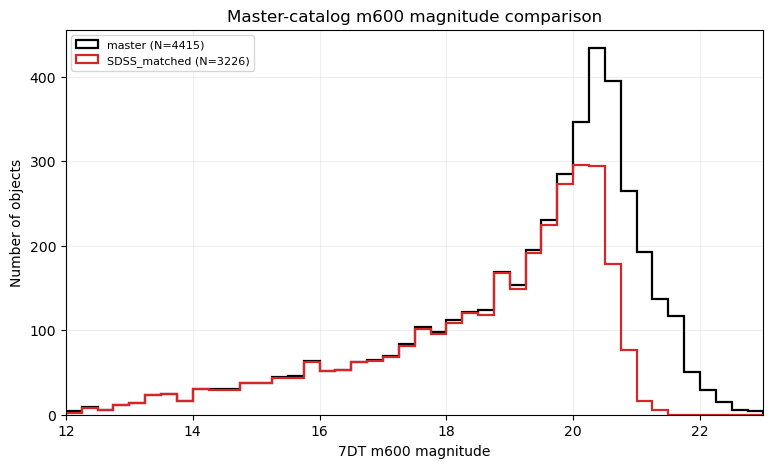

m600 [m600_mag_histogram_galaxy.png] counts:
master_excl_SDSS_star: N = 2033
 SDSS_matched_galaxy: N = 844


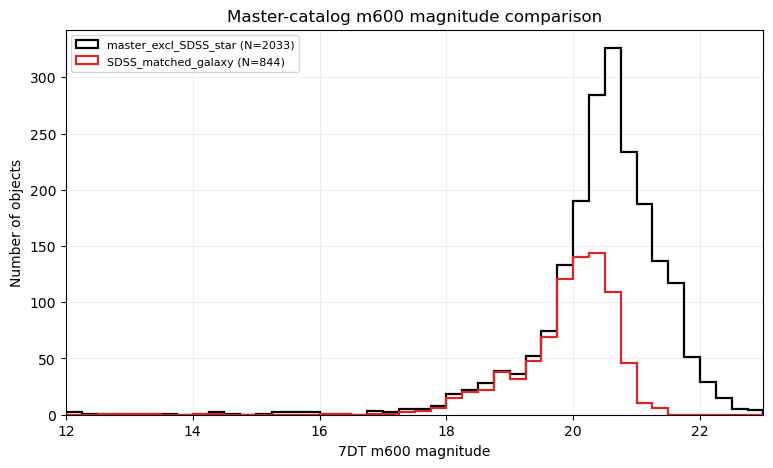

saved histograms for 20 bands x 2 versions to /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/figures/depth_by_band/01_mag_histograms


In [137]:
# Magnitude histograms for every 7DT band (display: m600 only; all bands saved as PNG).
# Two versions per band, both saved:
#  (1) master vs SDSS_matched (has_sdss)
#  (2) master_excl_SDSS_star vs SDSS_matched_galaxy
#      master_excl_SDSS_star = valid & ~(has_sdss & sdss_type==6)
_sdss_type = np.ma.filled(master['sdss_type'], -1).astype(int)
_sdss_matched = has_sdss_flag
_sdss_star = has_sdss_flag & (_sdss_type == 6)
_sdss_galaxy = has_sdss_flag & (_sdss_type == 3)
for band in ACTIVE_BANDS:
    mag = _finite_column(master, f'{band}_mag')
    valid = np.isfinite(mag)
    master_excl_star = valid & ~_sdss_star
    versions = {
        f'{band}_mag_histogram.png': {
            'master': valid,
            'SDSS_matched': _sdss_matched & valid,
        },
        f'{band}_mag_histogram_galaxy.png': {
            'master_excl_SDSS_star': master_excl_star,
            'SDSS_matched_galaxy': _sdss_galaxy & valid,
        },
    }
    values = mag[valid]
    hist_range = (np.floor(np.nanpercentile(values, 0.5)), np.ceil(np.nanpercentile(values, 99.5)))
    bin_edges = np.arange(hist_range[0], hist_range[1] + 0.25, 0.25)
    for fname, conditions in versions.items():
        fig, ax = plt.subplots(figsize=(9, 5))
        keys = list(conditions.keys())
        ax.hist(mag[conditions[keys[0]]], bins=bin_edges, histtype='step', color='black', linewidth=1.6,
                label=f"{keys[0]} (N={np.count_nonzero(conditions[keys[0]])})")
        ax.hist(mag[conditions[keys[1]]], bins=bin_edges, histtype='step', linewidth=1.6,
                color='C3', label=f"{keys[1]} (N={np.count_nonzero(conditions[keys[1]])})")
        ax.set_xlim(*hist_range)
        ax.set_xlabel(f'7DT {band} magnitude')
        ax.set_ylabel('Number of objects')
        ax.set_title(f'Master-catalog {band} magnitude comparison')
        ax.legend(fontsize=8); ax.grid(alpha=0.2)
        fig.savefig(HIST_DIR / fname, dpi=150, bbox_inches='tight')
        if band == 'm600':
            print(f'{band} [{fname}] counts:')
            for name, cond in conditions.items():
                print(f'{name:>20s}: N = {np.count_nonzero(cond)}')
            plt.show()
        else:
            plt.close(fig)
print(f'saved histograms for {N_ACTIVE_BANDS} bands x 2 versions to {HIST_DIR}')


## m600 magnitude-S/N depth diagnostics

Sample is `7DT_only` union `matched`; S/N is `1.0857 / mag_err`. All bands are saved; `m600` is shown with full and `0 <= S/N <= 10` rows.


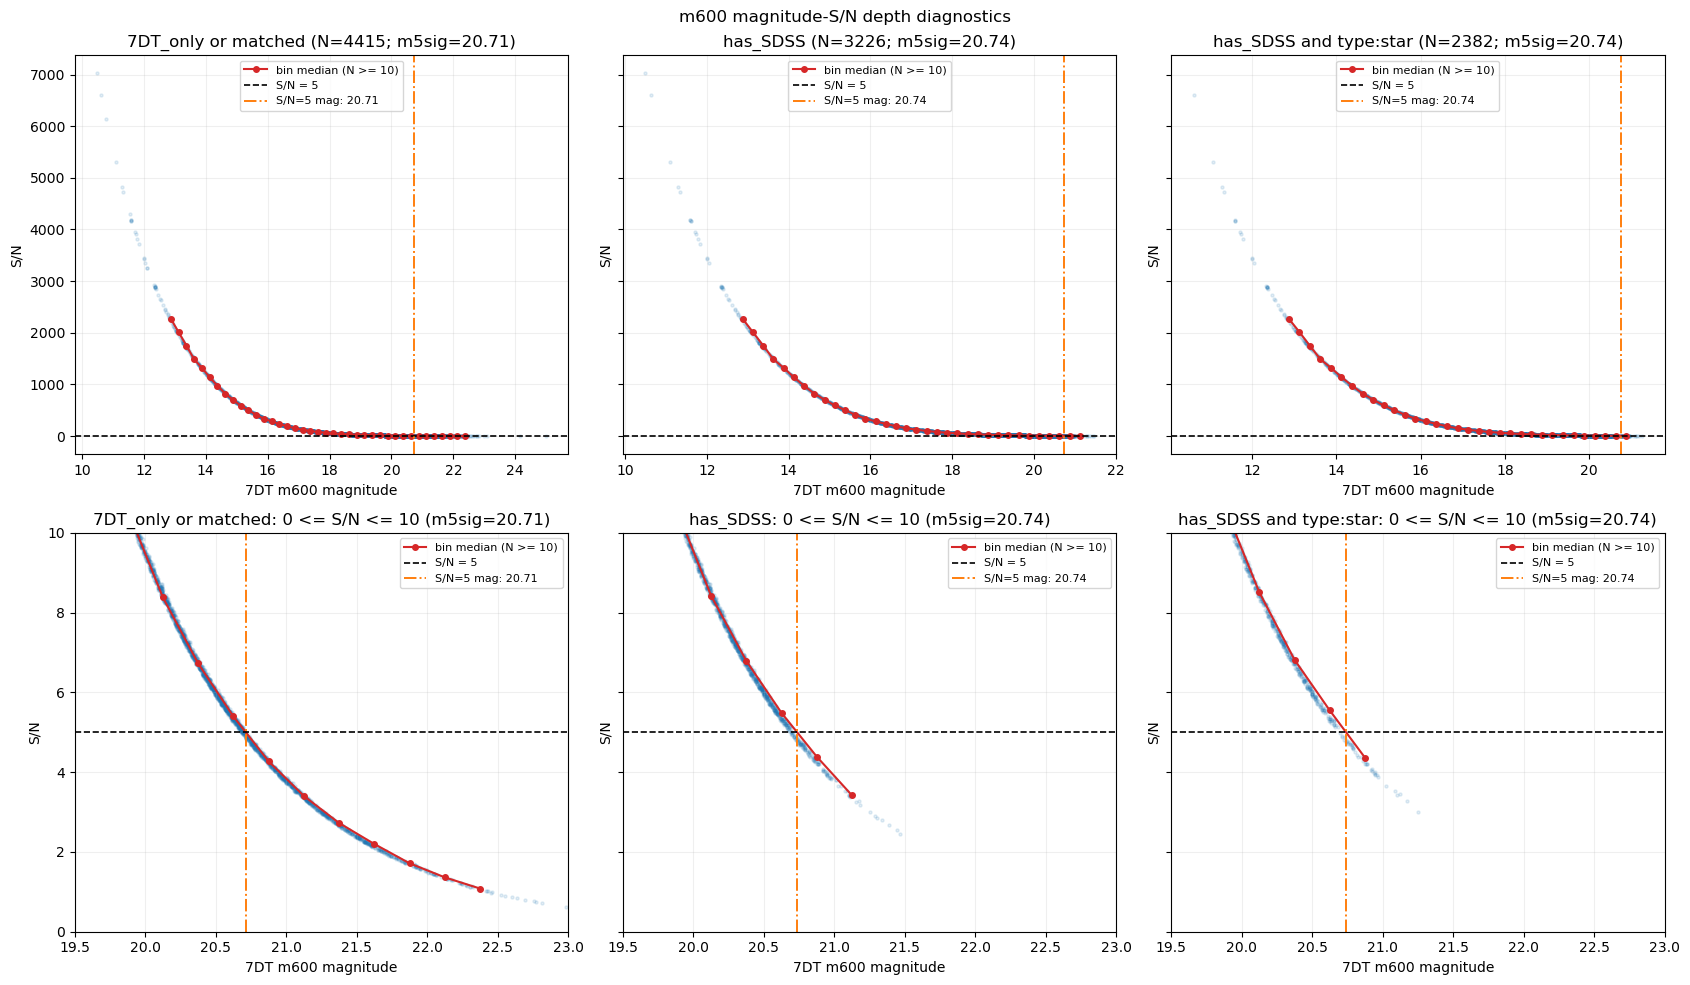

Magnitude-S/N population counts and S/N=5 limiting magnitudes:
     7DT_only or matched: N = 4415, m5sig = 20.71
                has_SDSS: N = 3226, m5sig = 20.74
  has_SDSS and type:star: N = 2382, m5sig = 20.74
band  m5sig(all)  m5sig(has_SDSS)  m5sig(star)
m400  21.26  21.27  21.28
m425  22.01  22.02  22.02
m450  21.28  21.29  21.28
m475  21.91  21.93  21.92
m500  21.55  21.56  21.58
m525  21.99  22.00  22.01
m550  20.89  20.90  20.92
m575  21.57  21.58  21.58
m600  20.71  20.74  20.74
m625  21.19  21.20  21.19
m650  20.22  20.25  20.25
m675  21.40  21.41  21.40
m700  20.61  20.62  20.60
m725  20.81  20.83  20.83
m750  20.18  20.20  20.19
m775  20.24  20.27  20.26
m800  19.90  19.92  19.91
m825  19.71  19.72  19.72
m850  19.48  19.50  19.51
m875  19.06  19.09  19.11
saved magnitude-S/N figures for 20 bands to /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/figures/depth_by_band/02_mag_snr


In [138]:
# Magnitude-S/N diagnostics for every 7DT band (display: m600 only; all bands saved as PNG).
def _sn5_limit(centers, medians, level=5.0):
    # Median S/N falls with magnitude; linearly interpolate the bright-to-faint
    # crossing of the S/N = level line. Returns nan when there is no crossing.
    c = np.asarray(centers, dtype=float)
    m = np.asarray(medians, dtype=float)
    ok = np.isfinite(c) & np.isfinite(m)
    c, m = c[ok], m[ok]
    if c.size < 2:
        return np.nan
    order = np.argsort(c)
    c, m = c[order], m[order]
    below = np.where(m < level)[0]
    if below.size == 0 or np.all(m < level):
        return np.nan
    i = int(below[0])
    if i == 0 or not (m[i - 1] >= level > m[i]):
        return np.nan
    c0, m0, c1, m1 = c[i - 1], m[i - 1], c[i], m[i]
    return float(c0 + (level - m0) * (c1 - c0) / (m1 - m0))

def _depth_figure(band, mag, snr, base, save_path=None, show=False):
    conds = {
        '7DT_only or matched': base,
        'has_SDSS': base & has_sdss_flag,
        'has_SDSS and type:star': base & sdss_star,
    }
    bins = np.arange(np.floor(np.nanmin(mag[base])), np.ceil(np.nanmax(mag[base])) + 0.25, 0.25)
    # Per-population bin medians and S/N=5 limiting magnitudes.
    locus, m5 = {}, {}
    for name, cond in conds.items():
        x, y = mag[cond], snr[cond]
        centers, medians = [], []
        for left, right in zip(bins[:-1], bins[1:]):
            sel = (x >= left) & (x < right)
            # Require at least 10 sources so sparse bins do not drive depth estimates.
            if np.count_nonzero(sel) >= 10:
                centers.append((left + right) / 2)
                medians.append(np.nanmedian(y[sel]))
        locus[name] = (x, y, centers, medians)
        m5[name] = _sn5_limit(centers, medians)
    fig, axes = plt.subplots(2, 3, figsize=(17, 10), sharey='row')
    crop = mag[base & (snr >= 0) & (snr <= 10)]
    crop_xlim = (np.floor(np.nanpercentile(crop, 0.5) * 2) / 2, np.ceil(np.nanpercentile(crop, 99.5) * 2) / 2)
    for col, (name, cond) in enumerate(conds.items()):
        x, y, centers, medians = locus[name]
        lim = m5[name]
        for row in range(2):
            ax = axes[row, col]
            ax.scatter(x, y, s=5, alpha=0.12, color='C0', rasterized=True)
            ax.plot(centers, medians, 'o-', color='C3', markersize=4, linewidth=1.5, label='bin median (N >= 10)')
            ax.axhline(5, color='black', linestyle='--', linewidth=1.2, label='S/N = 5')
            if np.isfinite(lim):
                ax.axvline(lim, color='C1', linestyle='-.', linewidth=1.4, label=f'S/N=5 mag: {lim:.2f}')
            ax.set_xlabel(f'7DT {band} magnitude')
            ax.grid(alpha=0.2)
            ax.legend(fontsize=8)
        tag = f'm5sig={lim:.2f}' if np.isfinite(lim) else 'm5sig=n/a'
        axes[0, col].set_title(f'{name} (N={np.count_nonzero(cond)}; {tag})')
        axes[0, col].set_ylabel('S/N')
        axes[1, col].set_ylim(0, 10)
        axes[1, col].set_xlim(*crop_xlim)
        axes[1, col].set_title(f'{name}: 0 <= S/N <= 10 ({tag})')
        axes[1, col].set_ylabel('S/N')
    fig.suptitle(f'{band} magnitude-S/N depth diagnostics')
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)
    return conds, m5

depth_rows = []
for band in ACTIVE_BANDS:
    mag = _finite_column(master, f'{band}_mag')
    err = _finite_column(master, f'{band}_mag_err')
    snr = 1.0857 / err
    valid = np.isfinite(mag)
    base = np.isin(master_class, ['7dt_only', 'matched']) & valid & np.isfinite(snr) & (err > 0)
    conds, m5 = _depth_figure(band, mag, snr, base, save_path=SNR_DIR / f'{band}_mag_snr.png', show=(band == 'm600'))
    depth_rows.append((band, *(m5[k] for k in ['7DT_only or matched', 'has_SDSS', 'has_SDSS and type:star'])))
    if band == 'm600':
        print('Magnitude-S/N population counts and S/N=5 limiting magnitudes:')
        for name, cond in conds.items():
            print(f'{name:>24s}: N = {np.count_nonzero(cond)}, m5sig = {m5[name]:.2f}')
print('band  m5sig(all)  m5sig(has_SDSS)  m5sig(star)')
for band, a, b, c in depth_rows:
    print(f'{band}  {a:.2f}  {b:.2f}  {c:.2f}')
print(f'saved magnitude-S/N figures for {N_ACTIVE_BANDS} bands to {SNR_DIR}')


## FWHM-magnitude diagnostics (per band)

FWHM proxy is `2 x flux_radius` (pix), the same definition as `band_uncertainty['fwhm_pix'] = 2 x r50_med`. 
Sample is `7dt_only` union `matched` with finite mag / positive mag_err / finite positive `flux_radius`, 
split into the same three populations as the S/N section. 
Horizontal dashed line marks the per-band PSF reference from `band_uncertainty.fits`. 
All bands are saved under `04_fwhm_mag`; `m600` is shown.


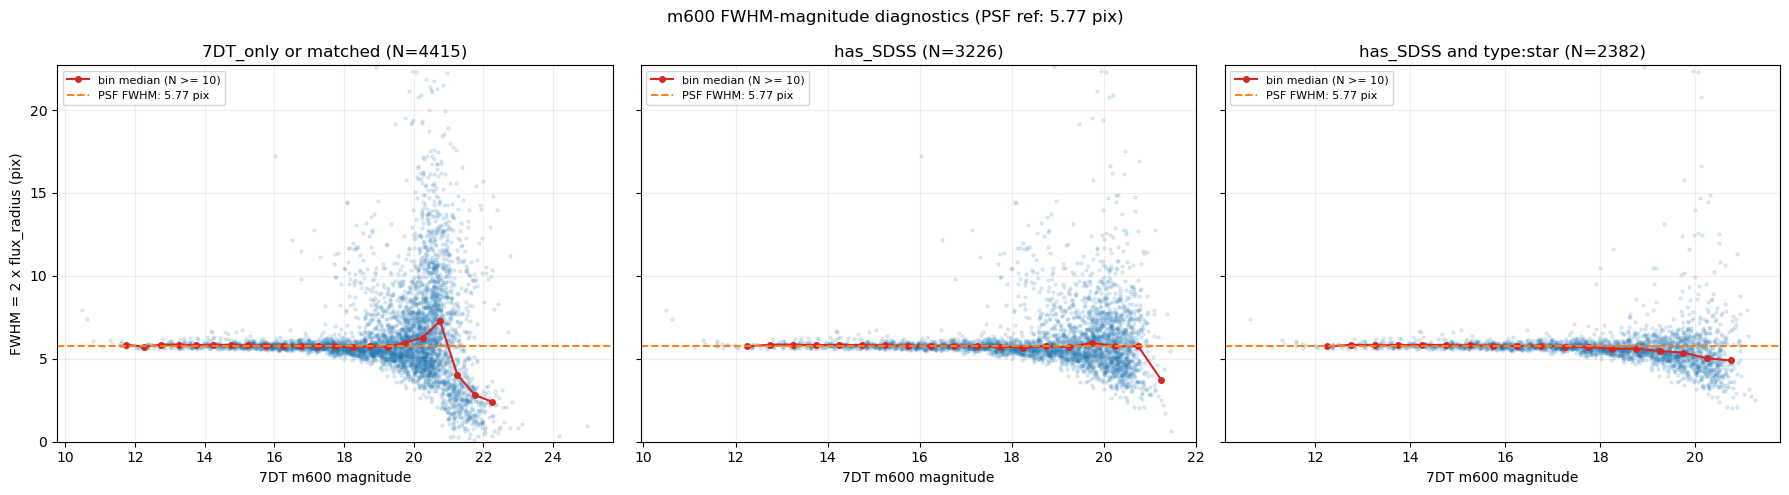

FWHM-mag population counts (m600):
     7DT_only or matched: N = 4415
                has_SDSS: N = 3226
  has_SDSS and type:star: N = 2382
band  psf_fwhm_pix  N_all  N_has_SDSS  N_star  med_fwhm_all_pix
m400  5.25   3310   1708   1516  5.31
m425  5.83   4459   2867   2180  5.89
m450  5.76   3788   2497   2093  5.82
m475  6.11   5355   3856   2725  6.17
m500  4.97   5168   3686   2695  5.06
m525  5.53   7067   5335   3260  5.61
m550  6.24   4142   2893   2276  6.28
m575  6.62   6602   4662   3004  6.69
m600  5.77   4415   3226   2382  5.81
m625  5.74   6357   4826   3030  5.80
m650  5.26   4020   2975   2384  5.30
m675  5.15   8219   6310   3612  5.28
m700  5.90   5164   3734   2703  5.99
m725  6.12   6034   4427   3015  6.22
m750  5.05   5212   3978   2992  5.10
m775  5.31   5579   4099   3009  5.37
m800  5.81   4919   3337   2641  5.90
m825  6.39   4435   3013   2469  6.44
m850  4.98   4329   3066   2526  5.04
m875  5.66   3602   2452   2152  5.72
saved FWHM-magnitude figures for 20 

In [139]:
# FWHM-magnitude diagnostics for every 7DT band (display: m600 only; all bands saved as PNG).
FWHM_DIR = DEPTH_FIG_DIR / '04_fwhm_mag'
FWHM_DIR.mkdir(parents=True, exist_ok=True)

# Per-band PSF reference: fwhm_pix = 2 x r50_med (same definition as 2 x flux_radius).
_unc_path = MATCH_DIR / 'band_uncertainty.fits'
_unc = Table.read(_unc_path)
_unc_bands = _unc['band']
PSF_FWHM_PIX = {}
for _b, _f in zip(_unc_bands, _unc['fwhm_pix']):
    _b = _b.decode().strip() if isinstance(_b, (bytes, np.bytes_)) else str(_b).strip()
    PSF_FWHM_PIX[_b] = float(_f)

def _fwhm_figure(band, mag, fwhm, base, psf_fwhm, save_path=None, show=False):
    conds = {
        '7DT_only or matched': base,
        'has_SDSS': base & has_sdss_flag,
        'has_SDSS and type:star': base & sdss_star,
    }
    bins = np.arange(np.floor(np.nanmin(mag[base])), np.ceil(np.nanmax(mag[base])) + 0.5, 0.5)
    locus = {}
    for name, cond in conds.items():
        x, y = mag[cond], fwhm[cond]
        centers, medians = [], []
        for left, right in zip(bins[:-1], bins[1:]):
            sel = (x >= left) & (x < right)
            if np.count_nonzero(sel) >= 10:
                centers.append((left + right) / 2)
                medians.append(np.nanmedian(y[sel]))
        locus[name] = (x, y, centers, medians)
    lo, hi = np.nanpercentile(fwhm[base], [0.5, 99.5])
    pad = 0.1 * (hi - lo) if np.isfinite(hi - lo) and hi > lo else 1.0
    ylim = (max(0.0, lo - pad), hi + pad)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ax, (name, cond) in zip(axes, conds.items()):
        x, y, centers, medians = locus[name]
        ax.scatter(x, y, s=5, alpha=0.12, color='C0', rasterized=True)
        ax.plot(centers, medians, 'o-', color='C3', markersize=4, linewidth=1.5, label='bin median (N >= 10)')
        if np.isfinite(psf_fwhm):
            ax.axhline(psf_fwhm, color='C1', linestyle='--', linewidth=1.4, label=f'PSF FWHM: {psf_fwhm:.2f} pix')
        ax.set_xlabel(f'7DT {band} magnitude')
        ax.set_title(f'{name} (N={np.count_nonzero(cond)})')
        ax.set_ylim(*ylim)
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)
    axes[0].set_ylabel('FWHM = 2 x flux_radius (pix)')
    fig.suptitle(f'{band} FWHM-magnitude diagnostics (PSF ref: {psf_fwhm:.2f} pix)')
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)
    return conds

fwhm_rows = []
for band in ACTIVE_BANDS:
    mag = _finite_column(master, f'{band}_mag')
    err = _finite_column(master, f'{band}_mag_err')
    fr = _finite_column(master, f'{band}_flux_radius')
    fwhm = 2.0 * fr
    valid = np.isfinite(mag) & np.isfinite(fwhm) & (fwhm > 0) & np.isfinite(err) & (err > 0)
    base = np.isin(master_class, ['7dt_only', 'matched']) & valid
    psf = PSF_FWHM_PIX.get(band, np.nan)
    conds = _fwhm_figure(band, mag, fwhm, base, psf, save_path=FWHM_DIR / f'{band}_fwhm_mag.png', show=(band == 'm600'))
    _med = float(np.nanmedian(fwhm[base])) if np.count_nonzero(base) else float('nan')
    fwhm_rows.append((band, psf, *(np.count_nonzero(conds[k]) for k in ['7DT_only or matched', 'has_SDSS', 'has_SDSS and type:star']), _med))
    if band == 'm600':
        print('FWHM-mag population counts (m600):')
        for name, cond in conds.items():
            print(f'{name:>24s}: N = {np.count_nonzero(cond)}')
print('band  psf_fwhm_pix  N_all  N_has_SDSS  N_star  med_fwhm_all_pix')
for band, psf, na, nb_, nc, med in fwhm_rows:
    print(f'{band}  {psf:.2f}  {na:5d}  {nb_:5d}  {nc:5d}  {med:.2f}')
print(f'saved FWHM-magnitude figures for {N_ACTIVE_BANDS} bands to {FWHM_DIR}')


## SDSS versus 7DT consistency (nearest band)

Each 7DT band is compared with its nearest SDSS band. All bands are saved; `m600` is shown.


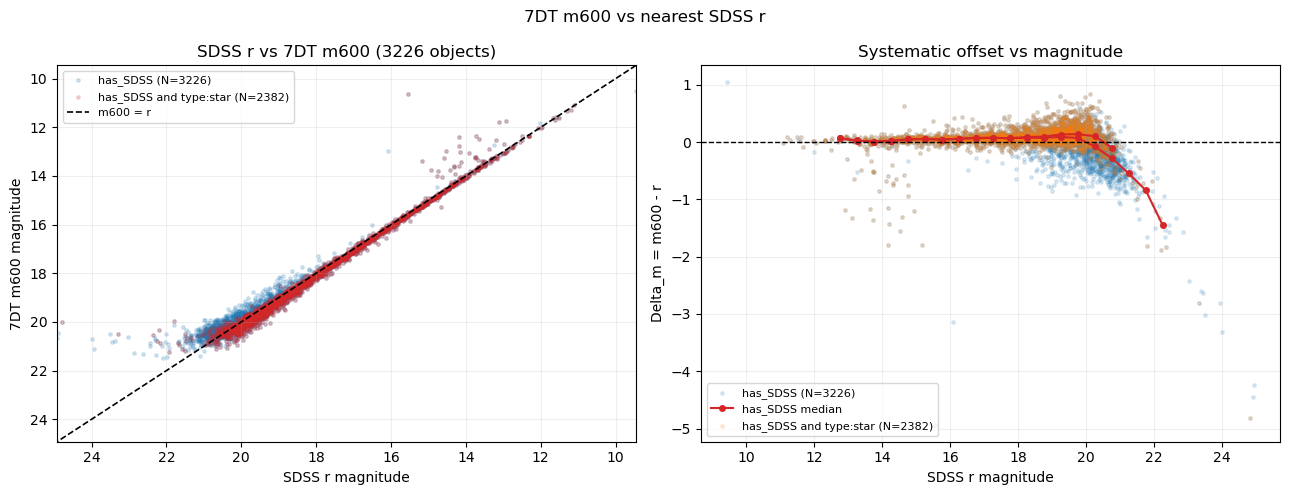

band  sdss  N_all  med_all  std_all  mad_all  N_star  med_star  std_star  mad_star
m400     u   1708  -0.7077  0.4903  0.2871   1516  -0.6958  0.3819  0.2713
m425     g   2867  +0.4303  0.4565  0.3714   2180  +0.5176  0.4074  0.3453
m450     g   2497  +0.0741  0.3449  0.1391   2093  +0.0898  0.2765  0.1098
m475     g   3856  -0.1473  0.3272  0.1697   2725  -0.1113  0.2621  0.1128
m500     g   3686  -0.1900  0.3404  0.1954   2695  -0.1439  0.2733  0.1120
m525     g   5335  -0.5079  0.3679  0.3722   3260  -0.3258  0.3125  0.2311
m550     r   2893  +0.2445  0.3713  0.2507   2276  +0.3067  0.3063  0.2249
m575     r   4662  +0.1012  0.3291  0.2177   3004  +0.1584  0.2569  0.1368
m600     r   3226  +0.0373  0.3608  0.1611   2382  +0.0691  0.2630  0.0965
m625     r   4826  -0.0718  0.3542  0.2140   3030  -0.0124  0.2624  0.0885
m650     r   2975  -0.1810  0.3348  0.2298   2384  -0.1186  0.2719  0.1588
m675     r   6310  -0.2648  0.3312  0.2615   3612  -0.1599  0.2557  0.1356
m700     i   3734

In [140]:
# SDSS consistency for every 7DT band vs nearest SDSS band (display: m600 only; all bands saved as PNG).
import math
rows = []
for band in ACTIVE_BANDS:
    sband = BAND_SDSS_MATCH[band]
    mag = _finite_column(master, f'{band}_mag')
    sdss_mag = _finite_column(master, f'sdss_psfMag_{sband}')
    valid = has_sdss_flag & np.isfinite(mag) & np.isfinite(sdss_mag)
    star_sel = valid & sdss_star
    delta = mag - sdss_mag
    def _stats(v):
        v = v[np.isfinite(v)]
        if len(v) == 0:
            return (0, math.nan, math.nan, math.nan)
        med = float(np.nanmedian(v))
        return (len(v), med, float(np.nanstd(v)), float(1.4826 * np.nanmedian(np.abs(v - med))))
    n_all, med_all, std_all, mad_all = _stats(delta[valid])
    n_star, med_star, std_star, mad_star = _stats(delta[star_sel])
    rows.append((band, sband, n_all, med_all, std_all, mad_all, n_star, med_star, std_star, mad_star))
    # Scatter + Delta plots.
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
    for cond, label, color in [(valid, 'has_SDSS', 'C0'), (star_sel, 'has_SDSS and type:star', 'C3')]:
        axes[0].scatter(sdss_mag[cond], mag[cond], s=6, alpha=0.18, color=color,
                        label=f'{label} (N={np.count_nonzero(cond)})', rasterized=True)
    lo = float(np.nanmin(np.concatenate([sdss_mag[valid], mag[valid]])))
    hi = float(np.nanmax(np.concatenate([sdss_mag[valid], mag[valid]])))
    axes[0].plot([lo, hi], [lo, hi], 'k--', linewidth=1.2, label=f'{band} = {sband}')
    axes[0].set(xlim=(lo, hi), ylim=(lo, hi), xlabel=f'SDSS {sband} magnitude', ylabel=f'7DT {band} magnitude')
    axes[0].invert_xaxis(); axes[0].invert_yaxis()
    axes[0].set_title(f'SDSS {sband} vs 7DT {band} ({n_all} objects)')
    axes[0].grid(alpha=0.2); axes[0].legend(fontsize=8)
    for cond, label in [(valid, 'has_SDSS'), (star_sel, 'has_SDSS and type:star')]:
        x, d = sdss_mag[cond], delta[cond]
        axes[1].scatter(x, d, s=6, alpha=0.15, label=f'{label} (N={np.count_nonzero(cond)})', rasterized=True)
        bins = np.arange(np.floor(np.nanmin(x)), np.ceil(np.nanmax(x)) + 0.5, 0.5)
        centers, medians = [], []
        for left, right in zip(bins[:-1], bins[1:]):
            sel = (x >= left) & (x < right)
            if np.count_nonzero(sel) >= 10:
                centers.append((left + right) / 2)
                medians.append(np.nanmedian(d[sel]))
        axes[1].plot(centers, medians, 'o-', color='C3', markersize=4, label=f'{label} median' if label == 'has_SDSS' else None)
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set(xlabel=f'SDSS {sband} magnitude', ylabel=f'Delta_m = {band} - {sband}')
    axes[1].set_title(f'Systematic offset vs magnitude')
    axes[1].grid(alpha=0.2); axes[1].legend(fontsize=8)
    fig.suptitle(f'7DT {band} vs nearest SDSS {sband}')
    fig.tight_layout()
    fig.savefig(CONSISTENCY_DIR / f'{band}_vs_sdss_{sband}_consistency.png', dpi=150, bbox_inches='tight')
    if band == 'm600':
        plt.show()
    else:
        plt.close(fig)
print('band  sdss  N_all  med_all  std_all  mad_all  N_star  med_star  std_star  mad_star')
for r in rows:
    print(f"{r[0]}  {r[1]:>4s}  {r[2]:5d}  {r[3]:+.4f}  {r[4]:.4f}  {r[5]:.4f}  {r[6]:5d}  {r[7]:+.4f}  {r[8]:.4f}  {r[9]:.4f}")
print(f'saved SDSS-consistency figures for {N_ACTIVE_BANDS} bands to {CONSISTENCY_DIR}')



Source information: master_id=2344
Image/catalog position
master_id master_class     master_ra          master_dec         master_x          master_y     n_7dt_bands has_finalcat has_sdss
--------- ------------ ------------------ ----------------- ----------------- ----------------- ----------- ------------ --------
     2344     7dt_only 149.35849798317412 2.113156858858884 8245.775657806558 4564.048384959495           2        False    False

Detection-image cutout


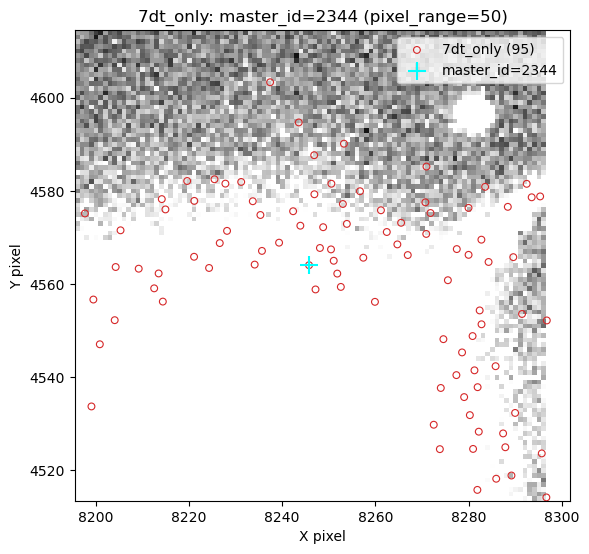


7DT 20-band cutouts


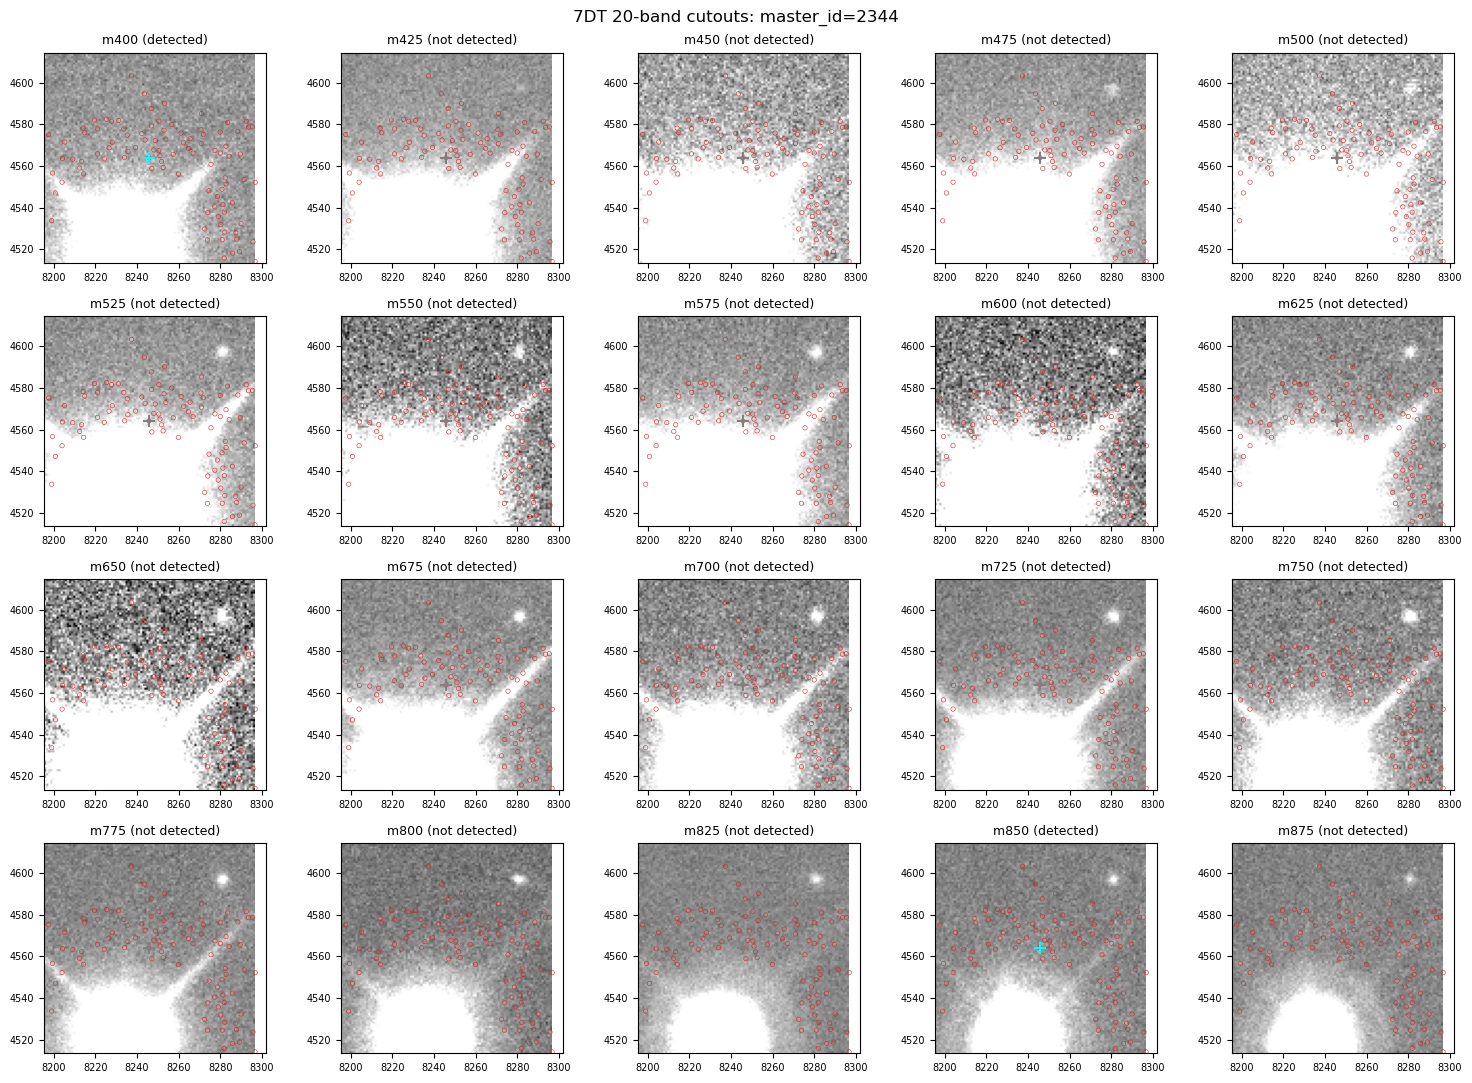

/var/folders/fd/sr9dc9td6rnc8xmntjxzpjh80000gn/T/ipykernel_2287/4240834457.py:220: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].set(xlabel='m475 - m750', ylabel='m600', title='Color-magnitude diagram'); axes[0, 0].invert_yaxis(); axes[0, 0].legend(fontsize=8)
/var/folders/fd/sr9dc9td6rnc8xmntjxzpjh80000gn/T/ipykernel_2287/4240834457.py:225: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 1].set(xlabel='m475 - m600', ylabel='m600 - m750', title='Color-color diagram'); axes[0, 1].legend(fontsize=8)



7DT photometry and morphology
band wavelength_nm detected source_id        mag               mag_err              snr            ellipticity      flux_radius_pix    derived_fwhm_pix  derived_fwhm_arcsec   band_fwhm_pix     band_fwhm_arcsec     extendicity   
---- ------------- -------- --------- ------------------ ------------------- ------------------ ------------------ ------------------ ------------------ ------------------- ------------------ ------------------ -----------------
m400           400     True      8748 20.814159393310547 0.14775985479354858 7.3477332629823575 0.6978009939193726 10.591254234313965  21.18250846862793  10.697166776658797  5.251121520996094  2.651816368103447 4.033901783444118
m425           425    False        -1                nan                 nan                nan                nan                nan                nan                 nan  5.827403545379639 2.9428387904171833               nan
m450           450    False        -1                

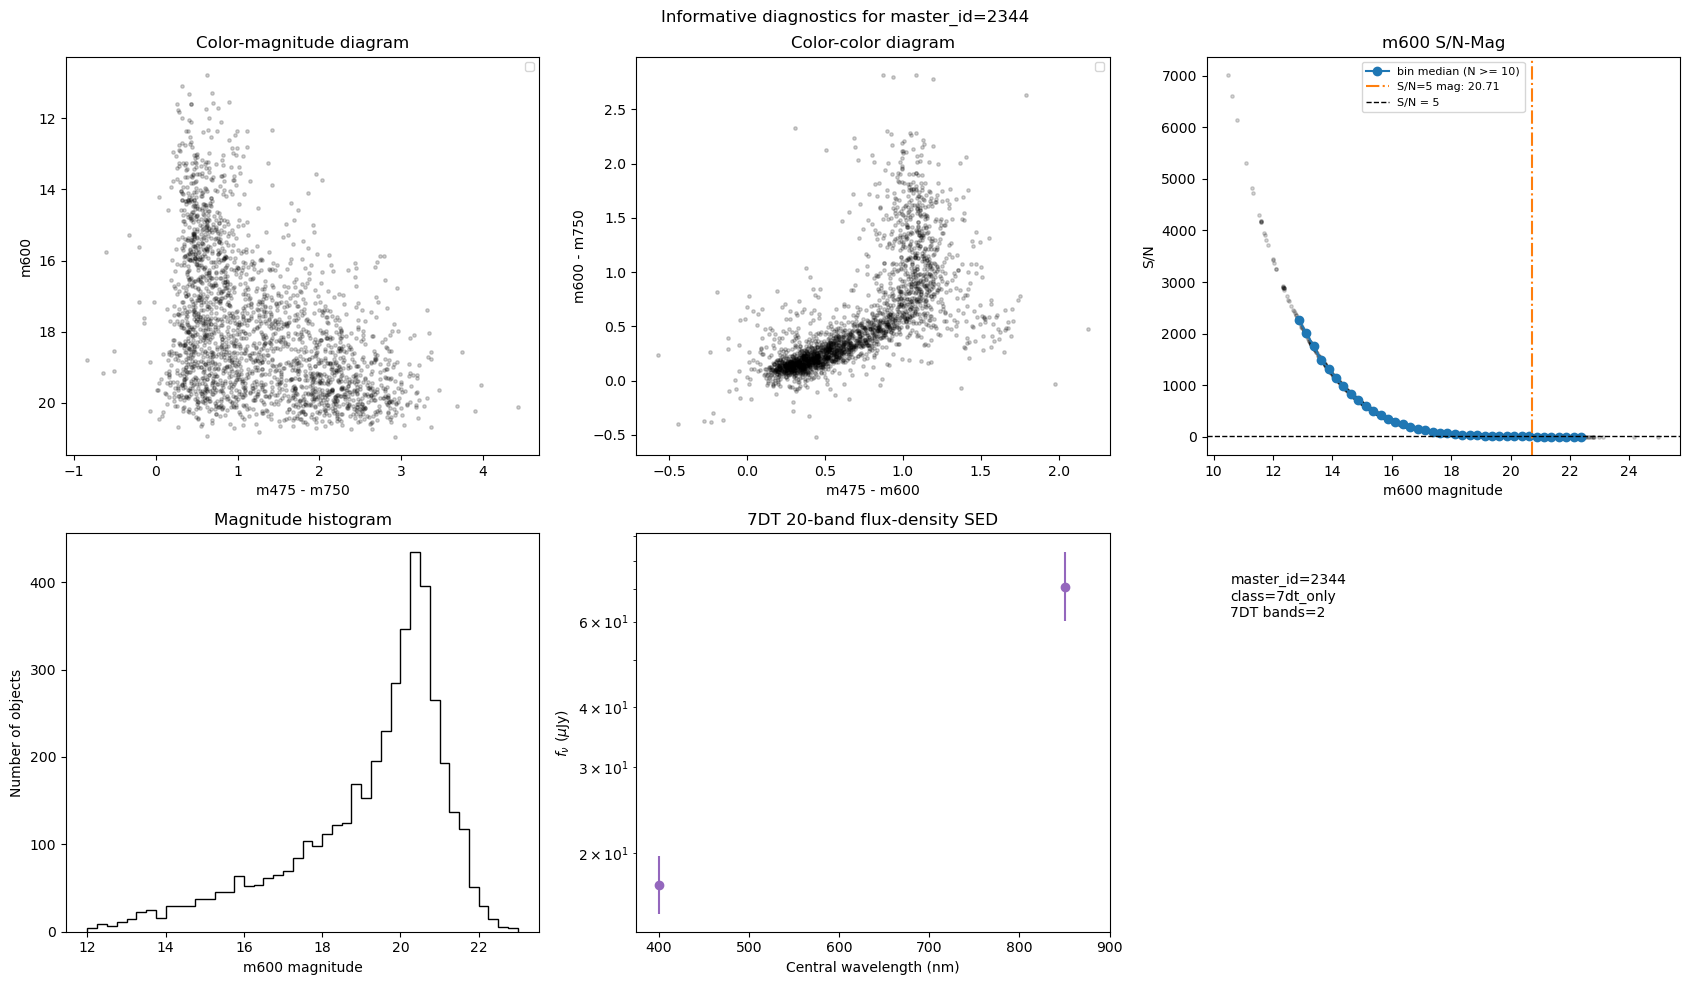

In [141]:
# print(f'Number of catalogs with 20 bands: {len(cat_has_20bands)}')
# cat_has_20bands_no_sdss = cat_has_20bands[cat_has_20bands['has_sdss'] == False]
# print(f'Number of catalogs not matched to SDSS in with20bands: {len(cat_has_20bands_no_sdss)}')
# print()
# source_info = plot_SourceInfoFromCatalog(
#     cat_has_20bands_no_sdss, 
#     pixel_range=50,
#     population_catalog=master,
#     source_id=721,
# )

cat_7dt_only_no_sdss = cat_7dt_only[cat_7dt_only['has_sdss'] == False]

source_info = plot_SourceInfoFromCatalog(
    cat_7dt_only_no_sdss, 
    pixel_range=50,
    population_catalog=master,
)

In [142]:
cat = cat_sdss_matched[cat_sdss_matched['sdss_type']==3]
print(len(cat))

4731


# SDSS Coverage and 7DT Recovery Analysis

## SDSS Galaxy Recovery as a Function of Magnitude

The canonical valid mask already removes 50 pixels from the irregular common-weight boundary. SDSS DR17 primary galaxies inside this mask form the reference population; recovered galaxies are those associated with a 7DT-bearing master source.

The cell below prints, together with the current figure/summary, a differential `coverage_by_mag` table (with `coverage_percent`) and a cumulative `coverage_percentage` table (`r <= limit`), both fully displayed (`max_lines=-1`) and saved as FITS.


SDSS full-list catalog: 25422 rows -> /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/sdss_coverage_with_7dt_match_cosmos1_dr17.fits
in coverage: 23792, galaxy reference: 14075, master-matched: 17172, 7DT-matched: 9443
SDSS coverage mask and galaxy recovery summary
          quantity                 value       
---------------------------- ------------------
        edge buffer (pixels)               50.0
        edge buffer (arcsec) 25.250000000003997
        coverage area (deg2) 1.0106037623749342
       SDSS primary galaxies            14075.0
 7DT-recovered SDSS galaxies             4729.0
   overall recovery fraction 0.3359857904085258
overall coverage percent [%]  33.59857904085258

Magnitude-binned recovery (differential, with coverage percent)
sdss_r_lo sdss_r_hi sdss_r_center n_sdss_galaxy n_7dt_recovered recovery_fraction coverage_percent binomial_error coverage_percent_error
--------- --------- ------------- ------------- --------------- ---

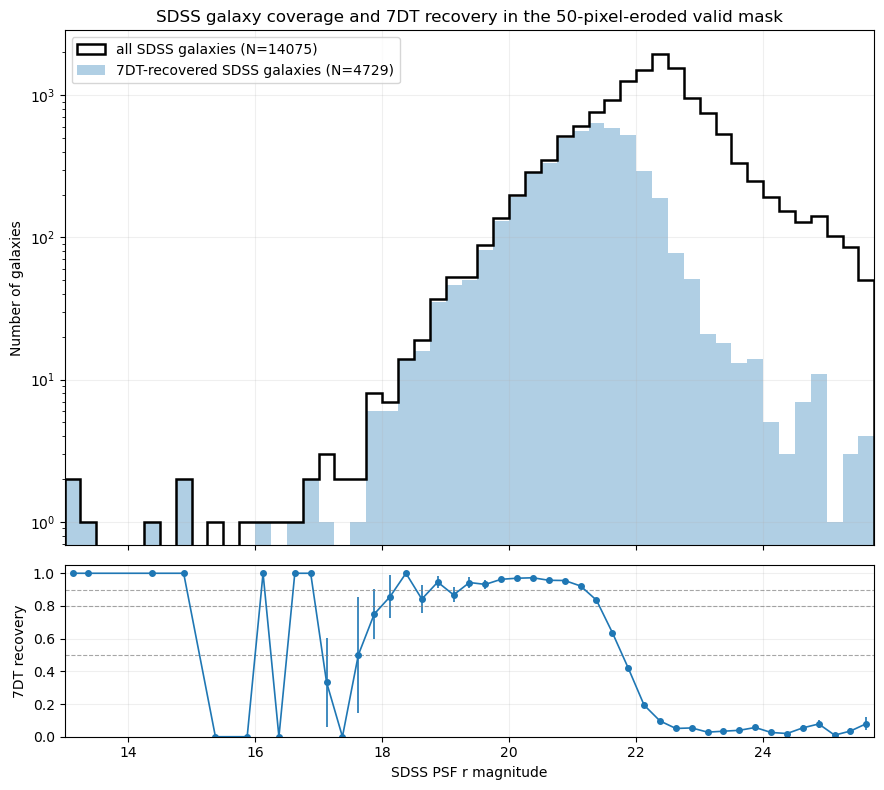


Saved SDSS coverage figure to /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/figures/sdss_coverage/sdss_galaxy_recovery_r.png


In [143]:
coverage_mask_path = DATA_ROOT / f'COSMOS{COSMOS}/COSMOS{COSMOS}_validmask.fits'
coverage_mask = fits.getdata(coverage_mask_path).astype(bool)
coverage_mask_header = fits.getheader(coverage_mask_path)
COVERAGE_EDGE_BUFFER_PIXELS = int(coverage_mask_header.get('EDGEBUF', 0))
coverage_wcs = WCS(fits.getheader(get_image_path(COSMOS, REFERENCE_BAND)))
coverage_pixel_scale_arcsec = float(proj_plane_pixel_scales(coverage_wcs)[0] * 3600.0)
coverage_area_deg2 = float(coverage_mask.sum() * (coverage_pixel_scale_arcsec / 3600.0) ** 2)

sdss_coverage_path = MATCH_DIR / f'sdss_primary_cosmos{COSMOS}_dr17.fits'
sdss_coverage_all = Table.read(sdss_coverage_path)
sdss_x, sdss_y = coverage_wcs.all_world2pix(
    np.asarray(sdss_coverage_all['ra'], dtype=float),
    np.asarray(sdss_coverage_all['dec'], dtype=float),
    1,
)
sdss_ix = np.rint(sdss_x - 1).astype(int)
sdss_iy = np.rint(sdss_y - 1).astype(int)
sdss_inside_image = (
    np.isfinite(sdss_x) & np.isfinite(sdss_y)
    & (sdss_ix >= 0) & (sdss_ix < coverage_mask.shape[1])
    & (sdss_iy >= 0) & (sdss_iy < coverage_mask.shape[0])
)
sdss_in_coverage = np.zeros(len(sdss_coverage_all), dtype=bool)
sdss_in_coverage[sdss_inside_image] = coverage_mask[
    sdss_iy[sdss_inside_image], sdss_ix[sdss_inside_image]
]
sdss_r = np.ma.filled(sdss_coverage_all['psfMag_r'], np.nan).astype(float)
sdss_type = np.asarray(sdss_coverage_all['type'], dtype=int)
sdss_mode = np.asarray(sdss_coverage_all['mode'], dtype=int)
sdss_galaxy_reference = (
    sdss_in_coverage & (sdss_mode == 1) & (sdss_type == 3)
    & np.isfinite(sdss_r) & (sdss_r > -50) & (sdss_r < 50)
)

coverage_master = Table.read(MASTER_CATALOG_PATH)
master_has_sdss = np.asarray(coverage_master['has_sdss'], dtype=bool)
master_has_7dt = np.asarray(coverage_master['has_7dt'], dtype=bool)
master_sdss_galaxy = np.ma.filled(coverage_master['sdss_type'], -1).astype(int) == 3
recovered_sdss_ids = set(map(int, np.asarray(coverage_master['sdss_objid'])[
    master_has_sdss & master_has_7dt & master_sdss_galaxy
]))
sdss_galaxy_recovered = sdss_galaxy_reference & np.asarray([
    int(objid) in recovered_sdss_ids for objid in sdss_coverage_all['objid']
])

sdss_objids = np.asarray(sdss_coverage_all['objid']).astype(int)
master_sdss_objids = np.ma.filled(coverage_master['sdss_objid'], 0).astype(int)
master_ids = np.asarray(coverage_master['master_id']).astype(int)
master_match_status = np.asarray(coverage_master['sdss_match_status']).astype(str)
master_match_sep = np.ma.filled(coverage_master['sdss_sep_arcsec'], np.nan).astype(float)
sdss_to_master = {
    int(objid): (int(mid), bool(has7), str(status), float(sep))
    for objid, mid, has7, status, sep in zip(
        master_sdss_objids[master_has_sdss], master_ids[master_has_sdss],
        master_has_7dt[master_has_sdss], master_match_status[master_has_sdss],
        master_match_sep[master_has_sdss],
    )
}
matched_7dt_ids = set(map(int, master_sdss_objids[master_has_sdss & master_has_7dt]))
matched_any_ids = set(map(int, master_sdss_objids[master_has_sdss]))
sdss_has_master = np.asarray([objid in matched_any_ids for objid in sdss_objids])
sdss_has_7dt = np.asarray([objid in matched_7dt_ids for objid in sdss_objids])
sdss_catalog_path = MATCH_DIR / f'sdss_coverage_with_7dt_match_cosmos{COSMOS}_dr17.fits'
sdss_coverage_catalog = sdss_coverage_all.copy()
sdss_coverage_catalog['in_coverage_mask'] = sdss_in_coverage
sdss_coverage_catalog['is_galaxy_reference'] = sdss_galaxy_reference
sdss_coverage_catalog['has_master_match'] = sdss_has_master
sdss_coverage_catalog['has_7dt_match'] = sdss_has_7dt
sdss_coverage_catalog['master_id'] = np.asarray([sdss_to_master.get(objid, (-1, False, '', np.nan))[0] for objid in sdss_objids])
sdss_coverage_catalog['master_has_7dt'] = np.asarray([sdss_to_master.get(objid, (-1, False, '', np.nan))[1] for objid in sdss_objids])
sdss_coverage_catalog['master_match_status'] = np.asarray([sdss_to_master.get(objid, (-1, False, '', np.nan))[2] for objid in sdss_objids])
sdss_coverage_catalog['master_sep_arcsec'] = np.asarray([sdss_to_master.get(objid, (-1, False, '', np.nan))[3] for objid in sdss_objids], dtype=float)
sdss_coverage_catalog.write(sdss_catalog_path, overwrite=True)
print(f'SDSS full-list catalog: {len(sdss_coverage_catalog)} rows -> {sdss_catalog_path}')
print(f'in coverage: {int(sdss_in_coverage.sum())}, galaxy reference: {int(sdss_galaxy_reference.sum())}, '
      f'master-matched: {int(sdss_has_master.sum())}, 7DT-matched: {int(sdss_has_7dt.sum())}')

reference_mag = sdss_r[sdss_galaxy_reference]
recovered_mag = sdss_r[sdss_galaxy_recovered]
hist_min = 13.0
hist_max = np.ceil(np.nanpercentile(reference_mag, 99.5) * 4) / 4
mag_bins = np.arange(hist_min, hist_max + 0.25, 0.25)
reference_count, _ = np.histogram(reference_mag, bins=mag_bins)
recovered_count, _ = np.histogram(recovered_mag, bins=mag_bins)
bin_centers = (mag_bins[:-1] + mag_bins[1:]) / 2
recovery_fraction = np.divide(
    recovered_count, reference_count,
    out=np.full(len(reference_count), np.nan), where=reference_count > 0,
)
recovery_error = np.sqrt(
    np.divide(
        recovery_fraction * (1 - recovery_fraction), reference_count,
        out=np.full(len(reference_count), np.nan), where=reference_count > 0,
    )
)

overall_fraction = float(sdss_galaxy_recovered.sum() / sdss_galaxy_reference.sum())
coverage_summary = Table(rows=[
    ('edge buffer (pixels)', COVERAGE_EDGE_BUFFER_PIXELS),
    ('edge buffer (arcsec)', COVERAGE_EDGE_BUFFER_PIXELS * coverage_pixel_scale_arcsec),
    ('coverage area (deg2)', coverage_area_deg2),
    ('SDSS primary galaxies', int(sdss_galaxy_reference.sum())),
    ('7DT-recovered SDSS galaxies', int(sdss_galaxy_recovered.sum())),
    ('overall recovery fraction', overall_fraction),
    ('overall coverage percent [%]', overall_fraction * 100.0),
], names=['quantity', 'value'])
recovery_percent = recovery_fraction * 100.0
recovery_percent_error = recovery_error * 100.0
coverage_by_mag = Table(
    [mag_bins[:-1], mag_bins[1:], bin_centers, reference_count, recovered_count,
     recovery_fraction, recovery_percent, recovery_error, recovery_percent_error],
    names=['sdss_r_lo', 'sdss_r_hi', 'sdss_r_center', 'n_sdss_galaxy', 'n_7dt_recovered',
           'recovery_fraction', 'coverage_percent', 'binomial_error', 'coverage_percent_error'],
)
for name in ['sdss_r_lo', 'sdss_r_hi', 'sdss_r_center', 'recovery_fraction', 'binomial_error']:
    coverage_by_mag[name].format = '.4f'
for name in ['coverage_percent', 'coverage_percent_error']:
    coverage_by_mag[name].format = '.2f'
# Cumulative coverage percentage table (r <= limit) shown together with binned results.
mag_limits = sorted(set([19.0, 20.0, 21.0, 21.5, 22.0, 22.5, 23.0, 24.0, float(np.nanmax(reference_mag))]))
cum_rows = []
for lim in mag_limits:
    sel_ref = reference_mag <= lim
    sel_rec = recovered_mag <= lim
    n_ref = int(np.count_nonzero(sel_ref))
    n_rec = int(np.count_nonzero(sel_rec))
    frac = (n_rec / n_ref) if n_ref > 0 else np.nan
    err = float(np.sqrt(frac * (1 - frac) / n_ref)) if n_ref > 0 and np.isfinite(frac) else np.nan
    cum_rows.append((lim, n_ref, n_rec, frac, frac * 100.0 if np.isfinite(frac) else np.nan,
                     err, err * 100.0 if np.isfinite(err) else np.nan))
coverage_percentage = Table(
    rows=cum_rows,
    names=['r_limit', 'n_sdss_cum', 'n_7dt_cum', 'recovery_fraction', 'coverage_percent',
           'binomial_error', 'coverage_percent_error'],
)
coverage_percentage['r_limit'].format = '.2f'
for name in ['recovery_fraction', 'binomial_error']:
    coverage_percentage[name].format = '.4f'
for name in ['coverage_percent', 'coverage_percent_error']:
    coverage_percentage[name].format = '.2f'
coverage_by_mag_path = MATCH_DIR / 'sdss_galaxy_recovery_by_mag.fits'
coverage_percentage_path = MATCH_DIR / 'sdss_galaxy_coverage_percentage.fits'
coverage_by_mag.write(coverage_by_mag_path, overwrite=True)
coverage_percentage.write(coverage_percentage_path, overwrite=True)
print('SDSS coverage mask and galaxy recovery summary')
coverage_summary.pprint(max_lines=-1, max_width=-1)
print('\nMagnitude-binned recovery (differential, with coverage percent)')
coverage_by_mag.pprint(max_lines=-1, max_width=-1)
print('\nCoverage percentage (cumulative r <= limit)')
coverage_percentage.pprint(max_lines=-1, max_width=-1)
print(f'saved: {coverage_by_mag_path}')
print(f'saved: {coverage_percentage_path}')

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
axes[0].hist(reference_mag, bins=mag_bins, histtype='step', color='black', linewidth=1.8, label=f'all SDSS galaxies (N={len(reference_mag)})')
axes[0].hist(recovered_mag, bins=mag_bins, histtype='stepfilled', color='tab:blue', alpha=0.35, linewidth=1.4, label=f'7DT-recovered SDSS galaxies (N={len(recovered_mag)})')
axes[0].set_yscale('log')
axes[0].set_ylabel('Number of galaxies')
axes[0].set_title(f'SDSS galaxy coverage and 7DT recovery in the {COVERAGE_EDGE_BUFFER_PIXELS}-pixel-eroded valid mask')
axes[0].grid(alpha=0.2)
axes[0].legend()
valid_bin = reference_count > 0
axes[1].errorbar(bin_centers[valid_bin], recovery_fraction[valid_bin], yerr=recovery_error[valid_bin], fmt='o-', color='tab:blue', markersize=4, linewidth=1.2)
for level in (0.5, 0.8, 0.9): axes[1].axhline(level, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
axes[1].set(xlabel='SDSS PSF r magnitude', ylabel='7DT recovery', ylim=(0, 1.05), xlim=(hist_min, hist_max))
axes[1].grid(alpha=0.2)
fig.tight_layout()
coverage_figure_dir = MATCH_DIR / 'figures' / 'sdss_coverage'
coverage_figure_dir.mkdir(parents=True, exist_ok=True)
coverage_figure_path = coverage_figure_dir / 'sdss_galaxy_recovery_r.png'
fig.savefig(coverage_figure_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'\nSaved SDSS coverage figure to {coverage_figure_path}')


## SDSS-only (7DT-missed) visual inspection per magnitude bin

This cell visually inspects every source in the selected magnitude range that is present in SDSS but undetected by 7DT. Do not execute it yet.

- Targets: SDSS galaxies in `sdss_coverage_catalog` with `is_galaxy_reference == True` and `has_7dt_match == False` (already defined in the coverage cell)
- Display: pass `cat=master` to `plot_ImgofTargetRegion` to overlay 7DT detections, centering on the SDSS `(ra, dec)` with `target_centre_type='radec'`
- `img_range` is the side length of the square region in arcsec, and `searching_table=True` also shows the nearby master-source table
- The code below plots every missed source in `INSPECTION_BINS`. Change `INSPECTION_BINS` or `IMG_RANGE_ARCSEC` to inspect other ranges or region sizes.


### Visual inspection of 7DT-missed soures by mag bins

SDSS-only (7DT-missed) galaxies: 9346

r = [13.0, 19.0): N_missed = 16
Number of sources to plot: 16



[1/16] SDSS objid=1237651735743889472, r=17.801, ra dec = 150.110259 1.585350


Catalog sources (finite position): 88361/88361
Query: x=2889.53, y=801.15
Returning 10 nearest sources
master_id         x                  y                 ra                dec         master_class   pixel_distance  
--------- ------------------ ----------------- ------------------ ------------------ ------------ ------------------
      132 2889.9786378692806 805.6196705074839 150.11019657125993 1.5859776193040345     7dt_only  4.495178719129658
    21453 2894.1484374999995 787.6673583984375 150.10961098258008 1.5834595355389083     7dt_only 14.248744164162352
    25059  2906.597412109375 801.0667114257812  150.1078644312058  1.585339323358128     7dt_only 17.067411159391597
    31821  2907.111083984375  797.265380859375  150.1077922528971 1.5848061211889943     7dt_only 18.004282141698244
     3384 2900.5034208406896 785.4358112723291  150.1087191658783 1.5831466493507358     7dt_only  19.16378472863406
    19781 2874.4323137392294 788.8484623964355 150.11237766580723 1.5836247941

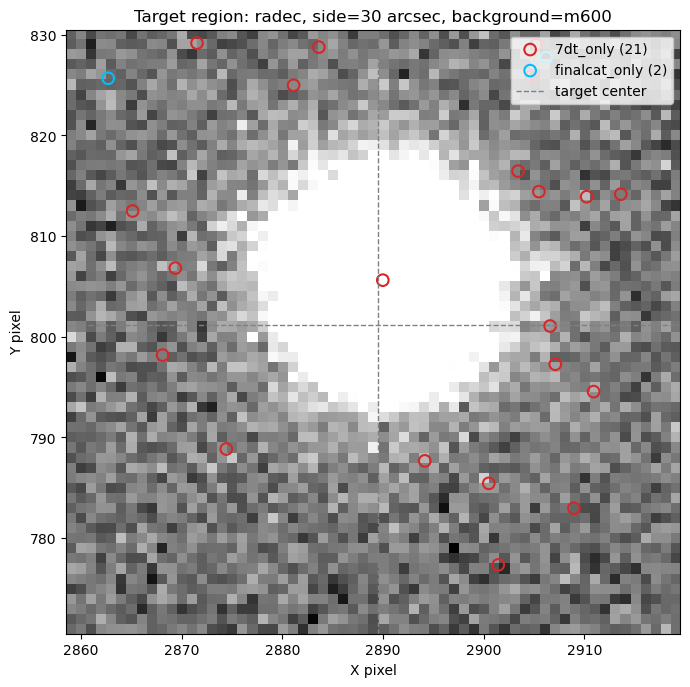

[2/16] SDSS objid=1237651736280694859, r=15.343, ra dec = 150.015043 1.845470
Catalog sources (finite position): 88361/88361
Query: x=3568.30, y=2655.43
Returning 10 nearest sources
master_id         x                  y                  ra                dec         master_class   pixel_distance  
--------- ------------------ ------------------ ------------------ ------------------ ------------ ------------------
     1307 3571.0184313267523  2656.890379760387 150.01466228395637 1.8456752654394906     7dt_only 3.0855860906759087
     1292  3541.741943359375 2654.3234863281255  150.0187711439795 1.8453146908559863     7dt_only 26.583712292116523
     1281 3570.9873046875005 2628.8007812500005 150.01466614992825 1.8417349596738706     7dt_only 26.759587325231017
    34538  3543.461181640625   2669.29833984375  150.0185301245989 1.8474153375139304     7dt_only 28.452866567883873
    34531  3579.612548828125   2625.43701171875 150.01345555369414  1.841263247803767     7dt_only  32.0501504

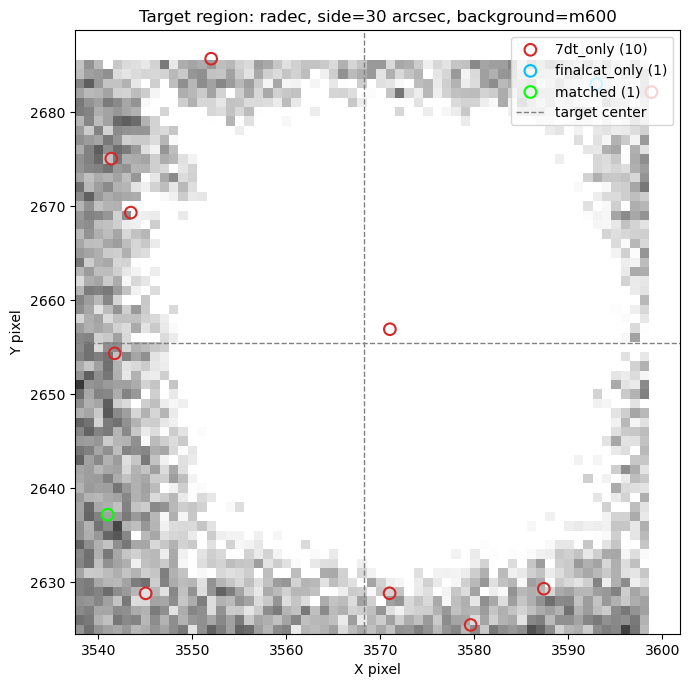

[3/16] SDSS objid=1237651736280760353, r=18.708, ra dec = 150.040205 2.003469
Catalog sources (finite position): 88361/88361
Query: x=3389.19, y=3781.79
Returning 10 nearest sources
master_id         x                  y                  ra                dec          master_class    pixel_distance  
--------- ------------------ ------------------ ------------------ ------------------ ------------- -------------------
    84415 3389.2761909618157  3782.218382455114         150.040192           2.003529 finalcat_only 0.43520238963872704
     1913 3380.4488948423304 3778.9853086757785   150.041430943451  2.003075294064449      7dt_only   9.176858830774725
    28520    3400.1044921875 3780.3032226562495  150.0386720899016  2.003260570119294      7dt_only  11.019817132448582
    11323  3400.093993040542  3789.117917340661 150.03867373894767   2.00449706386524      7dt_only  13.139557761730272
    21990  3402.172119140625  3785.410400390625 150.03838197705556  2.003977029042694      7dt_onl

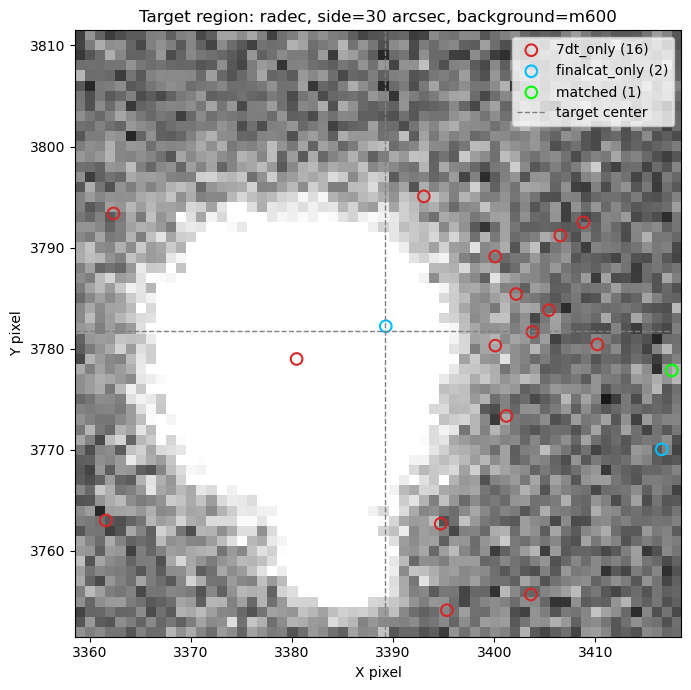

[4/16] SDSS objid=1237651753460039758, r=17.402, ra dec = 149.312358 1.814937
Catalog sources (finite position): 88361/88361
Query: x=8575.11, y=2438.14
Returning 10 nearest sources
master_id         x                 y                  ra                dec         master_class   pixel_distance  
--------- ----------------- ------------------ ------------------ ------------------ ------------ ------------------
     1203 8567.329726162157  2437.609244576884  149.3134497898277 1.8148626795404048     7dt_only 7.7977192797650865
     1177 8595.515625000002  2431.557373046875  149.3094944960864  1.814012704699533     7dt_only 21.443428884082845
     1201   8569.5146484375     2465.705078125 149.31314202285427 1.8188036546098854     7dt_only  28.12250082537942
     1158 8581.826171875002 2404.3432617187505 149.31141674762642 1.8101958499084199     7dt_only  34.46234074733013
     6723   8608.2099609375   2428.43603515625    149.30771313405 1.8135743855659525     7dt_only 34.495329034631496

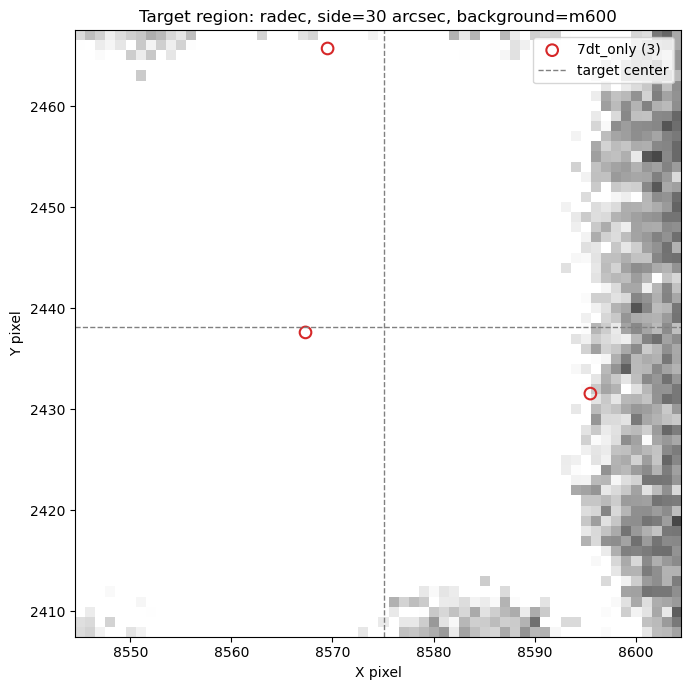

[5/16] SDSS objid=1237651753460236374, r=18.512, ra dec = 149.851454 1.773202
Catalog sources (finite position): 88361/88361
Query: x=4733.88, y=2140.16
Returning 10 nearest sources
master_id         x                  y                  ra                dec          master_class   pixel_distance  
--------- ------------------ ------------------ ------------------ ------------------ ------------- ------------------
    53018  4733.509619810507   2140.24447112443         149.851505           1.773214 finalcat_only 0.3765886714506802
    16958   4731.38720703125 2138.6169433593755  149.8518028613004 1.7729856879860042      7dt_only 2.9273095297886065
    53019  4726.234490390771  2135.168981282649         149.852526           1.772502 finalcat_only  9.125980012717429
    34446      4734.73828125  2149.302490234375  149.8513326032445 1.7744846310579474      7dt_only  9.185168624653766
    30764           4742.625 2144.1689453125005 149.85022572563972 1.7737645462079041      7dt_only  9.6

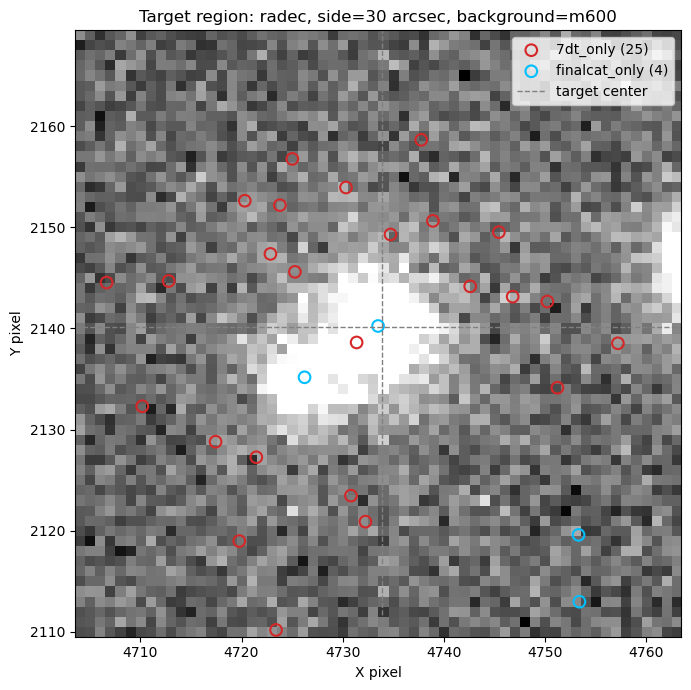

[6/16] SDSS objid=1237651753460367420, r=17.047, ra dec = 150.072474 1.636852
Catalog sources (finite position): 88361/88361
Query: x=3158.86, y=1168.27
Returning 10 nearest sources
master_id         x                  y                  ra                dec         master_class   pixel_distance  
--------- ------------------ ------------------ ------------------ ------------------ ------------ ------------------
      387  3161.405496502822 1168.9423492513674  150.0721168157543  1.636946714714461     7dt_only 2.6335730907720722
    21527    3171.0498046875  1155.763427734375 150.07076313447243 1.6350982641331546     7dt_only  17.46420629304877
    15210 3156.1267089843755  1150.809326171875 150.07285717450267 1.6344030593326362     7dt_only  17.67238125452086
      368 3169.5539550781255 1153.9688720703125  150.0709730060196 1.6348465099729548     7dt_only 17.856958089305635
    19957  3140.645263671875 1167.8385009765625 150.07503006885335 1.6367914785376234     7dt_only 18.21924647

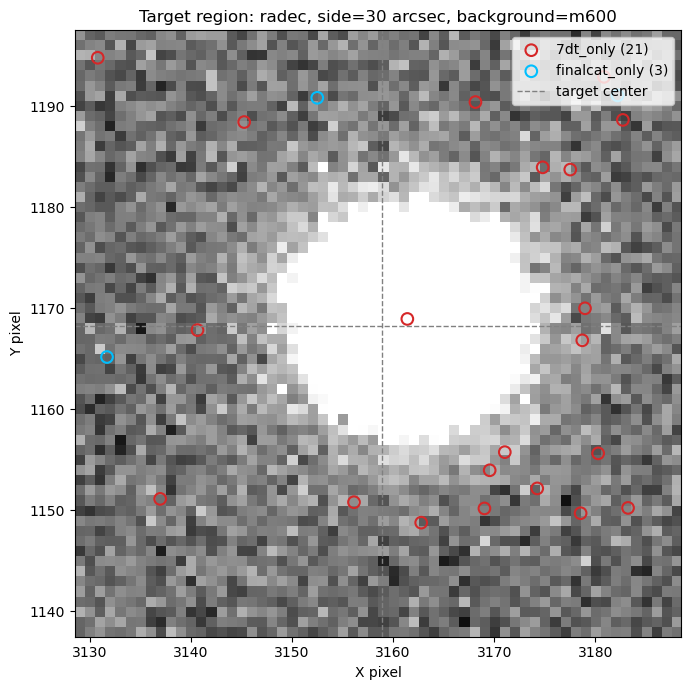

[7/16] SDSS objid=1237651753460498449, r=17.485, ra dec = 150.339168 1.695111
Catalog sources (finite position): 88361/88361
Query: x=1258.46, y=1583.99
Returning 10 nearest sources
master_id         x                  y                  ra                dec         master_class   pixel_distance  
--------- ------------------ ------------------ ------------------ ------------------ ------------ ------------------
      662  1257.293190285044 1584.0802002608923 150.33933129898776  1.695123288234035     7dt_only  1.169712498175101
    21611 1270.5382080078125 1575.2462158203123 150.33747229062732  1.693884672120496     7dt_only 14.912505493355146
    29256 1258.2745361328123 1600.4605712890623 150.33919432733717 1.6974209817984045     7dt_only  16.46956935411465
    25282 1273.9510498046873   1576.93408203125  150.3369934578792 1.6941215597988428     7dt_only 17.023529469100897
      648    1272.8408203125 1573.5582275390627 150.33714910014896 1.6936479895491279     7dt_only 17.76751710

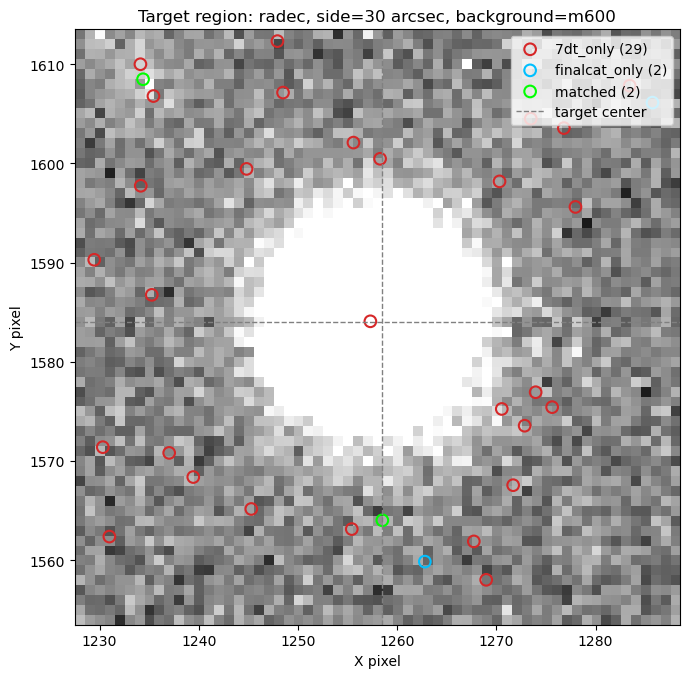

[8/16] SDSS objid=1237651753460498450, r=17.057, ra dec = 150.339676 1.695160
Catalog sources (finite position): 88361/88361
Query: x=1254.84, y=1584.34
Returning 10 nearest sources
master_id         x                  y                  ra                dec         master_class   pixel_distance  
--------- ------------------ ------------------ ------------------ ------------------ ------------ ------------------
      662  1257.293190285044 1584.0802002608923 150.33933129898776  1.695123288234035     7dt_only  2.467484136723791
    29256 1258.2745361328123 1600.4605712890623 150.33919432733717 1.6974209817984045     7dt_only 16.478018597058746
     3824    1255.5869140625 1602.0931396484375  150.3395715428367 1.6976498751338875     7dt_only 17.764372182891265
     3822 1244.8153076171875 1599.4422607421875  150.3410829547967 1.6972776174174486     7dt_only  18.12278697712996
    21611 1270.5382080078125 1575.2462158203123 150.33747229062732  1.693884672120496     7dt_only 18.14429123

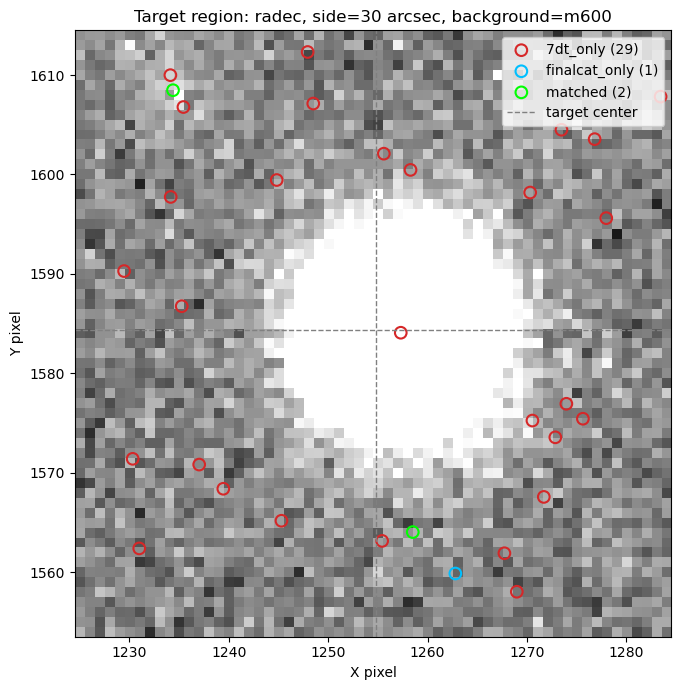

[9/16] SDSS objid=1237651753996910652, r=18.225, ra dec = 149.360430 2.105154
Catalog sources (finite position): 88361/88361
Query: x=8232.02, y=4507.00
Returning 10 nearest sources
master_id         x                 y                 ra                dec         master_class   pixel_distance  
--------- ----------------- ----------------- ------------------ ------------------ ------------ ------------------
    20991 8234.465417212603 4519.933982955507 149.36008715573792 2.1069692692460555     7dt_only 13.166951369015898
    28649   8231.2451171875   4477.4833984375 149.36054072472996   2.10101474120916     7dt_only 29.522119106255076
    28650 8219.017856738188 4477.615513363291 149.36225698019493   2.10103375467209     7dt_only  32.13013152586658
    28646   8242.4150390625 4475.618164062499 149.35897294538324 2.1007526584751037     7dt_only   33.0526684519751
    34814    8249.427734375  4478.22509765625 149.35798852424122 2.1011180620396694     7dt_only  33.62418180335758
    34

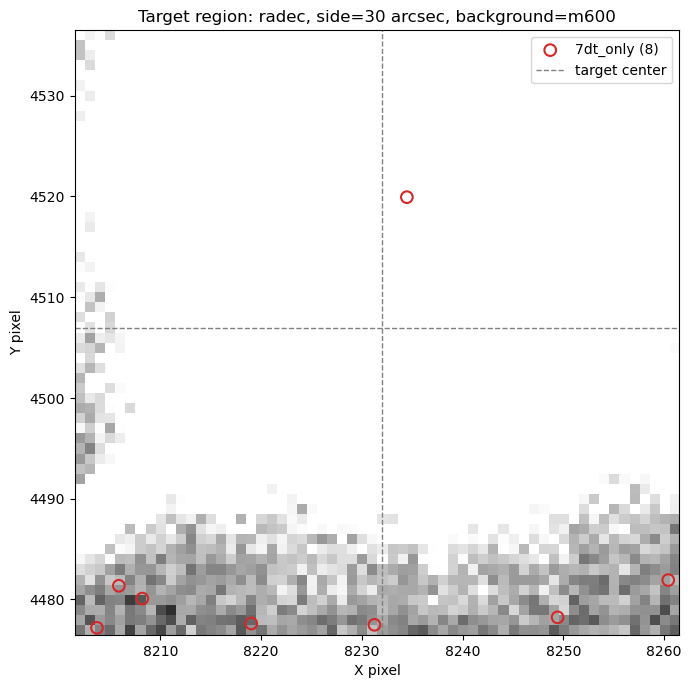

[10/16] SDSS objid=1237651753996976177, r=15.841, ra dec = 149.520975 2.207913
Catalog sources (finite position): 88361/88361
Query: x=7088.14, y=5239.28
Returning 10 nearest sources
master_id         x                  y                 ra                dec         master_class   pixel_distance  
--------- ------------------ ----------------- ------------------ ------------------ ------------ ------------------
     2717  7089.333175990428 5239.721648348395  149.5208086517141 2.2079739942007484     7dt_only 1.2662072677269665
    33918   7074.16552734375  5231.67138671875 149.52293803082947  2.206845155290145     7dt_only  15.91793041419261
    19529     7072.037109375  5238.33837890625  149.5232366583712  2.207780411930139     7dt_only 16.135457475135574
    30086  7103.718261718749 5250.784667968749  149.5187890539436  2.209525459476983     7dt_only 19.359368467669476
    33921  7092.722167968751 5258.220703125001 149.52033248304684  2.210568827122836     7dt_only  19.4815240366400

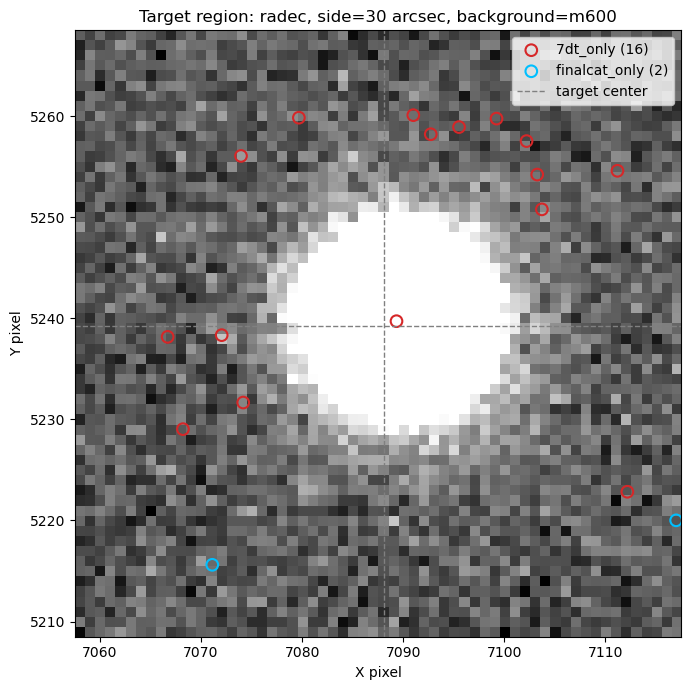

[11/16] SDSS objid=1237651753997238311, r=16.421, ra dec = 150.043232 2.156013
Catalog sources (finite position): 88361/88361
Query: x=3367.77, y=4869.25
Returning 10 nearest sources
master_id         x                  y                 ra                dec          master_class   pixel_distance  
--------- ------------------ ----------------- ------------------ ------------------ ------------- ------------------
    87229 3367.9956142680467 4869.195152862322         150.043201           2.156005 finalcat_only 0.2308630053067528
     2528 3352.3806152343755    4882.552734375  150.0453932083497 2.1578783788696185      7dt_only 20.343042663368262
     2507   3370.41108489124 4846.276486197375  150.0428614673784  2.152790144236494      7dt_only 23.124592204261234
    34872    3389.3173828125  4860.22314453125 150.04020780378616  2.154746928509441      7dt_only 23.360534005927953
     2508    3378.2158203125   4846.4775390625  150.0417658936658  2.152818520809943      7dt_only  25.053310

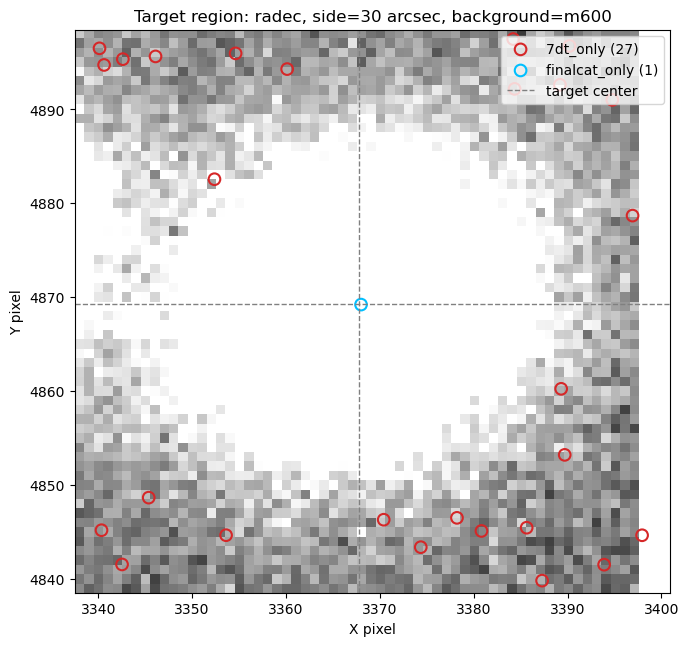

[12/16] SDSS objid=1237653664184926258, r=17.921, ra dec = 149.593780 1.584713
Catalog sources (finite position): 88361/88361
Query: x=6570.06, y=796.51
Returning 10 nearest sources
master_id         x                 y                 ra                dec          master_class   pixel_distance  
--------- ----------------- ----------------- ------------------ ------------------ ------------- ------------------
    75771 6570.035681324691 796.8966843777857         149.593783           1.584767 finalcat_only 0.3882929136105583
    33063 6575.690429687501 810.8992919921876  149.5929892458023 1.5867310833654664      7dt_only 15.452167256961564
    34171  6556.83349609375  787.332275390625  149.5956357833332 1.5834255727221846      7dt_only 16.098854264387445
    29060 6584.777343749999 786.1514282226561  149.5917145366801  1.583259543941848      7dt_only  17.99624299733658
    27882 6552.377929687499 803.4213256835938 149.59626074513528 1.5856824643658438      7dt_only   18.9856712895343

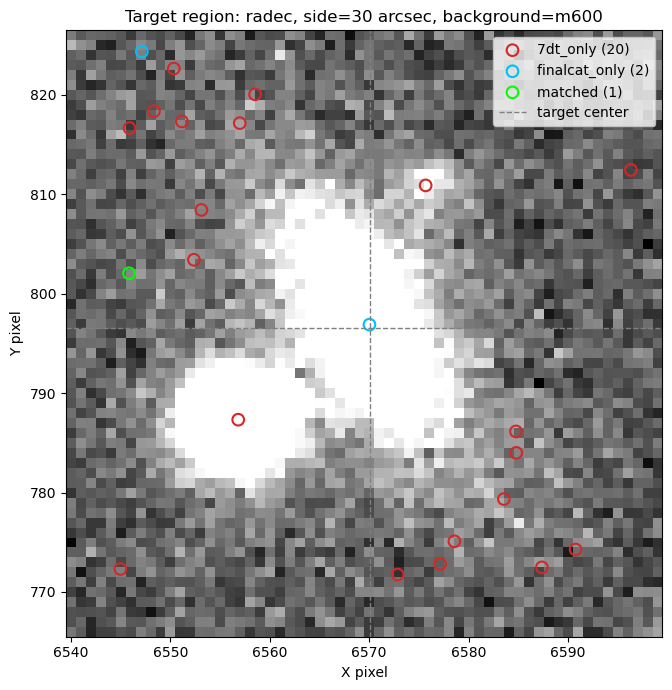

[13/16] SDSS objid=1237653664721797213, r=18.880, ra dec = 149.618066 2.017796
Catalog sources (finite position): 88361/88361
Query: x=6396.65, y=3883.87
Returning 10 nearest sources
master_id         x                 y                  ra                dec          master_class   pixel_distance  
--------- ----------------- ------------------ ------------------ ------------------ ------------- ------------------
     1969 6402.010837353447  3883.323576010233 149.61731442953433 2.0177191388119105      7dt_only 5.3859562338699645
    48539 6388.827311315915  3877.532562279438         149.619165           2.016907 finalcat_only 10.070476155423341
    48540 6391.414547056823  3867.417142302638         149.618802           2.015488 finalcat_only 17.267612867342187
    11342  6408.24072265625    3866.0107421875  149.6164402473459 2.0152904503512032      7dt_only 21.290170333302402
    13827      6398.0390625 3862.2402343750005 149.61787224099717 2.0147616958454067      7dt_only 21.6752014

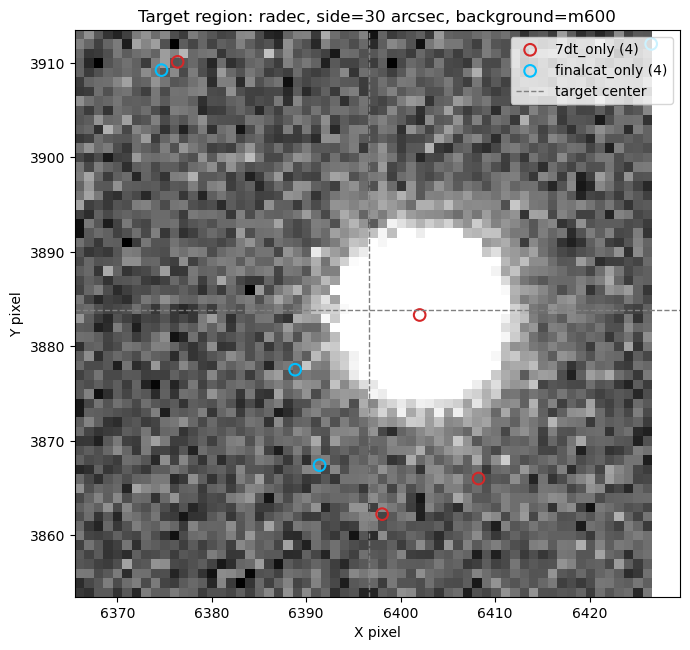

[14/16] SDSS objid=1237653664722124994, r=17.547, ra dec = 150.401973 1.864880
Catalog sources (finite position): 88361/88361
Query: x=811.32, y=2794.44
Returning 10 nearest sources
master_id         x                 y                  ra                dec          master_class    pixel_distance  
--------- ----------------- ------------------ ------------------ ------------------ ------------- -------------------
    87145 811.1768827911292  2794.600786811533        150.4019928           1.864903 finalcat_only 0.21676964224679848
    84007 810.6268059817849 2794.6836727204736          150.40207          1.8649146 finalcat_only  0.7360409033826435
     1370 812.6820963446847 2795.0706077628356 150.40178158718845 1.8649689738364725      7dt_only   1.500670278918059
    51351  816.361405020958 2810.1191110735717         150.401266            1.86708 finalcat_only  16.470552095001533
    29500 815.0231933593749 2777.7409667968745 150.40145217709565  1.862538261971546      7dt_only  17.1

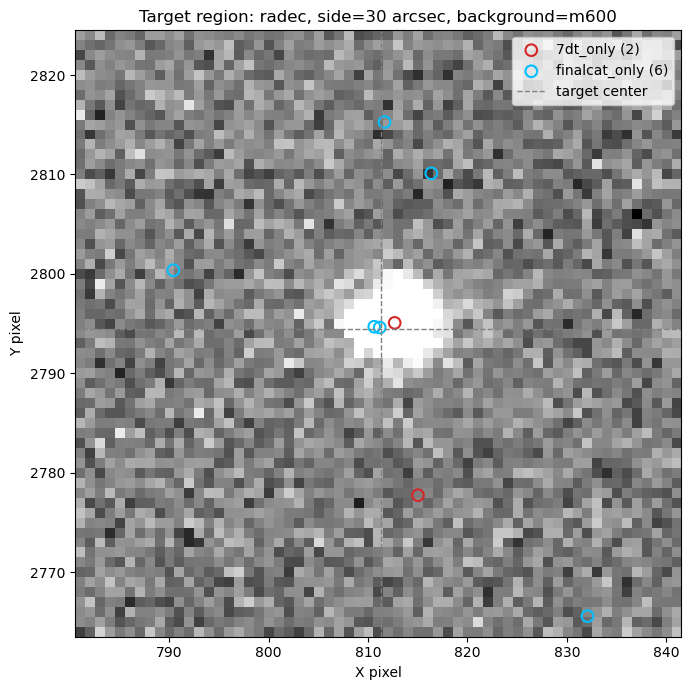

[15/16] SDSS objid=1237653665258995868, r=18.927, ra dec = 150.252759 2.278166
Catalog sources (finite position): 88361/88361
Query: x=1875.35, y=5740.43
Returning 10 nearest sources
master_id         x                  y                  ra                dec          master_class    pixel_distance  
--------- ------------------ ------------------ ------------------ ------------------ ------------- -------------------
    73299 1874.9503497126475  5740.134018823732         150.252814           2.278124 finalcat_only 0.49457007115082346
    27681  1873.547119140625     5739.041015625 150.25301094095298  2.277970623910654      7dt_only   2.273207190710276
     7590 1878.8373803043728 5746.2151470682475 150.25226857695432 2.2789771637135563      7dt_only   6.755853650940323
    21278   1872.38134765625    5749.3759765625  150.2531749796802  2.279420244806913      7dt_only    9.42233407347819
    73300 1867.3692357405498  5734.347517381921         150.253878           2.277312 finalcat_on

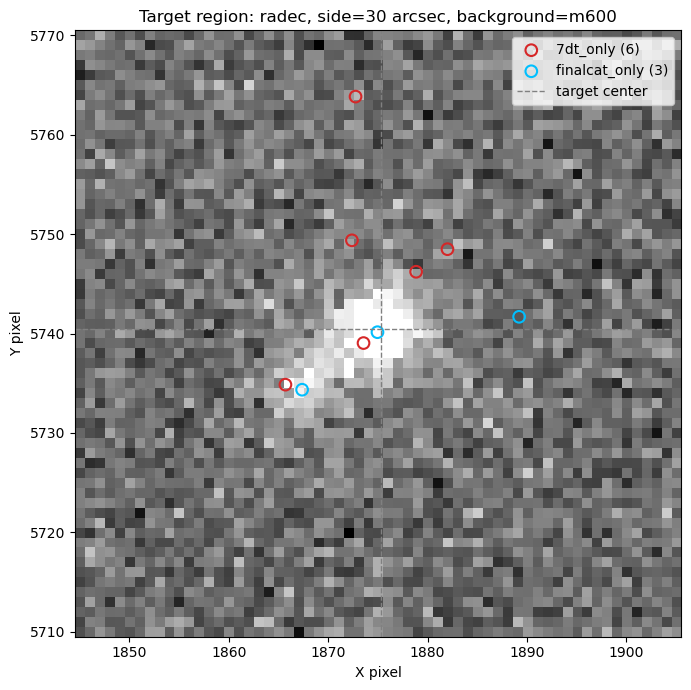

[16/16] SDSS objid=1237653665258995921, r=18.656, ra dec = 150.319734 2.286696
Catalog sources (finite position): 88361/88361
Query: x=1398.25, y=5801.41
Returning 10 nearest sources
master_id         x                  y                 ra                dec          master_class   pixel_distance  
--------- ------------------ ----------------- ------------------ ------------------ ------------- ------------------
    83990 1398.3504239710574 5801.538593448531          150.31972          2.2867145 finalcat_only  0.161672970775136
     7605  1397.767229972151 5803.192873602001  150.3198019378998  2.286946511565196      7dt_only 1.8489108168879338
    84546 1397.0621016075847 5805.021699868197         150.319901           2.287203 finalcat_only 3.8040370768076963
    11936 1388.3489990234375   5795.2998046875  150.3211236847303  2.285838894495816      7dt_only 11.637236334789925
    28925 1391.6529541015625  5791.72705078125 150.32065973536226 2.2853379224471864      7dt_only 11.7179754

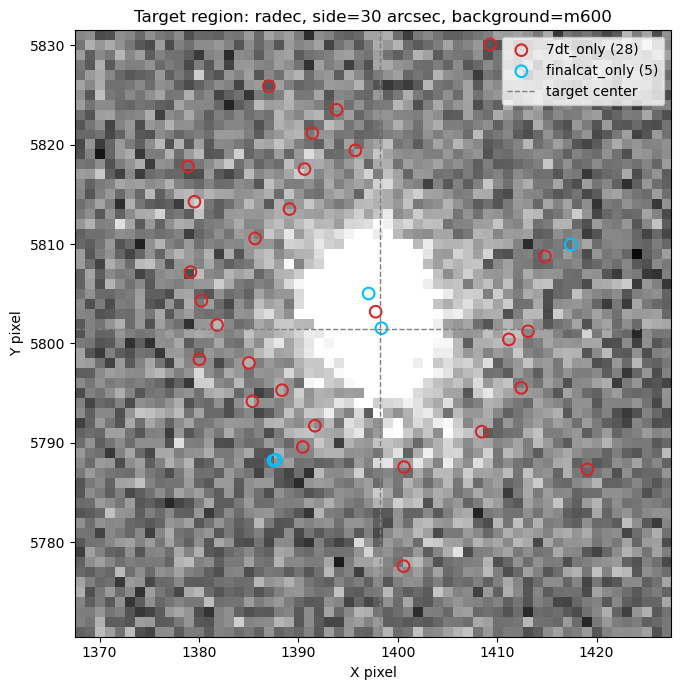

In [ ]:
# 7DT-missed SDSS galaxies (SDSS-only) for visual inspection cells

IMG_RANGE_ARCSEC = 30.0  # 이미지 한 변의 길이 (arcsec)
BACKGROUND_IMAGE = 'm600' #'detectionimage'  # or an active band such as 'm600'

missed_mask = np.asarray(sdss_coverage_catalog['is_galaxy_reference'], dtype=bool) & ~np.asarray(sdss_coverage_catalog['has_7dt_match'], dtype=bool)
missed = sdss_coverage_catalog[missed_mask]
missed_r = np.ma.filled(missed['psfMag_r'], np.nan).astype(float)
print(f'SDSS-only (7DT-missed) galaxies: {len(missed)}')


INSPECTION_BINS = (13, 19)

lo, hi = INSPECTION_BINS
in_bin = np.isfinite(missed_r) & (missed_r >= lo) & (missed_r < hi)
missed = missed[in_bin]
missed_r = missed_r[in_bin]
print(f'\nr = [{lo:.1f}, {hi:.1f}): N_missed = {len(missed)}')

print(f'Number of sources to plot: {len(missed)}')
print('\n\n')

for i, row in enumerate(missed):
    #if i <= 10 : continue
    ra, dec = float(row['ra']), float(row['dec'])
    print(f'[{i+1}/{len(missed)}] SDSS objid={int(row["objid"])}, r={float(row["psfMag_r"]):.3f}, ra dec = {float(row["ra"]):.6f} {float(row["dec"]):.6f}')
    
    fig, ax, nearby = plot_ImgofTargetRegion(
        master,
        target_centre=(ra, dec),
        target_centre_type='radec',
        img_range=IMG_RANGE_ARCSEC,
        searching_table=True,
        background_image=BACKGROUND_IMAGE,
    )


### Additional visual inspection cell

In [ ]:
# plot_SourceInfoFromCatalog(
#     master,
#     pixel_range=40,
#     source_id=7303,
# )

# FINALCAT Coverage and 7DT Recovery Analysis


## FINALCAT Spatial Distribution and 7DT whole observated region plot

COSMOS1: NAXIS=10200x6800, used=10192x6800 (trimmed 8 cols), pooled=(425, 637), masked-zero frac=0.256, RA=[149.08520,150.51593], Dec=[1.47302,2.42667]
COSMOS2: NAXIS=10200x6800, used=10192x6800 (trimmed 8 cols), pooled=(425, 637), masked-zero frac=0.240, RA=[149.08487,150.51625], Dec=[2.02298,2.97663]
COSMOS3: NAXIS=10200x6800, used=10192x6800 (trimmed 8 cols), pooled=(425, 637), masked-zero frac=0.259, RA=[149.68520,151.11593], Dec=[1.47302,2.42667]
COSMOS4: NAXIS=10200x6800, used=10192x6800 (trimmed 8 cols), pooled=(425, 637), masked-zero frac=0.257, RA=[149.68487,151.11625], Dec=[2.02298,2.97663]
Global used footprint: RA=[149.08487,151.11625] (span 2.03138 deg), Dec=[1.47302,2.97663] (span 1.50361 deg), pad=0.02 deg
ZScale on pooled valid pixels: vmin=-0.6116, vmax=2.204, N=809023
FINALCAT: 126280 rows, finite RA/Dec=126280, RA=[149.35002,150.83760], Dec=[1.47814,2.94383]
(A) astrometric consistency (COSMOS1 matched, N=4470): median=0.228 arcsec, p90=0.523 arcsec, >2arcsec frac=0.

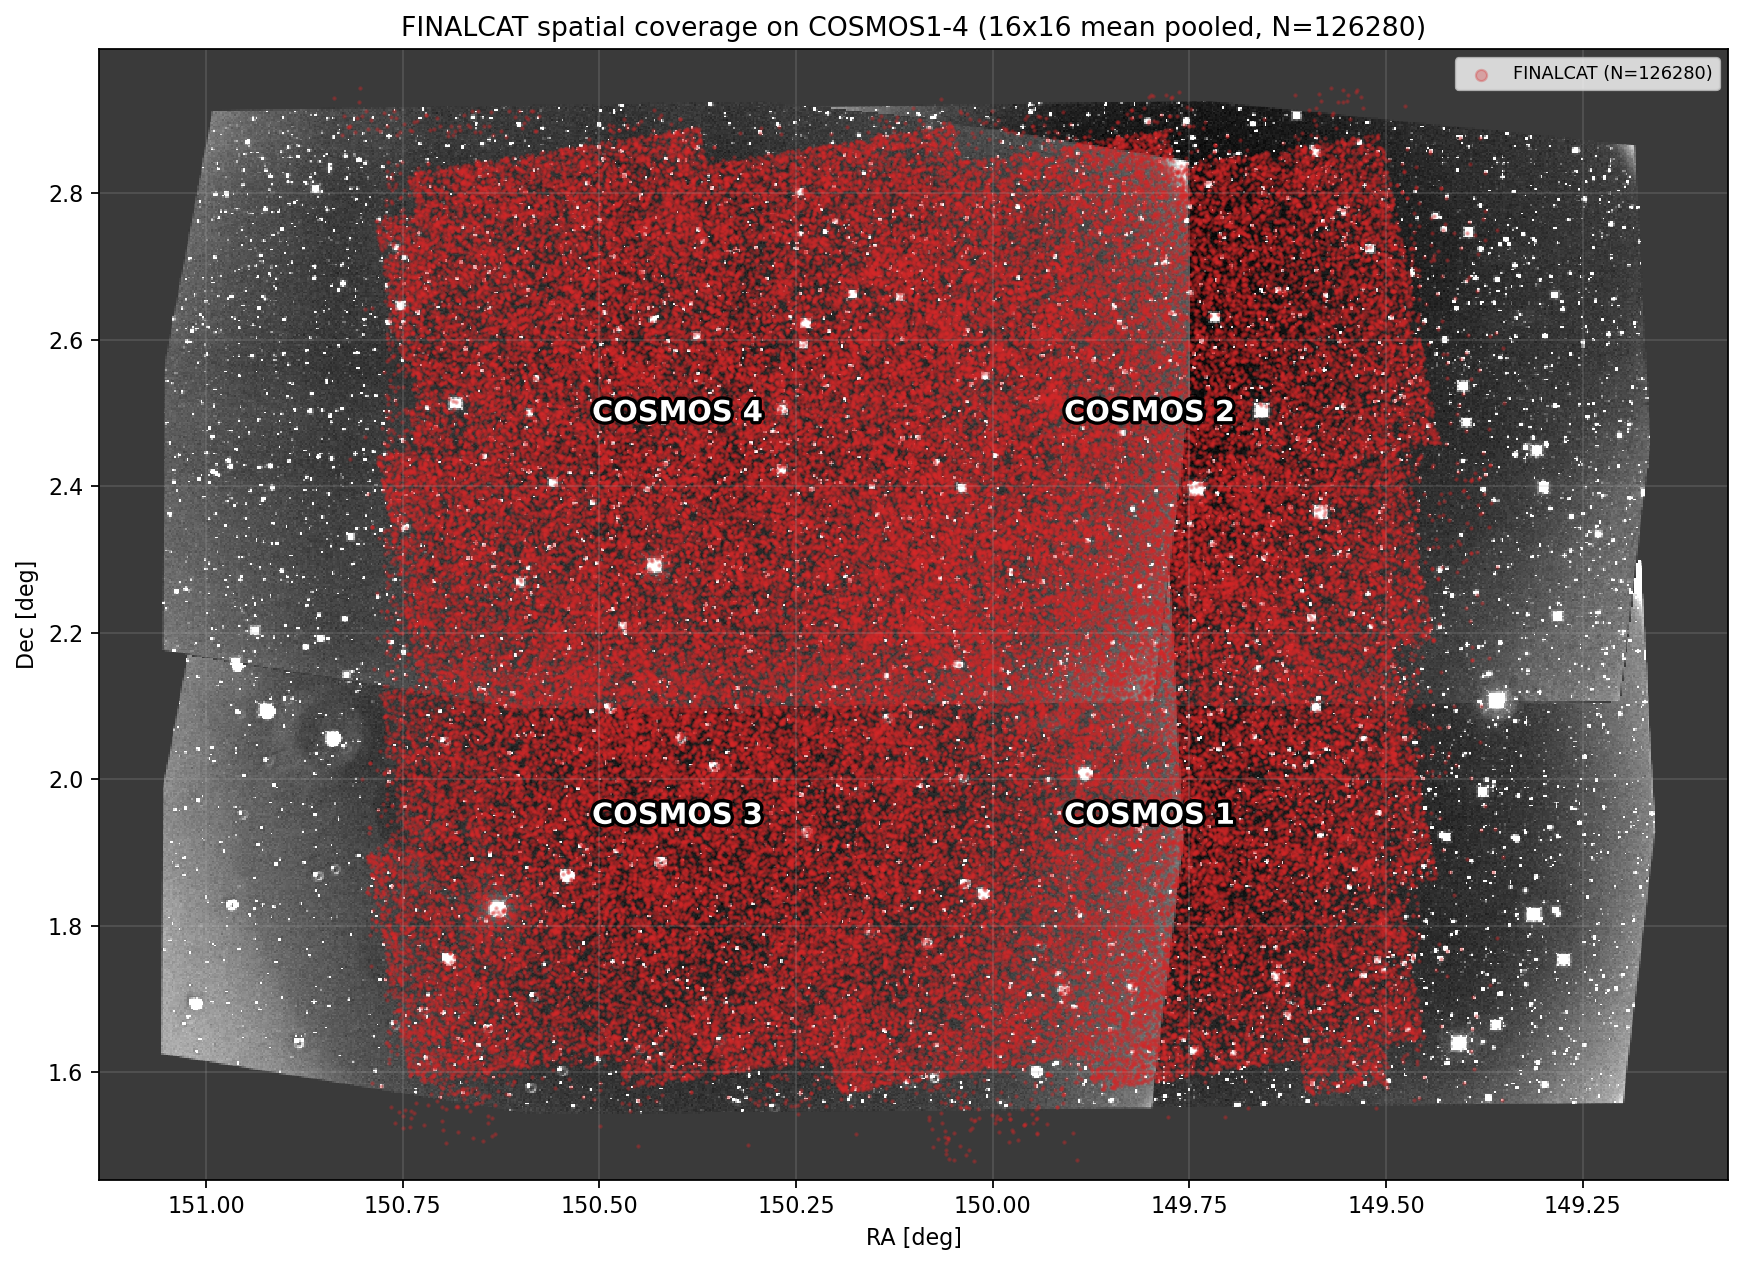

In [147]:
# FINALCAT spatial coverage on the COSMOS1-4 mosaic (RA/Dec).
# Scope: visualization only, no recovery analysis in this step.
# - Background axes are RA/Dec; global limits come from the measured WCS
#   corners of the four detection images (plus a small padding).
# - Each detection image is shown with 16x16 mean pooling (chunk-wise,
#   NaN-aware) to avoid dropping point sources by subsampling.
# - WCS direction is preserved per image (dRA/dx < 0, dDec/dy > 0):
#   imshow extent = [ra_max_used, ra_min_used, dec_min_used, dec_max_used].
# - Trimming: 10200 = 16*637 + 8, so the last 8 columns are excluded and the
#   extent below is computed from the actually used pixels [1:10192]x[1:6800].
# - Detection frames are zero-padded outside the valid coadd area; pooled
#   pixels exactly equal to 0 are masked transparent so a top image's padding
#   never hides another image's valid data.
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
from astropy.io import fits
from astropy.table import Table
from astropy.visualization import ImageNormalize, ZScaleInterval
from astropy.wcs import WCS

POOL = 16
PAD_DEG = 0.02
CHUNK_POOLED_ROWS = 64  # 64*16 = 1024 original rows per chunk

# This cell assumes the setup cell (cell 5) has run: PROJECT_ROOT, DATA_ROOT.
FINALCAT_PATH = DATA_ROOT / 'COSMOS_finalcat.fits'
FIG_DIR = PROJECT_ROOT / 'output' / 'finalcat_coverage'
FIG_DIR.mkdir(parents=True, exist_ok=True)
FIG_PATH = FIG_DIR / 'finalcat_spatial_coverage_radec.png'


def chunk_pooled_mean(image_path, factor=POOL, chunk_pooled_rows=CHUNK_POOLED_ROWS):
    """16x16 mean pooling without a full-frame float64 temp array.

    Reads one row-chunk at a time (memmap, float32 copy of the chunk only)
    and applies NaN-aware mean per block. Full-frame
    ``block_reduce(np.nanmean)`` would materialize a ~69M-pixel float64
    intermediate; chunking keeps peak memory to ~40 MB.
    """
    data = fits.getdata(image_path, memmap=True)
    ny, nx = data.shape
    nx_used = (nx // factor) * factor
    ny_used = (ny // factor) * factor
    nx_p, ny_p = nx_used // factor, ny_used // factor
    pooled = np.empty((ny_p, nx_p), dtype=np.float32)
    chunk_h = chunk_pooled_rows * factor
    for y0 in range(0, ny_used, chunk_h):
        y1 = min(y0 + chunk_h, ny_used)
        npy = (y1 - y0) // factor
        chunk = np.asarray(data[y0:y0 + npy * factor, :nx_used], dtype=np.float32)
        block = chunk.reshape(npy, factor, nx_p, factor)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', category=RuntimeWarning)
            pooled[y0 // factor:y0 // factor + npy, :] = np.nanmean(block, axis=(1, 3))
    del data
    return pooled, nx_used, ny_used


# ---- Footprints from measured WCS corners (used-pixel region) ----
footprints = {}
all_ra, all_dec = [], []
for i in (1, 2, 3, 4):
    det_path = DATA_ROOT / f'COSMOS{i}' / f'COSMOS{i}_detectionimage.fits'
    hdr = fits.getheader(det_path)
    w = WCS(hdr)
    nx, ny = int(hdr['NAXIS1']), int(hdr['NAXIS2'])
    pooled, nx_used, ny_used = chunk_pooled_mean(det_path)
    # Used-pixel corners, FITS 1-based: x in [1, nx_used], y in [1, ny_used].
    xs = np.array([1, nx_used, 1, nx_used], dtype=float)
    ys = np.array([1, 1, ny_used, ny_used], dtype=float)
    ra_c, dec_c = w.all_pix2world(xs, ys, 1)
    # dRA/dx < 0: x=1 edge holds RA max; dDec/dy > 0: y=1 holds Dec min.
    ra_max_used = float(ra_c[xs == 1].max())
    ra_min_used = float(ra_c[xs == nx_used].min())
    dec_min_used = float(dec_c.min())
    dec_max_used = float(dec_c.max())
    assert ra_max_used > ra_min_used and dec_max_used > dec_min_used
    masked = np.ma.masked_equal(pooled, 0.0)  # zero padding -> transparent
    footprints[i] = dict(path=det_path, wcs=w, pooled=masked,
                         nx=nx, ny=ny, nx_used=nx_used, ny_used=ny_used,
                         ra_min=ra_min_used, ra_max=ra_max_used,
                         dec_min=dec_min_used, dec_max=dec_max_used)
    all_ra += [ra_min_used, ra_max_used]
    all_dec += [dec_min_used, dec_max_used]
    print(f'COSMOS{i}: NAXIS={nx}x{ny}, used={nx_used}x{ny_used} '
          f'(trimmed {nx - nx_used} cols), pooled={pooled.shape}, '
          f'masked-zero frac={float(masked.mask.mean()):.3f}, '
          f'RA=[{ra_min_used:.5f},{ra_max_used:.5f}], Dec=[{dec_min_used:.5f},{dec_max_used:.5f}]')

RA_MIN, RA_MAX = float(min(all_ra)), float(max(all_ra))
DEC_MIN, DEC_MAX = float(min(all_dec)), float(max(all_dec))
print(f'Global used footprint: RA=[{RA_MIN:.5f},{RA_MAX:.5f}] (span {RA_MAX - RA_MIN:.5f} deg), '
      f'Dec=[{DEC_MIN:.5f},{DEC_MAX:.5f}] (span {DEC_MAX - DEC_MIN:.5f} deg), pad={PAD_DEG} deg')

# ---- Common stretch from pooled valid pixels ----
pooled_sample = np.concatenate(
    [np.asarray(fp['pooled'].compressed(), dtype=float) for fp in footprints.values()])
vmin, vmax = ZScaleInterval().get_limits(pooled_sample)
norm = ImageNormalize(vmin=vmin, vmax=vmax)
print(f'ZScale on pooled valid pixels: vmin={vmin:.4g}, vmax={vmax:.4g}, N={pooled_sample.size}')
del pooled_sample

# ---- FINALCAT ----
finalcat = Table.read(FINALCAT_PATH)
fra = np.asarray(finalcat['RA'], dtype=float)
fdec = np.asarray(finalcat['DEC'], dtype=float)
ffinite = np.isfinite(fra) & np.isfinite(fdec)
print(f'FINALCAT: {len(finalcat)} rows, finite RA/Dec={int(ffinite.sum())}, '
      f'RA=[{np.nanmin(fra):.5f},{np.nanmax(fra):.5f}], Dec=[{np.nanmin(fdec):.5f},{np.nanmax(fdec):.5f}]')

# ---- (A) Astrometric consistency: WCS(master_x/y) vs FINALCAT RA/Dec ----
# NOTE: this checks catalog astrometry only; it does NOT prove the imshow
# extent below is correct. Extent is checked independently in (B).
master1 = Table.read(PROJECT_ROOT / 'output' / 'COSMOS1' / 'singlebandphot' / 'matching' / 'master_catalog.fits')
mcls = np.asarray(master1['master_class']).astype(str)
msel = mcls == 'matched'
mx = np.ma.filled(master1['master_x'], np.nan).astype(float)[msel]
my = np.ma.filled(master1['master_y'], np.nan).astype(float)[msel]
mfra = np.ma.filled(master1['finalcat_RA'], np.nan).astype(float)[msel]
mfdec = np.ma.filled(master1['finalcat_DEC'], np.nan).astype(float)[msel]
ok = np.isfinite(mx) & np.isfinite(my) & np.isfinite(mfra) & np.isfinite(mfdec)
w1 = footprints[1]['wcs']
pred_ra, pred_dec = w1.all_pix2world(np.asarray(mx[ok]), np.asarray(my[ok]), 1)
sep = np.hypot((pred_ra - mfra[ok]) * np.cos(np.deg2rad(mfra[ok])), pred_dec - mfdec[ok]) * 3600.0
print(f'(A) astrometric consistency (COSMOS1 matched, N={int(ok.sum())}): '
      f'median={np.nanmedian(sep):.3f} arcsec, p90={np.nanpercentile(sep, 90):.3f} arcsec, '
      f'>2arcsec frac={np.nanmean(sep > 2.0):.4f}')

# ---- (B) Visualization alignment: extent mapping vs WCS, per image ----
# Pooled pixel (j,i) center maps through the imshow extent; compare against
# WCS at the parent original pixel. Independent of any catalog.
POOLED_PIX_DEG = 16 * 0.0001402777777778
for i in (1, 2, 3, 4):
    fp = footprints[i]
    nx_p = fp['nx_used'] // POOL
    ny_p = fp['ny_used'] // POOL
    # Test original pixels: center + 4 quadrants, inside the used region.
    tx = np.array([fp['nx_used'] // 2, fp['nx_used'] // 4, 3 * fp['nx_used'] // 4,
                   fp['nx_used'] // 4, 3 * fp['nx_used'] // 4], dtype=float)
    ty = np.array([fp['ny_used'] // 2, fp['ny_used'] // 4, fp['ny_used'] // 4,
                   3 * fp['ny_used'] // 4, 3 * fp['ny_used'] // 4], dtype=float)
    ra_w, dec_w = fp['wcs'].all_pix2world(tx, ty, 1)
    # Extent mapping: col ix=(x-1)//POOL, row iy=(y-1)//POOL; pixel-center convention.
    ix = np.clip(((tx - 1) // POOL).astype(int), 0, nx_p - 1)
    iy = np.clip(((ty - 1) // POOL).astype(int), 0, ny_p - 1)
    ra_e = fp['ra_max'] + (ix + 0.5) / nx_p * (fp['ra_min'] - fp['ra_max'])
    dec_e = fp['dec_min'] + (iy + 0.5) / ny_p * (fp['dec_max'] - fp['dec_min'])
    err = np.hypot((ra_e - ra_w) * np.cos(np.deg2rad(dec_w)), dec_e - dec_w)
    print(f'(B) COSMOS{i} extent-vs-WCS max err={err.max() * 3600:.2f} arcsec '
          f'(tolerance {(POOLED_PIX_DEG * 3600):.1f} arcsec = 1 pooled pixel)')
    assert err.max() < POOLED_PIX_DEG * 1.5, f'COSMOS{i} extent mapping failed'

# ---- Figure: RA/Dec background + pooled images + FINALCAT ----
fig, ax = plt.subplots(figsize=(11, 8))
ax.set_facecolor('#3a3a3a')
for i in (1, 2, 3, 4):
    fp = footprints[i]
    ax.imshow(fp['pooled'], origin='lower', cmap='gray', norm=norm,
              extent=[fp['ra_max'], fp['ra_min'], fp['dec_min'], fp['dec_max']],
              interpolation='nearest', alpha=1.0, aspect='auto')
ax.scatter(fra[ffinite], fdec[ffinite], s=1, c='tab:red', alpha=0.3,
           rasterized=True, label=f'FINALCAT (N={int(ffinite.sum())})')
for i in (1, 2, 3, 4):
    fp = footprints[i]
    ax.text((fp['ra_max'] + fp['ra_min']) / 2, (fp['dec_max'] + fp['dec_min']) / 2,
            f'COSMOS {i}', color='white', fontsize=13, fontweight='bold',
            ha='center', va='center',
            path_effects=[patheffects.withStroke(linewidth=3, foreground='black')])
ax.set_xlim(RA_MAX + PAD_DEG, RA_MIN - PAD_DEG)  # RA increases to the left
ax.set_ylim(DEC_MIN - PAD_DEG, DEC_MAX + PAD_DEG)
ax.set_xlabel('RA [deg]')
ax.set_ylabel('Dec [deg]')
ax.set_title(f'FINALCAT spatial coverage on COSMOS1-4 (16x16 mean pooled, N={int(ffinite.sum())})')
ax.grid(alpha=0.2)
ax.legend(loc='upper right', fontsize=8, markerscale=5)
fig.tight_layout()
fig.savefig(FIG_PATH, dpi=160, bbox_inches='tight')
plt.show()


# ---- (C) On-figure source/scatter check in the same RA/Dec coordinates ----
# Central-overlap test region (no zoom panel); sample the displayed pooled
# mosaic at source positions via the same extent inverse mapping used for
# imshow. Faint FINALCAT galaxies are mostly invisible at 8 arcsec pooling,
# so the quantitative test uses 7DT-matched sources and bright (RM<20)
# FINALCAT sources, which must sit on elevated pooled pixels if aligned.
ZC, ZSIDE = (150.00, 2.20), 0.06


def sample_pooled(ra_q, dec_q):
    """Sample the displayed mosaic at sky positions via extent inverse mapping."""
    vals = []
    for r_, d_ in zip(np.atleast_1d(ra_q), np.atleast_1d(dec_q)):
        best = np.nan
        for fp in footprints.values():
            if not (fp['ra_min'] <= r_ <= fp['ra_max'] and fp['dec_min'] <= d_ <= fp['dec_max']):
                continue
            nx_p = fp['nx_used'] // POOL
            ny_p = fp['ny_used'] // POOL
            ix = int(np.clip((fp['ra_max'] - r_) / (fp['ra_max'] - fp['ra_min']) * nx_p, 0, nx_p - 1))
            iy = int(np.clip((d_ - fp['dec_min']) / (fp['dec_max'] - fp['dec_min']) * ny_p, 0, ny_p - 1))
            v = fp['pooled'][iy, ix]
            if np.ma.is_masked(v):
                continue
            if not np.isfinite(best) or v > best:
                best = v
        vals.append(best)
    return np.asarray(vals, dtype=float)


rng = np.random.default_rng(0)
bg_ra = rng.uniform(ZC[0] - ZSIDE / 2, ZC[0] + ZSIDE / 2, size=2000)
bg_dec = rng.uniform(ZC[1] - ZSIDE / 2, ZC[1] + ZSIDE / 2, size=2000)
bg_vals = sample_pooled(bg_ra, bg_dec)
mrad = mfra[ok & (np.abs(mfra - ZC[0]) < ZSIDE / 2) & (np.abs(mfdec - ZC[1]) < ZSIDE / 2)]
mdecd = mfdec[ok & (np.abs(mfra - ZC[0]) < ZSIDE / 2) & (np.abs(mfdec - ZC[1]) < ZSIDE / 2)]
match_vals = sample_pooled(mrad, mdecd)
rm = np.asarray(finalcat['RM'], dtype=float)
bsel = (ffinite & np.isfinite(rm) & (rm < 20)
        & (np.abs(fra - ZC[0]) < ZSIDE / 2) & (np.abs(fdec - ZC[1]) < ZSIDE / 2))
bright_vals = sample_pooled(fra[bsel], fdec[bsel])
print(f'(C) on-figure test-region check (pooled flux > 1.0 frac / median): '
      f'7DT-matched N={len(match_vals)} frac={np.nanmean(match_vals > 1.0):.3f} med={np.nanmedian(match_vals):.3g}; '
      f'bright RM<20 N={len(bright_vals)} frac={np.nanmean(bright_vals > 1.0):.3f} med={np.nanmedian(bright_vals):.3g}; '
      f'random N={len(bg_vals)} frac={np.nanmean(bg_vals > 1.0):.3f} med={np.nanmedian(bg_vals):.3g}')
assert np.nanmean(match_vals > 1.0) > np.nanmean(bg_vals > 1.0), 'matched sources not brighter than random: alignment suspect'
print(f'Saved {FIG_PATH}')


## Statistical Informations of FINALCAT

### Informations about Whole Finalcat

In [148]:
# FINALCAT basic statistics: total count, column inventory, one full example row.
# This cell assumes the setup cell has run (PROJECT_ROOT, DATA_ROOT).
import numpy as np
from astropy.table import Table

FINALCAT_PATH = DATA_ROOT / 'COSMOS_finalcat.fits'
finalcat_stats = Table.read(FINALCAT_PATH)
print(f'FINALCAT total sources: {len(finalcat_stats)}')
print(f'FINALCAT columns: {len(finalcat_stats.colnames)}')
print('Column inventory (index: name):')
for i, name in enumerate(finalcat_stats.colnames):
    print(f'  {i:3d}: {name}')

MAG_BANDS = ['UM', 'BM', 'GM', 'VM', 'RM', 'IM', 'ZM']


def valid_mag(v):
    v = np.ma.filled(v, np.nan).astype(float)
    return v[np.isfinite(v) & (v > 0) & (v < 50)]


print('\nKey-column valid fractions (mag: finite and 0 < mag < 50; z: finite and 0 <= z < 10):')
for band in MAG_BANDS:
    vv = valid_mag(finalcat_stats[band])
    print(f'  {band}: N_valid={len(vv)} ({len(vv) / len(finalcat_stats) * 100:.2f}%), median={np.median(vv):.3f}')
for zcol in ['Z_TOT_Z', 'G11_ZPHOT', 'M13_ZPHOT', 'M13_ZSPEC']:
    raw = np.ma.filled(finalcat_stats[zcol], np.nan).astype(float)
    vv = raw[np.isfinite(raw) & (raw >= 0) & (raw < 10)]
    print(f'  {zcol}: N_valid={len(vv)} ({len(vv) / len(finalcat_stats) * 100:.2f}%)'
          + (f', median={np.median(vv):.3f}' if len(vv) else ''))

# Example source: first row with a valid total redshift and valid RM, so that
# the pprint below shows populated mag and z fields. Missing-value sentinels
# in this catalog are -99 and 0.0 (magnitude columns) and -99 (redshift columns).
ztot = np.ma.filled(finalcat_stats['Z_TOT_Z'], np.nan).astype(float)
rm = np.ma.filled(finalcat_stats['RM'], np.nan).astype(float)
ex_mask = np.isfinite(ztot) & (ztot >= 0) & (ztot < 10) & np.isfinite(rm) & (rm > 0) & (rm < 50)
ex_idx = int(np.flatnonzero(ex_mask)[0])
ex_row = finalcat_stats[ex_idx:ex_idx + 1]
print(f'\nExample source: table row {ex_idx}, ID={ex_row["ID"][0]}, '
      f'RA={float(ex_row["RA"][0]):.6f}, Dec={float(ex_row["DEC"][0]):.6f}, '
      f'RM={float(ex_row["RM"][0]):.3f}, Z_TOT_Z={float(ex_row["Z_TOT_Z"][0]):.4f}')
print('Full row content (no truncation, all columns):')
ex_row.pprint(max_lines=-1, max_width=-1)


FINALCAT total sources: 126280
FINALCAT columns: 158
Column inventory (index: name):
    0: ID
    1: RA
    2: DEC
    3: G11_ID
    4: G11_RA
    5: G11_DEC
    6: G11_ZPHOT
    7: G11_ZPHOT_LERR
    8: G11_ZPHOT_HERR
    9: G11_MASS
   10: G11_MASS_LERR
   11: G11_MASS_HERR
   12: PMEM
   13: PMEM_ZBEST
   14: GRID
   15: GRFLAG
   16: MMGGS
   17: M13_ID
   18: M13_RA
   19: M13_DEC
   20: M13_STAR
   21: M13_SG
   22: UM
   23: UMERR
   24: BM
   25: BMERR
   26: GM
   27: GMERR
   28: VM
   29: VMERR
   30: RM
   31: RMERR
   32: IM
   33: IMERR
   34: ZM
   35: ZMERR
   36: M13_ZSPEC
   37: M13_ZCC
   38: M13_ZCOSMOS_ID
   39: M13_ZPHOT
   40: C07_ID
   41: C07_RA
   42: C07_DEC
   43: C07FLAG
   44: C07_UM
   45: C07_UMERR
   46: C07_BM
   47: C07_BMERR
   48: C07_GM
   49: C07_GMERR
   50: C07_VM
   51: C07_VMERR
   52: C07_RM
   53: C07_RMERR
   54: C07_IM
   55: C07_IMERR
   56: C07_ZM
   57: C07_ZMERR
   58: SDSS_OBJID
   59: SDSS_RA
   60: SDSS_DEC
   61: PETUM
   62: PETU

UM: N_valid=121383, median=24.667, p5=22.552, p95=26.843
BM: N_valid=121709, median=24.452, p5=22.124, p95=26.259
GM: N_valid=121358, median=24.325, p5=21.889, p95=26.037
VM: N_valid=121730, median=24.039, p5=21.331, p95=25.469
RM: N_valid=123681, median=23.700, p5=20.854, p95=24.964
IM: N_valid=114799, median=23.172, p5=20.561, p95=24.292
ZM: N_valid=121495, median=22.776, p5=20.063, p95=24.052
Saved /Users/mac_seo/Research_local/7DTonCOSMOS/output/finalcat_coverage/finalcat_mag_histogram.png


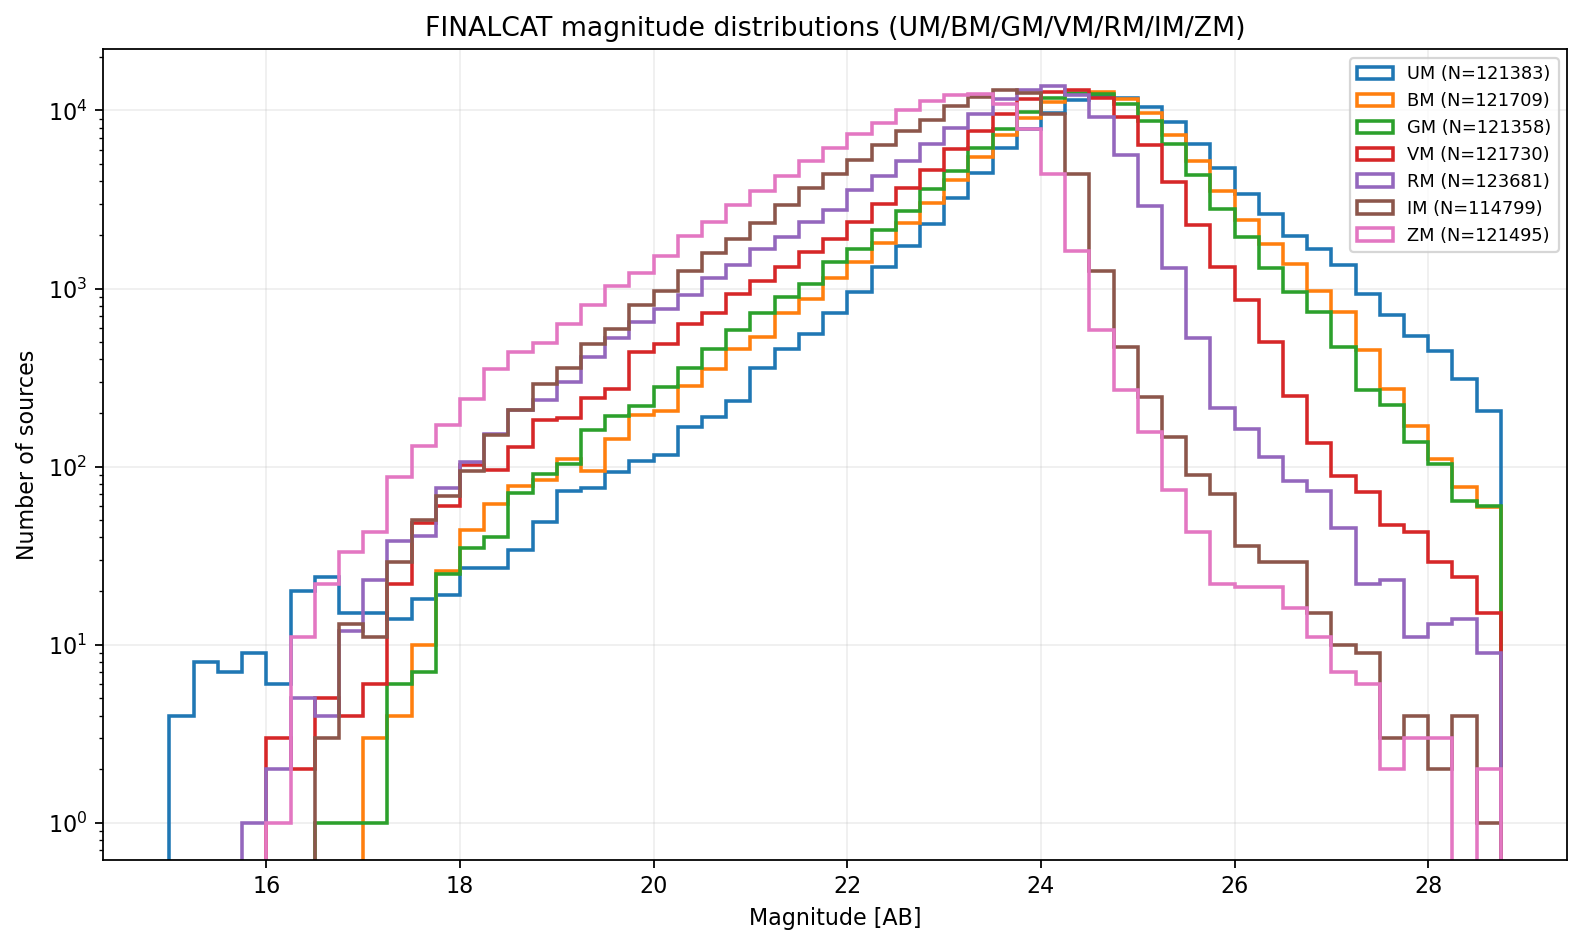

In [149]:
# FINALCAT magnitude histograms (UM/BM/GM/VM/RM/IM/ZM).
# Valid mask per band: finite and 0 < mag < 50 (missing sentinels are -99 and 0.0).
# This cell assumes the setup cell has run (PROJECT_ROOT, DATA_ROOT).
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

FINALCAT_PATH = DATA_ROOT / 'COSMOS_finalcat.fits'
FIG_DIR = PROJECT_ROOT / 'output' / 'finalcat_coverage'
FIG_DIR.mkdir(parents=True, exist_ok=True)
MAG_HIST_PATH = FIG_DIR / 'finalcat_mag_histogram.png'
MAG_BANDS = ['UM', 'BM', 'GM', 'VM', 'RM', 'IM', 'ZM']

finalcat_mag = Table.read(FINALCAT_PATH)
mag_data = {}
for band in MAG_BANDS:
    v = np.ma.filled(finalcat_mag[band], np.nan).astype(float)
    v = v[np.isfinite(v) & (v > 0) & (v < 50)]
    mag_data[band] = v
    print(f'{band}: N_valid={len(v)}, median={np.median(v):.3f}, '
          f'p5={np.percentile(v, 5):.3f}, p95={np.percentile(v, 95):.3f}')

mag_bins = np.arange(15.0, 29.0, 0.25)
fig, ax = plt.subplots(figsize=(10, 6))
for band in MAG_BANDS:
    ax.hist(mag_data[band], bins=mag_bins, histtype='step', linewidth=1.6, label=f'{band} (N={len(mag_data[band])})')
ax.set_yscale('log')
ax.set_xlabel('Magnitude [AB]')
ax.set_ylabel('Number of sources')
ax.set_title('FINALCAT magnitude distributions (UM/BM/GM/VM/RM/IM/ZM)')
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(MAG_HIST_PATH, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved {MAG_HIST_PATH}')


Z_TOT_Z valid (0 <= z < 10): 27213/126280 (21.55%), median=0.6562, p95=1.7779, max=6.5931
z-mag scatter sample (valid Z_TOT_Z and RM): 25820
Saved /Users/mac_seo/Research_local/7DTonCOSMOS/output/finalcat_coverage/finalcat_z_histogram_and_zmag.png


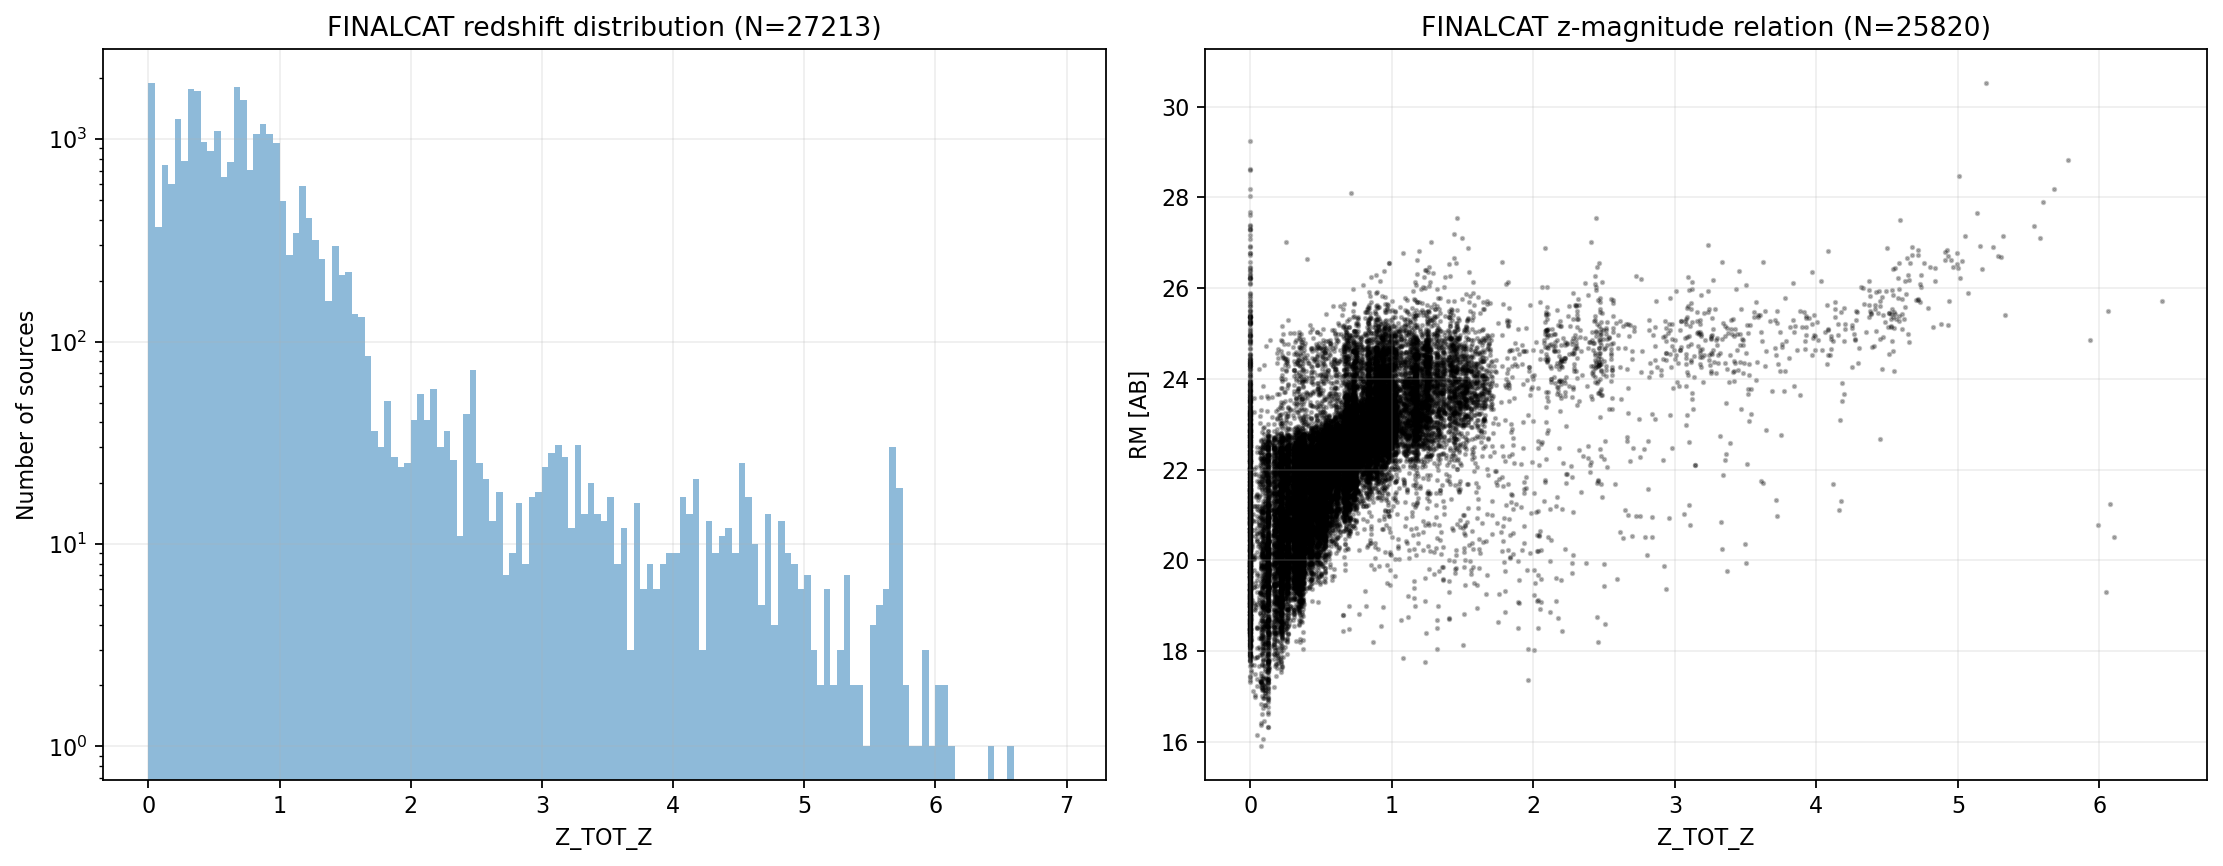

In [150]:
# FINALCAT redshift histogram and z-magnitude scatter.
# Redshift: Z_TOT_Z (best-compilation total redshift), valid mask 0 <= z < 10
# (missing sentinel is -99). Magnitude axis: RM with 0 < mag < 50
# (magnitude sentinels are -99 and 0.0).
# This cell assumes the setup cell has run (PROJECT_ROOT, DATA_ROOT).
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

FINALCAT_PATH = DATA_ROOT / 'COSMOS_finalcat.fits'
FIG_DIR = PROJECT_ROOT / 'output' / 'finalcat_coverage'
FIG_DIR.mkdir(parents=True, exist_ok=True)
ZFIG_PATH = FIG_DIR / 'finalcat_z_histogram_and_zmag.png'

finalcat_z = Table.read(FINALCAT_PATH)
z_all = np.ma.filled(finalcat_z['Z_TOT_Z'], np.nan).astype(float)
rm_all = np.ma.filled(finalcat_z['RM'], np.nan).astype(float)
z_valid = z_all[np.isfinite(z_all) & (z_all >= 0) & (z_all < 10)]
print(f'Z_TOT_Z valid (0 <= z < 10): {len(z_valid)}/{len(finalcat_z)} '
      f'({len(z_valid) / len(finalcat_z) * 100:.2f}%), '
      f'median={np.median(z_valid):.4f}, p95={np.percentile(z_valid, 95):.4f}, '
      f'max={np.max(z_valid):.4f}')
both = np.isfinite(z_all) & (z_all >= 0) & (z_all < 10) & np.isfinite(rm_all) & (rm_all > 0) & (rm_all < 50)
print(f'z-mag scatter sample (valid Z_TOT_Z and RM): {int(both.sum())}')

z_bins = np.arange(0.0, 7.0, 0.05)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].hist(z_valid, bins=z_bins, histtype='stepfilled', color='tab:blue', alpha=0.5, linewidth=1.2)
axes[0].set_yscale('log')
axes[0].set_xlabel('Z_TOT_Z')
axes[0].set_ylabel('Number of sources')
axes[0].set_title(f'FINALCAT redshift distribution (N={len(z_valid)})')
axes[0].grid(alpha=0.2)
axes[1].scatter(z_all[both], rm_all[both], s=2, c='black', alpha=0.25, rasterized=True)
axes[1].set_xlabel('Z_TOT_Z')
axes[1].set_ylabel('RM [AB]')
axes[1].set_title(f'FINALCAT z-magnitude relation (N={int(both.sum())})')
axes[1].grid(alpha=0.2)
fig.tight_layout()
fig.savefig(ZFIG_PATH, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved {ZFIG_PATH}')


### Informations about RoI(Region of Interest)
- Objectives  $z \le 0.4 $

FINALCAT whole sample: 126280
RoI definition: 0.0 <= Z_TOT_Z <= 0.4
RoI sources: 9183 (7.27%)
RoI sources with finite RA/Dec: 9183
Saved /Users/mac_seo/Research_local/7DTonCOSMOS/output/finalcat_coverage/finalcat_roi_z_le_0p4_spatial_coverage.png


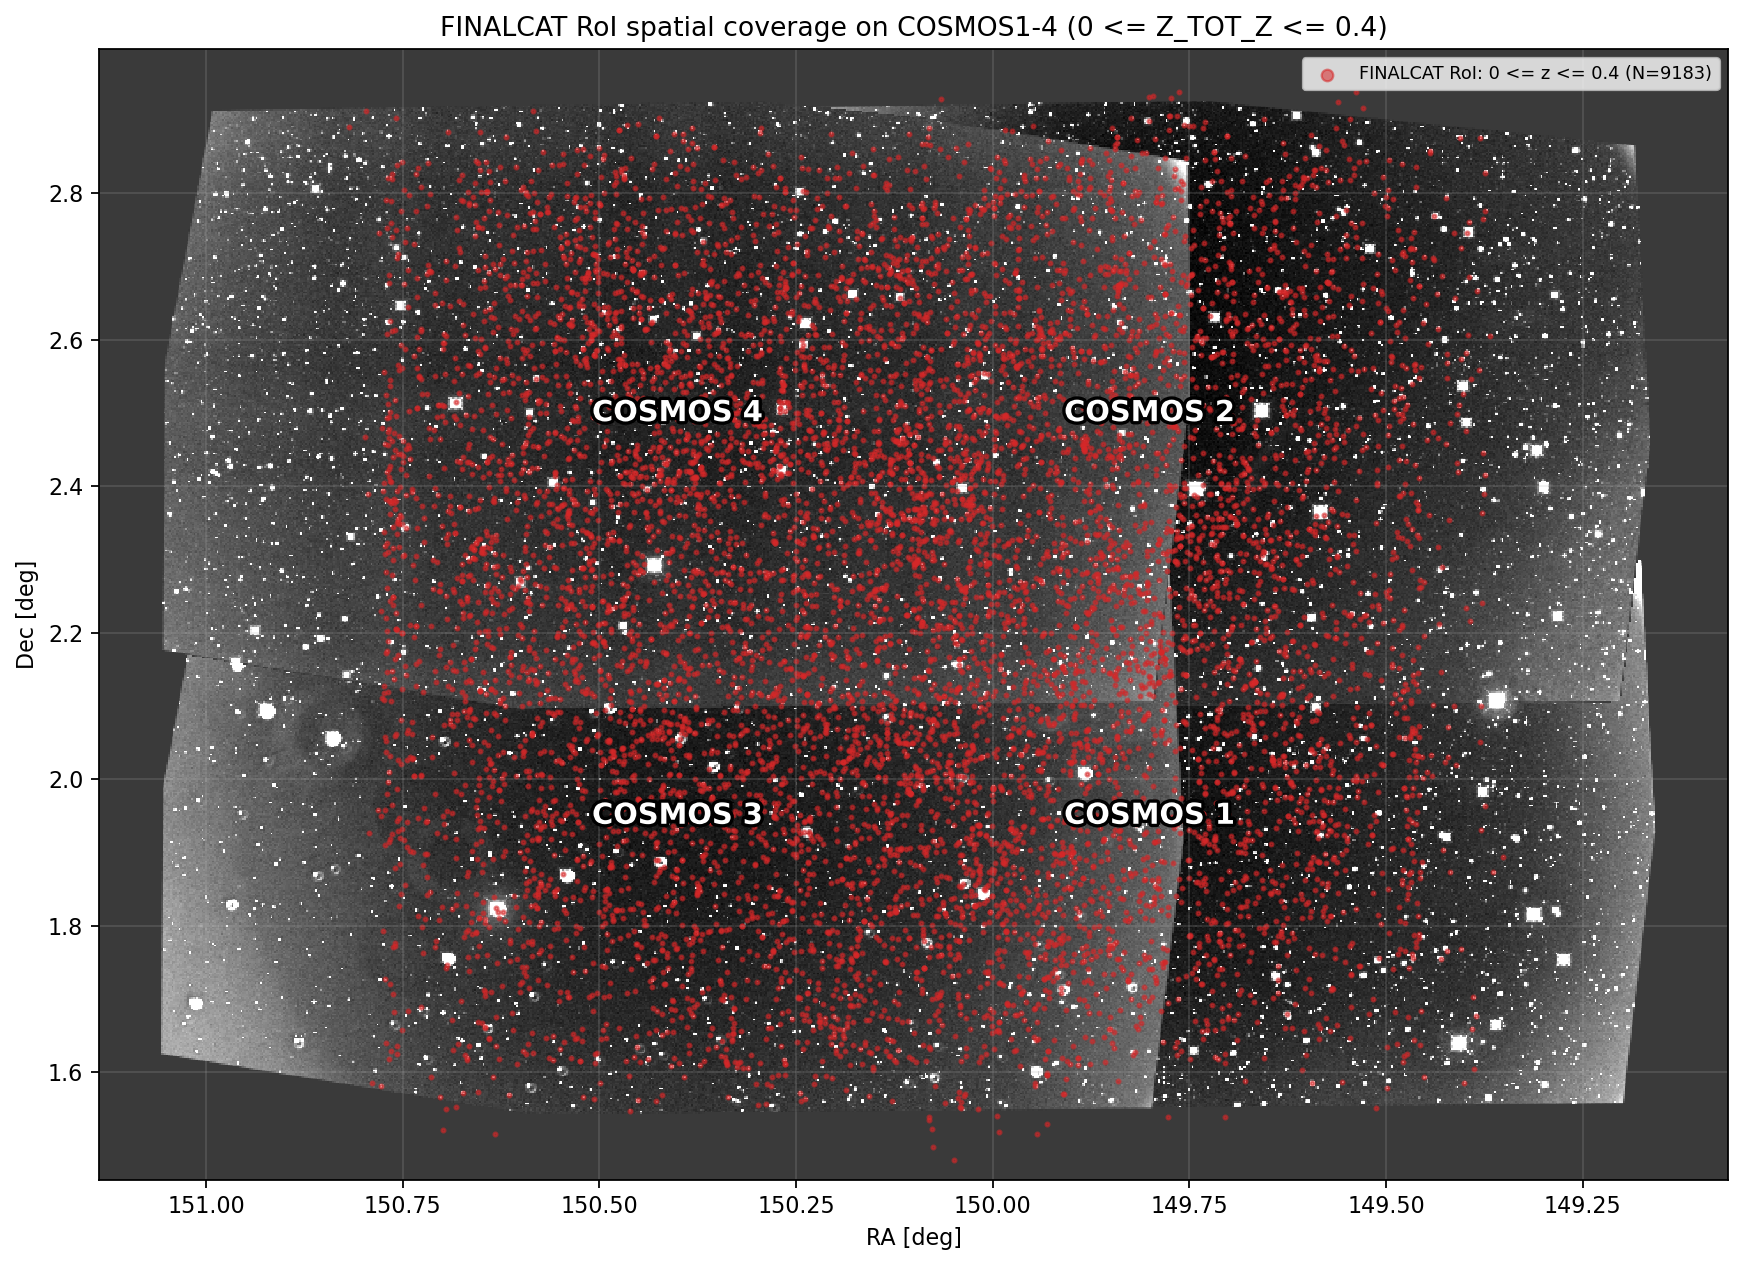

In [151]:
# FINALCAT region of interest: sources with a valid total redshift 0 <= z <= 0.4.
# Reuse the 16x16 pooled COSMOS1-4 backgrounds, WCS-derived footprints, and
# image normalization produced by the FINALCAT spatial-distribution cell.
required_backgrounds = {'footprints', 'norm', 'RA_MIN', 'RA_MAX', 'DEC_MIN', 'DEC_MAX', 'PAD_DEG'}
missing_backgrounds = required_backgrounds.difference(globals())
if missing_backgrounds:
    raise RuntimeError(
        'Run the FINALCAT Spatial Distribution cell first; missing variables: '
        f'{sorted(missing_backgrounds)}'
    )

ROI_Z_MIN = 0.0
ROI_Z_MAX = 0.4
ROI_FIG_DIR = PROJECT_ROOT / 'output' / 'finalcat_coverage'
ROI_FIG_DIR.mkdir(parents=True, exist_ok=True)
ROI_SPATIAL_PATH = ROI_FIG_DIR / 'finalcat_roi_z_le_0p4_spatial_coverage.png'

finalcat_roi_all = Table.read(DATA_ROOT / 'COSMOS_finalcat.fits')
roi_z_all = np.ma.filled(finalcat_roi_all['Z_TOT_Z'], np.nan).astype(float)
roi_mask = np.isfinite(roi_z_all) & (roi_z_all >= ROI_Z_MIN) & (roi_z_all <= ROI_Z_MAX)
finalcat_roi = finalcat_roi_all[roi_mask]
roi_ra = np.asarray(finalcat_roi['RA'], dtype=float)
roi_dec = np.asarray(finalcat_roi['DEC'], dtype=float)
roi_finite_position = np.isfinite(roi_ra) & np.isfinite(roi_dec)

print(f'FINALCAT whole sample: {len(finalcat_roi_all)}')
print(f'RoI definition: {ROI_Z_MIN:.1f} <= Z_TOT_Z <= {ROI_Z_MAX:.1f}')
print(f'RoI sources: {len(finalcat_roi)} ({len(finalcat_roi) / len(finalcat_roi_all) * 100:.2f}%)')
print(f'RoI sources with finite RA/Dec: {int(roi_finite_position.sum())}')

fig, ax = plt.subplots(figsize=(11, 8))
ax.set_facecolor('#3a3a3a')
for i in (1, 2, 3, 4):
    fp = footprints[i]
    ax.imshow(
        fp['pooled'], origin='lower', cmap='gray', norm=norm,
        extent=[fp['ra_max'], fp['ra_min'], fp['dec_min'], fp['dec_max']],
        interpolation='nearest', alpha=1.0, aspect='auto',
    )
ax.scatter(
    roi_ra[roi_finite_position], roi_dec[roi_finite_position],
    s=3, c='tab:red', alpha=0.55, rasterized=True,
    label=f'FINALCAT RoI: 0 <= z <= 0.4 (N={int(roi_finite_position.sum())})',
)
for i in (1, 2, 3, 4):
    fp = footprints[i]
    ax.text(
        (fp['ra_max'] + fp['ra_min']) / 2,
        (fp['dec_max'] + fp['dec_min']) / 2,
        f'COSMOS {i}', color='white', fontsize=13, fontweight='bold',
        ha='center', va='center',
        path_effects=[patheffects.withStroke(linewidth=3, foreground='black')],
    )
ax.set_xlim(RA_MAX + PAD_DEG, RA_MIN - PAD_DEG)
ax.set_ylim(DEC_MIN - PAD_DEG, DEC_MAX + PAD_DEG)
ax.set_xlabel('RA [deg]')
ax.set_ylabel('Dec [deg]')
ax.set_title('FINALCAT RoI spatial coverage on COSMOS1-4 (0 <= Z_TOT_Z <= 0.4)')
ax.grid(alpha=0.2)
ax.legend(loc='upper right', fontsize=8, markerscale=3)
fig.tight_layout()
fig.savefig(ROI_SPATIAL_PATH, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved {ROI_SPATIAL_PATH}')


UM: N_valid=8565, median=22.655, p5=19.625, p95=25.059
BM: N_valid=8378, median=22.089, p5=19.434, p95=24.261
GM: N_valid=8208, median=21.813, p5=19.394, p95=23.961
VM: N_valid=8341, median=21.198, p5=18.736, p95=23.372
RM: N_valid=8574, median=20.834, p5=18.516, p95=23.044
IM: N_valid=6717, median=20.543, p5=18.393, p95=22.460
ZM: N_valid=8093, median=20.142, p5=17.911, p95=22.193
Saved /Users/mac_seo/Research_local/7DTonCOSMOS/output/finalcat_coverage/finalcat_roi_z_le_0p4_mag_histogram.png


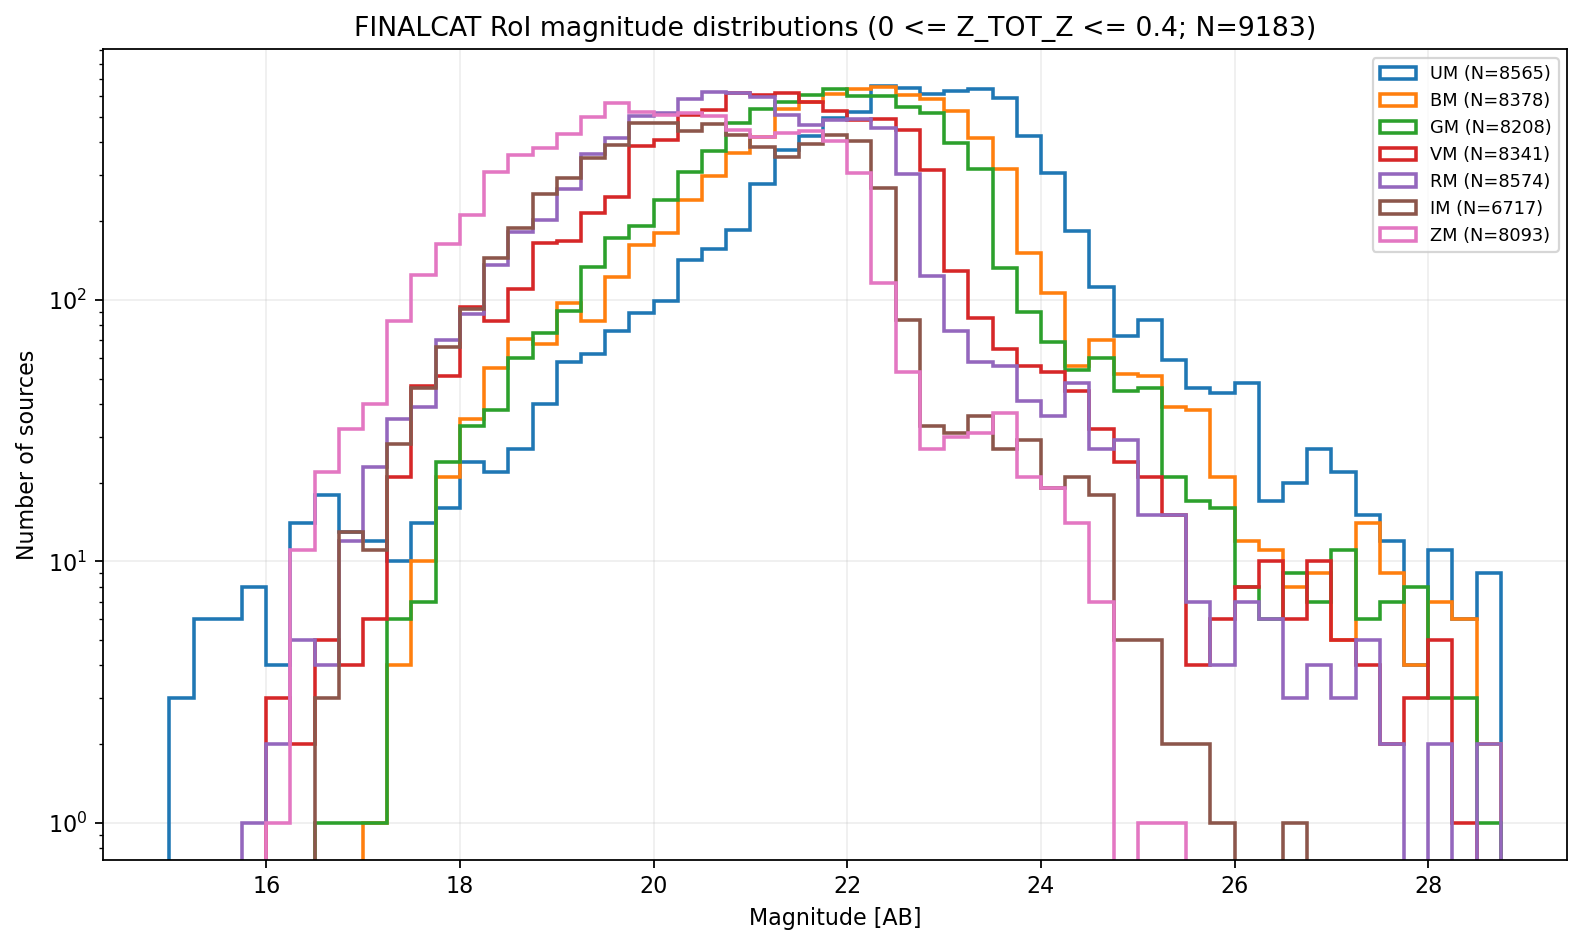

In [152]:
# FINALCAT RoI magnitude histograms, using the same bands, masks, and bins as
# the whole-FINALCAT magnitude-distribution cell.
if 'finalcat_roi' not in globals():
    raise RuntimeError('Run the preceding FINALCAT RoI spatial cell first.')

ROI_MAG_PATH = ROI_FIG_DIR / 'finalcat_roi_z_le_0p4_mag_histogram.png'
ROI_MAG_BANDS = ['UM', 'BM', 'GM', 'VM', 'RM', 'IM', 'ZM']

roi_mag_data = {}
for band in ROI_MAG_BANDS:
    values = np.ma.filled(finalcat_roi[band], np.nan).astype(float)
    values = values[np.isfinite(values) & (values > 0) & (values < 50)]
    roi_mag_data[band] = values
    print(
        f'{band}: N_valid={len(values)}, median={np.median(values):.3f}, '
        f'p5={np.percentile(values, 5):.3f}, p95={np.percentile(values, 95):.3f}'
    )

roi_mag_bins = np.arange(15.0, 29.0, 0.25)
fig, ax = plt.subplots(figsize=(10, 6))
for band in ROI_MAG_BANDS:
    ax.hist(
        roi_mag_data[band], bins=roi_mag_bins, histtype='step', linewidth=1.6,
        label=f'{band} (N={len(roi_mag_data[band])})',
    )
ax.set_yscale('log')
ax.set_xlabel('Magnitude [AB]')
ax.set_ylabel('Number of sources')
ax.set_title(f'FINALCAT RoI magnitude distributions (0 <= Z_TOT_Z <= 0.4; N={len(finalcat_roi)})')
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(ROI_MAG_PATH, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved {ROI_MAG_PATH}')
